In [ ]:
!pip install -q kagglehub
!pip install -q torch torchvision
!pip install -q google-generativeai
!pip install -q plotly

print('✅ All libraries installed')

✅ All libraries installed


In [ ]:
import os           # interact with the file system (make folders, check paths)
import glob         # find files using wildcard patterns like "*.csv"
import kagglehub    # download Kaggle datasets easily

import pandas as pd         # THE data tool — loads CSVs into a "DataFrame" (like Excel in Python)
import numpy as np          # math on big arrays fast — pandas uses it internally

# For quick visual checks later
import matplotlib.pyplot as plt   # basic plotting librar

In [ ]:
#  WHY SMART DOWNLOAD?
#  Colab sessions reset when you close the tab, BUT if you're
#  actively working, re-running the notebook shouldn't waste
#  2 minutes re-downloading 50MB each time.
#  We check if the files already exist before downloading.
#
#  HOW kagglehub.dataset_download WORKS:
#  It returns a local folder path where the dataset was saved.
#  Inside that folder there will be one or more .csv files.
#  The exact filename can vary, so we use glob() to find any
#  .csv inside that folder — that's the robust way.

# --- Paths where we'll store CSVs for this session ---
RETAIL_CSV = '/content/retail.csv'    # we'll copy the downloaded file here
CITIES_CSV  = '/content/cities.csv'   # same for cities

# --- Download Retail dataset ---
if not os.path.exists(RETAIL_CSV):
    print("Downloading Online Retail II dataset...")

    # kagglehub downloads to a cache folder like:
    # ~/.cache/kagglehub/datasets/mashlyn/online-retail-ii-uci/...
    retail_dir = kagglehub.dataset_download("mashlyn/online-retail-ii-uci")

    # Find the CSV inside the downloaded folder
    # glob returns a list — we take the first match [0]
    retail_files = (
        glob.glob(f'{retail_dir}/**/*.csv', recursive=True) +
        glob.glob(f'{retail_dir}/*.csv')
    )

    if not retail_files:
        raise FileNotFoundError(
            f"No CSV found in {retail_dir}. "
            "Check the dataset page on Kaggle for the actual filename."
        )

    # Copy to a clean fixed path so we always know where it is
    os.system(f'cp "{retail_files[0]}" "{RETAIL_CSV}"')
    print(f"  Retail CSV found: {retail_files[0]}")
    print(f"  Copied to: {RETAIL_CSV}")
else:
    print(f"Retail CSV already exists at {RETAIL_CSV} — skipping download.")

# --- Download World Cities dataset ---
if not os.path.exists(CITIES_CSV):
    print("\nDownloading World Cities dataset...")

    cities_dir = kagglehub.dataset_download("juanmah/world-cities")

    cities_files = (
        glob.glob(f'{cities_dir}/**/*.csv', recursive=True) +
        glob.glob(f'{cities_dir}/*.csv')
    )

    if not cities_files:
        raise FileNotFoundError(
            f"No CSV found in {cities_dir}. "
            "Check the dataset page on Kaggle for the actual filename."
        )

    os.system(f'cp "{cities_files[0]}" "{CITIES_CSV}"')
    print(f"  Cities CSV found: {cities_files[0]}")
    print(f"  Copied to: {CITIES_CSV}")
else:
    print(f"Cities CSV already exists at {CITIES_CSV} — skipping download.")



Using Colab cache for faster access to the 'online-retail-ii-uci' dataset.
  Retail CSV found: /kaggle/input/online-retail-ii-uci/online_retail_II.csv
  Copied to: /content/retail.csv



100%|██████████| 1.68M/1.68M [00:01<00:00, 1.37MB/s]

Extracting files...
  Cities CSV found: /root/.cache/kagglehub/datasets/juanmah/world-cities/versions/8/worldcities.csv
  Copied to: /content/cities.csv


In [ ]:
OUTPUT_DIR = '/content/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"\nOutput folder ready: {OUTPUT_DIR}")


Output folder ready: /content/outputs


In [ ]:
print("Loading retail dataset (this may take 10-20 seconds)...")
retail_raw = pd.read_csv(
    RETAIL_CSV,
    encoding='ISO-8859-1',
    low_memory=False
)

print("Loading cities dataset...")
cities_raw = pd.read_csv(CITIES_CSV, low_memory=False)

print("\nBoth datasets loaded successfully!")


Loading retail dataset (this may take 10-20 seconds)...
Loading cities dataset...

Both datasets loaded successfully!


In [ ]:
# ------------------------------------------------------------
# CELL 7 — First Look (Diagnose)
# ------------------------------------------------------------
#
#  RULE: Never trust a dataset before inspecting it.
#  Always check:
#   1. Shape (rows × columns) — how big is it?
#   2. Column names — do they match what we expect?
#   3. First few rows — does the data look sane?
#   4. Data types — is a date stored as text by mistake?
#   5. Null counts — how much data is missing?
#
#  We do all of this before writing a single line of cleaning
#  code. You can't clean what you haven't seen.

print("=" * 60)
print("RETAIL DATASET — FIRST LOOK")
print("=" * 60)

print(f"\nShape: {retail_raw.shape}")
# .shape returns (rows, columns) as a tuple
# e.g. (1067371, 8) means 1,067,371 rows and 8 columns

print(f"\nColumns: {list(retail_raw.columns)}")

print("\nFirst 5 rows:")
print(retail_raw.head())   # .head() shows the first 5 rows by default

print("\nData types per column:")
print(retail_raw.dtypes)
# IMPORTANT: InvoiceDate should be datetime, not 'object' (string).
# We'll fix this in Step 2.

print("\nMissing values per column:")
print(retail_raw.isnull().sum())
# isnull() creates a True/False table (True = missing)
# .sum() counts Trues per column
# You'll likely see ~135,000 missing CustomerIDs — that's normal.
# Those are guest checkouts with no account.

print("\nBasic statistics for numeric columns:")
print(retail_raw.describe())
# .describe() shows count, mean, min, max, std for numbers.
# WATCH FOR: negative Quantity (returns/cancellations)
# and negative/zero Price (data entry errors).


print("\n" + "=" * 60)
print("CITIES DATASET — FIRST LOOK")
print("=" * 60)

print(f"\nShape: {cities_raw.shape}")
print(f"\nColumns: {list(cities_raw.columns)}")
print("\nFirst 5 rows:")
print(cities_raw.head())
print("\nMissing values per column:")
print(cities_raw.isnull().sum())



RETAIL DATASET — FIRST LOOK

Shape: (1067371, 8)

Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

First 5 rows:
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  

Data types per column:
Invoice      

In [ ]:
# ------------------------------------------------------------
# CELL 8 — Check join compatibility
# ------------------------------------------------------------
#
#  We plan to JOIN the two datasets on the Country column.
#  A join means: "for each row in retail, find the matching
#  rows in cities where Country is the same name."
#
#  The PROBLEM: "United Kingdom" in retail might be written
#  as "United Kingdom", "UK", "U.K.", or "Britain" in cities.
#  These are the SAME country but Python sees them as different
#  strings. The join would fail silently (no error, just no match).
#
#  So we check: what country names exist in each dataset,
#  and which ones DON'T match?

retail_countries = set(retail_raw['Country'].dropna().unique())
# .unique() gets all distinct values
# set() converts to a set so we can do math on it (intersection, difference)

# Find the country column in cities — it might be named differently
# Common names: 'country', 'Country', 'country_name'
print("\nCities column names:", list(cities_raw.columns))

# We'll use 'country' (lowercase) — adjust if yours is different
cities_country_col = 'country'  # <-- change this if needed after you see the column names above

cities_countries = set(cities_raw[cities_country_col].dropna().unique())

# Countries in retail that have NO match in cities
unmatched = retail_countries - cities_countries

print(f"\nRetail has {len(retail_countries)} unique countries")
print(f"Cities has {len(cities_countries)} unique countries")
print(f"\nRetail countries NOT found in cities ({len(unmatched)}):")
for c in sorted(unmatched):
    print(f"  '{c}'")

# You'll likely see ~9 mismatches like:
#   'EIRE'         (should be 'Ireland')
#   'RSA'          (should be 'South Africa')
#   'Channel Islands' (not a country in cities dataset)
# We'll fix these manually in Step 2.



Cities column names: ['city', 'city_ascii', 'lat', 'lng', 'country', 'iso2', 'iso3', 'admin_name', 'capital', 'population', 'id']

Retail has 43 unique countries
Cities has 242 unique countries

Retail countries NOT found in cities (9):
  'Channel Islands'
  'Czech Republic'
  'EIRE'
  'European Community'
  'Korea'
  'RSA'
  'USA'
  'Unspecified'
  'West Indies'


In [ ]:
# ------------------------------------------------------------
# CELL 9 — Save a quick summary
# ------------------------------------------------------------
#
#  Good practice: save a text summary so you can reference it
#  without re-running the whole notebook.

summary_path = f'{OUTPUT_DIR}/step1_summary.txt'
with open(summary_path, 'w') as f:
    f.write("STEP 1 — SETUP & LOADING SUMMARY\n")
    f.write("=" * 40 + "\n\n")
    f.write(f"Retail shape:  {retail_raw.shape}\n")
    f.write(f"Cities shape:  {cities_raw.shape}\n")
    f.write(f"Retail columns:  {list(retail_raw.columns)}\n")
    f.write(f"Cities columns:  {list(cities_raw.columns)}\n\n")
    f.write(f"Retail nulls:\n{retail_raw.isnull().sum().to_string()}\n\n")
    f.write(f"Unmatched countries ({len(unmatched)}):\n")
    for c in sorted(unmatched):
        f.write(f"  {c}\n")

print(f"\nSummary saved to: {summary_path}")
print("\nStep 1 complete! Move to step2_data_cleaning.py next.")



Summary saved to: /content/outputs/step1_summary.txt

Step 1 complete! Move to step2_data_cleaning.py next.


In [ ]:
# ============================================================
#  AI-POWERED BUSINESS ANALYZER
#  Step 2 — Data Cleaning
# ============================================================
#
#  WHAT WE KNOW FROM STEP 1 (your actual output):
#
#  Retail (1,067,371 rows × 8 cols):
#   - InvoiceDate is 'object' (string) — needs datetime conversion
#   - Description has 4,382 nulls
#   - Customer ID has 243,007 nulls (guest checkouts — 22% of data!)
#   - Quantity min = -80,995 → massive returns/cancellations exist
#   - Price min = -53,594 → bad data rows exist
#   - Column name: 'Customer ID' has a space → annoying to type, rename it
#
#  Cities (48,059 rows × 11 cols):
#   - 9 country name mismatches with retail
#   - population has 251 nulls
#   - We only need: city, country, lat, lng, population
#
# ============================================================


# ------------------------------------------------------------
# CELL 1 — Load the data saved in Step 1
# ------------------------------------------------------------
#
#  We reload from our fixed paths so Step 2 is independent.
#  If you're continuing in the same Colab session, retail_raw
#  and cities_raw are already in memory — but loading again
#  is safer and costs only a few seconds.

import pandas as pd
import numpy as np
import os

RETAIL_CSV  = '/content/retail.csv'
CITIES_CSV  = '/content/cities.csv'
OUTPUT_DIR  = '/content/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

retail_raw = pd.read_csv(RETAIL_CSV, encoding='ISO-8859-1', low_memory=False)
cities_raw = pd.read_csv(CITIES_CSV, low_memory=False)

# Work on copies — NEVER mutate the raw data
# WHY? If you make a mistake mid-cleaning, you can restart
# from df = retail_raw.copy() without re-downloading anything.
df      = retail_raw.copy()
cities  = cities_raw.copy()

print(f"Loaded retail: {df.shape}")
print(f"Loaded cities: {cities.shape}")




Loaded retail: (1067371, 8)
Loaded cities: (48059, 11)


In [ ]:

# ------------------------------------------------------------
# CELL 2 — Rename columns
# ------------------------------------------------------------
#
#  'Customer ID' has a space. In Python, spaces in column names
#  force you to write df['Customer ID'] everywhere instead of
#  the cleaner df.CustomerID or df['CustomerID'].
#  We rename it now so we never have to think about it again.

df = df.rename(columns={'Customer ID': 'CustomerID'})

print("Columns after rename:", list(df.columns))
# Expected: ['Invoice', 'StockCode', 'Description', 'Quantity',
#            'InvoiceDate', 'Price', 'CustomerID', 'Country']

Columns after rename: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'CustomerID', 'Country']


In [ ]:
#------------------------------------------------------------
# CELL 3 — Parse InvoiceDate from string → datetime
# ------------------------------------------------------------
#
#  RIGHT NOW InvoiceDate looks like: "2009-12-01 07:45:00"
#  But Python sees it as plain text (dtype: object).
#  You CANNOT do things like:
#    df['InvoiceDate'].dt.month   ← crashes on string
#    df[df['InvoiceDate'] > '2010-01-01']  ← wrong comparison
#
#  pd.to_datetime() converts the string into a real datetime
#  object that understands years, months, days, hours.
#
#  errors='coerce' means: if a row has a badly formatted date
#  (e.g. "N/A" or ""), don't crash — just set it to NaT
#  (Not a Time, the datetime equivalent of NaN/null).

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

print("InvoiceDate dtype after conversion:", df['InvoiceDate'].dtype)
# Expected: datetime64[ns]

print("Date range:", df['InvoiceDate'].min(), "→", df['InvoiceDate'].max())
# This tells you the time span of your sales data.
# Expected roughly: 2009-12-01 → 2011-12-09

# Check if any dates failed to parse
bad_dates = df['InvoiceDate'].isnull().sum()
print(f"Rows with unparseable dates: {bad_dates}")
# Should be 0 — your data looked clean in Step 1


InvoiceDate dtype after conversion: datetime64[ns]
Date range: 2009-12-01 07:45:00 → 2011-12-09 12:50:00
Rows with unparseable dates: 0


In [ ]:
# ------------------------------------------------------------
# CELL 4 — Add a Revenue column
# ------------------------------------------------------------
#
#  WHY?
#  The dataset only has Quantity and Price separately.
#  For almost every analysis we'll do — revenue by month,
#  revenue by country, top products — we need them multiplied.
#  Better to compute it once now than repeat the formula
#  everywhere throughout the project.
#
#  Revenue = Quantity × Price
#  (This will be negative for cancellations — we'll remove
#  those in the next step, so don't worry about that yet.)

df['Revenue'] = df['Quantity'] * df['Price']

print("\nRevenue column added.")
print("Revenue stats:")
print(df['Revenue'].describe().round(2))
# You'll see negative min — that's the cancellations.




Revenue column added.
Revenue stats:
count    1067371.00
mean          18.07
std          292.42
min      -168469.60
25%            3.75
50%            9.90
75%           17.70
max       168469.60
Name: Revenue, dtype: float64


In [ ]:

# ------------------------------------------------------------
# CELL 5 — Remove cancellations
# ------------------------------------------------------------
#
#  FROM STEP 1: Invoices starting with 'C' are cancellations.
#  e.g. Invoice = 'C489434' is the reversal of Invoice '489434'.
#
#  WHY REMOVE THEM?
#  Our LSTM will learn "how much of product X sells per day."
#  If we include cancellations, the model sees:
#    Monday: +100 units sold, Tuesday: -60 units (returned)
#  It would learn that demand randomly goes negative — which
#  is meaningless for forecasting future sales.
#
#  We identify them by: Invoice starts with the letter 'C'
#  str.startswith() checks the first character of a string.

cancellations_mask = df['Invoice'].astype(str).str.startswith('C')
n_cancellations = cancellations_mask.sum()
print(f"\nCancellation rows (Invoice starts with 'C'): {n_cancellations:,}")

df = df[~cancellations_mask]  # ~ means NOT — keep rows that are NOT cancellations

print(f"Shape after removing cancellations: {df.shape}")



Cancellation rows (Invoice starts with 'C'): 19,494
Shape after removing cancellations: (1047877, 9)


In [ ]:

# ------------------------------------------------------------
# CELL 6 — Remove bad Quantity and Price rows
# ------------------------------------------------------------
#
#  FROM STEP 1:
#   Quantity min = -80,995   (after removing C invoices, some
#                             negative quantities might remain
#                             — adjustments, test entries, etc.)
#   Price min    = -53,594   (price should never be negative)
#
#  RULE: A real transaction must have:
#   Quantity > 0  (you sold at least 1 unit)
#   Price    > 0  (the item cost something — free items are
#                  usually test or internal entries)
#
#  NOTE on Price == 0:
#  Some rows have Price=0 for items like postage/handling
#  adjustments or manual credits. They contribute $0 revenue
#  and would confuse the model, so we drop them.

before = len(df)
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
after = len(df)

print(f"\nRemoved {before - after:,} rows with Quantity ≤ 0 or Price ≤ 0")
print(f"Shape after: {df.shape}")



Removed 6,207 rows with Quantity ≤ 0 or Price ≤ 0
Shape after: (1041670, 9)


In [ ]:

# ------------------------------------------------------------
# CELL 7 — Remove rows with null Description
# ------------------------------------------------------------
#
#  FROM STEP 1: 4,382 rows have no Description.
#  We need Description in Step 3 to assign product categories
#  (e.g. "CHRISTMAS" → seasonal, "CANDLE" → home decor).
#  Rows without a description can't be categorised, so we drop them.
#  4,382 out of 1M+ rows is only 0.4% — negligible loss.

before = len(df)
df = df.dropna(subset=['Description'])
after = len(df)

print(f"\nRemoved {before - after:,} rows with null Description")
print(f"Shape after: {df.shape}")



Removed 0 rows with null Description
Shape after: (1041670, 9)


In [ ]:

# ------------------------------------------------------------
# CELL 8 — Handle missing CustomerIDs
# ------------------------------------------------------------
#
#  FROM STEP 1: 243,007 null CustomerIDs — that's ~22% of data!
#
#  SHOULD WE DROP THEM?
#  It depends on what we're using them for:
#
#   ✓ Revenue analysis       → don't need CustomerID, KEEP rows
#   ✓ Demand prediction      → we use product + date, KEEP rows
#   ✗ Customer lifetime value → need CustomerID, would DROP rows
#   ✗ Customer segmentation  → need CustomerID, would DROP rows
#
#  Our project doesn't do customer-level analysis, so we KEEP
#  all rows but fill nulls with a placeholder so we're explicit
#  about it — no silent NaNs floating around.

df['CustomerID'] = df['CustomerID'].fillna(-1).astype(int)
# fillna(-1) → replace NaN with -1 (impossible real ID, so clearly a flag)
# astype(int) → was float64 because NaN forced it; now clean integer

print(f"\nCustomerID nulls remaining: {df['CustomerID'].isnull().sum()}")
print(f"Rows with CustomerID = -1 (guests): {(df['CustomerID'] == -1).sum():,}")



CustomerID nulls remaining: 0
Rows with CustomerID = -1 (guests): 236,121


In [ ]:
# ------------------------------------------------------------
# CELL 9 — Remove statistical outliers
# ------------------------------------------------------------
#
#  FROM STEP 1:
#   Quantity 75th percentile = 10, but max = 80,995
#   Price    75th percentile = 4.15, but max = 38,970
#
#  These extremes are almost certainly:
#   - Wholesale bulk orders (10,000 units of one item)
#   - Data entry errors ($38,970 for a single item?)
#
#  WHY REMOVE OUTLIERS FOR ML?
#  Neural networks learn by calculating average error.
#  One row with Quantity=80,000 has as much influence as
#  thousands of normal rows. The model will distort itself
#  trying to fit that one freak data point — this is called
#  "overfitting to noise."
#
#  METHOD: IQR (Interquartile Range) rule
#  - Q1 = 25th percentile, Q3 = 75th percentile
#  - IQR = Q3 - Q1  (the "middle 50%" spread)
#  - Outlier = anything beyond Q3 + 3×IQR (upper fence)
#              or below Q1 - 3×IQR (lower fence)
#  We use 3× (not the standard 1.5×) because retail sales
#  genuinely have large spikes — we only want to remove the
#  truly extreme values, not seasonal peaks.

def remove_outliers_iqr(dataframe, column, factor=3.0):
    """Remove rows where column value is beyond factor×IQR from Q1/Q3."""
    Q1  = dataframe[column].quantile(0.25)
    Q3  = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    mask = (dataframe[column] >= lower) & (dataframe[column] <= upper)
    n_removed = (~mask).sum()
    print(f"  {column}: removed {n_removed:,} outliers "
          f"(kept range [{lower:.2f}, {upper:.2f}])")
    return dataframe[mask]

print("\nRemoving outliers:")
before = len(df)
df = remove_outliers_iqr(df, 'Quantity')
df = remove_outliers_iqr(df, 'Price')
after = len(df)
print(f"Total removed: {before - after:,} rows")
print(f"Shape after: {df.shape}")

# Recalculate Revenue after outlier removal (values changed)
df['Revenue'] = df['Quantity'] * df['Price']




Removing outliers:
  Quantity: removed 40,863 outliers (kept range [-26.00, 37.00])
  Price: removed 24,531 outliers (kept range [-7.63, 13.09])
Total removed: 65,394 rows
Shape after: (976276, 9)


In [ ]:
# ============================================================
#  PART B — CLEAN THE CITIES DATASET
# ============================================================


# ------------------------------------------------------------
# CELL 10 — Keep only needed cities columns
# ------------------------------------------------------------
#
#  The cities dataset has 11 columns but we only need 5.
#  Keeping unused columns wastes memory and clutters the
#  merged dataset. We select exactly what we'll use.
#
#  We keep:
#   city       → for display in the Streamlit dashboard
#   country    → the JOIN key (must match retail's Country)
#   lat / lng  → for the geographic heatmap
#   population → for the viability scoring model

cities = cities[['city', 'country', 'lat', 'lng', 'population']].copy()

print("Cities columns kept:", list(cities.columns))
print(f"Cities shape: {cities.shape}")

Cities columns kept: ['city', 'country', 'lat', 'lng', 'population']
Cities shape: (48059, 5)


In [ ]:
country_fix_map = {
    'Channel Islands'    : 'United Kingdom',
    'Czech Republic'     : 'Czechia',
    'EIRE'               : 'Ireland',
    'European Community' : 'Unknown',
    'Korea'              : 'South Korea',
    'RSA'                : 'South Africa',
    'USA'                : 'United States',
    'Unspecified'        : 'Unknown',
    'West Indies'        : 'Unknown',
}

# .map() applies the dictionary: looks up each Country value
# in the dict keys. If found, replaces with the value.
# If NOT found (already correct), returns NaN — so we use
# fillna to keep the original value for unaffected rows.
df['Country'] = df['Country'].map(country_fix_map).fillna(df['Country'])

# Verify: re-check unmatched countries
cities_countries  = set(cities['country'].dropna().unique())
retail_countries  = set(df['Country'].dropna().unique())
still_unmatched   = retail_countries - cities_countries
still_unmatched   = {c for c in still_unmatched if c != 'Unknown'}

print(f"\nCountry names fixed using map.")
print(f"Still unmatched after fix (excluding 'Unknown'): {still_unmatched}")
# Should be empty set: set()



Country names fixed using map.
Still unmatched after fix (excluding 'Unknown'): {'South Korea'}


In [ ]:
# CELL 11b — Fix South Korea specifically
# The cities dataset uses 'Korea, South' not 'South Korea'
# We already mapped 'Korea' → 'South Korea' but need one more step

df['Country'] = df['Country'].replace('South Korea', 'Korea, South')

# Re-verify
cities_countries = set(cities['country'].dropna().unique())
retail_countries = set(df['Country'].dropna().unique())
still_unmatched  = retail_countries - cities_countries
still_unmatched  = {c for c in still_unmatched if c != 'Unknown'}
print(f"Unmatched after South Korea fix: {still_unmatched}")
# Should now print: set()

Unmatched after South Korea fix: set()


In [ ]:
# ------------------------------------------------------------
# CELL 12 — Aggregate cities to country level
# ------------------------------------------------------------
#
#  WHY AGGREGATE?
#  The cities dataset has 48,059 rows — one row per city.
#  The retail dataset has one Country per transaction, not
#  one City. So we can't join city-by-city.
#
#  We need ONE row per country containing:
#   - Total population of all cities in that country
#     (proxy for market size)
#   - Lat/lng of the most populous city
#     (representative point for the country on the map)
#
#  .groupby('country') splits cities into groups by country.
#  .agg() applies different aggregations to different columns.

country_geo = (
    cities
    .dropna(subset=['population'])   # can't sum NaN populations
    .groupby('country', as_index=False)
    .agg(
        total_population = ('population', 'sum'),    # sum all city pops
        lat              = ('lat', 'first'),          # lat of first (biggest) city
        lng              = ('lng', 'first'),          # lng of first (biggest) city
        main_city        = ('city', 'first'),         # name of biggest city
    )
)

# Sort by population descending so 'first' city is the largest
# (cities_raw is already sorted by population — verify below)
print("\nTop 5 countries by total city population:")
print(country_geo.nlargest(5, 'total_population')[
    ['country', 'main_city', 'total_population']
])

print(f"\nCountry geo shape: {country_geo.shape}")




Top 5 countries by total city population:
           country  main_city  total_population
42           China  Guangzhou      1.360846e+09
97           India      Delhi      5.146940e+08
227  United States   New York      3.794267e+08
28          Brazil  São Paulo      1.911845e+08
106          Japan      Tokyo      1.848941e+08

Country geo shape: (240, 5)


In [ ]:

# ------------------------------------------------------------
# CELL 13 — Merge retail with country geo
# ------------------------------------------------------------
#
#  NOW we join the two datasets.
#  pd.merge() is like SQL JOIN.
#
#  left  = df (retail transactions)
#  right = country_geo (one row per country with geo info)
#  on    = the column name to match on
#          left has 'Country', right has 'country' (lowercase)
#          so we specify left_on and right_on separately
#  how   = 'left' means: keep ALL rows from retail.
#          If a country has no match in country_geo
#          (e.g. 'Unknown'), keep the retail row anyway,
#          just fill geo columns with NaN.
#          Alternative: 'inner' would DROP unmatched rows —
#          too aggressive, we'd lose valid revenue data.

df_merged = pd.merge(
    df,
    country_geo,
    left_on  = 'Country',
    right_on = 'country',
    how      = 'left'
)

# Drop the duplicate 'country' column (same as 'Country')
df_merged = df_merged.drop(columns=['country'])

print(f"\nMerged shape: {df_merged.shape}")
print("Columns:", list(df_merged.columns))

# Sanity check: did we lose any rows?
assert len(df_merged) == len(df), \
    f"Row count changed after merge! Before: {len(df)}, After: {len(df_merged)}"
print("Row count preserved ✓")

# How many rows have no geo data (Unknown countries)?
no_geo = df_merged['lat'].isnull().sum()
print(f"Rows without geo data (Unknown countries): {no_geo:,} "
      f"({no_geo/len(df_merged)*100:.1f}%)")


# ============================================================
#  PART C — FINAL CHECKS & SAVE
# ============================================================


# ------------------------------------------------------------
# CELL 14 — Final data quality report
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL CLEANED DATASET — SUMMARY")
print("=" * 60)

print(f"\nShape: {df_merged.shape}")
print(f"\nColumns:\n{list(df_merged.columns)}")
print(f"\nData types:\n{df_merged.dtypes}")
print(f"\nNull counts:\n{df_merged.isnull().sum()}")
print(f"\nDate range: {df_merged['InvoiceDate'].min()} → {df_merged['InvoiceDate'].max()}")
print(f"\nCountries in cleaned data: {df_merged['Country'].nunique()}")
print(f"\nRevenue stats:\n{df_merged['Revenue'].describe().round(2)}")

# Quick revenue sanity check — should all be positive now
negative_revenue = (df_merged['Revenue'] < 0).sum()
print(f"\nNegative revenue rows: {negative_revenue}  (should be 0)")




Merged shape: (976276, 13)
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'CustomerID', 'Country', 'Revenue', 'total_population', 'lat', 'lng', 'main_city']
Row count preserved ✓
Rows without geo data (Unknown countries): 840 (0.1%)

FINAL CLEANED DATASET — SUMMARY

Shape: (976276, 13)

Columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'CustomerID', 'Country', 'Revenue', 'total_population', 'lat', 'lng', 'main_city']

Data types:
Invoice                     object
StockCode                   object
Description                 object
Quantity                     int64
InvoiceDate         datetime64[ns]
Price                      float64
CustomerID                   int64
Country                     object
Revenue                    float64
total_population           float64
lat                        float64
lng                        float64
main_city                   object
dtype: object

Null counts:
Invoice  

In [ ]:
# ------------------------------------------------------------
# CELL 15 — Save cleaned dataset
# ------------------------------------------------------------
#
#  We save as Parquet instead of CSV.
#
#  WHY PARQUET AND NOT CSV?
#  CSV is plain text — every number, every date is stored as
#  a string and re-parsed every time you load it.
#  Parquet is a binary columnar format that:
#   - Preserves dtypes (datetime stays datetime, not string)
#   - Is ~5× smaller on disk (compressed internally)
#   - Loads ~3× faster
#  The only downside: you can't open it in Excel.
#  For machine learning pipelines, Parquet is always better.

CLEAN_PATH = f'{OUTPUT_DIR}/retail_clean.parquet'
df_merged.to_parquet(CLEAN_PATH, index=False)

size_mb = os.path.getsize(CLEAN_PATH) / (1024 * 1024)
print(f"\nCleaned data saved to: {CLEAN_PATH}")
print(f"File size: {size_mb:.1f} MB")
print(f"Rows: {len(df_merged):,}  |  Columns: {df_merged.shape[1]}")

print("\n" + "=" * 60)
print("Step 2 complete! Cleaned dataset ready.")
print("Next: step3_feature_engineering.py")
print("=" * 60)



Cleaned data saved to: /content/outputs/retail_clean.parquet
File size: 7.2 MB
Rows: 976,276  |  Columns: 13

Step 2 complete! Cleaned dataset ready.
Next: step3_feature_engineering.py


In [ ]:

# ------------------------------------------------------------
# CELL 1 — Load cleaned data
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import os
import re                    # regular expressions — for text pattern matching
import matplotlib.pyplot as plt

OUTPUT_DIR = '/content/outputs'
CLEAN_PATH = f'{OUTPUT_DIR}/retail_clean.parquet'

df = pd.read_parquet(CLEAN_PATH)

print(f"Loaded cleaned data: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Date range: {df['InvoiceDate'].min()} → {df['InvoiceDate'].max()}")


# ============================================================
#  PART A — TIME FEATURES
# ============================================================
#
#  WHY TIME FEATURES MATTER FOR DEMAND PREDICTION:
#
#  Sales are NOT random over time. They have predictable patterns:
#   - December sales spike (Christmas gifts)
#   - Weekends may have higher/lower retail activity
#   - Q4 (Oct-Dec) is always the strongest quarter for retail
#
#  The LSTM model learns these patterns — BUT only if we tell
#  it WHAT TIME each transaction happened in a numeric form.
#  It can't extract "month=12" from a datetime object by itself.
#  We extract and encode these features explicitly.


# ------------------------------------------------------------
# CELL 2 — Extract basic time components
# ------------------------------------------------------------
#
#  .dt is the "datetime accessor" — it lets you pull out parts
#  of a datetime column.
#
#  day_of_week: 0=Monday, 1=Tuesday, ..., 6=Sunday
#  (This is Python's convention — Monday is 0, not Sunday)

df['month']       = df['InvoiceDate'].dt.month        # 1–12
df['day_of_week'] = df['InvoiceDate'].dt.dayofweek    # 0=Mon … 6=Sun
df['quarter']     = df['InvoiceDate'].dt.quarter      # 1–4
df['year']        = df['InvoiceDate'].dt.year         # 2009, 2010, 2011
df['day_of_year'] = df['InvoiceDate'].dt.dayofyear    # 1–365 (useful for trends)
df['week']        = df['InvoiceDate'].dt.isocalendar().week.astype(int)  # ISO week 1–53

# Boolean flag: is this transaction on a Saturday or Sunday?
# WHY BOOL NOT INT? Booleans are self-documenting — clearer than 0/1
# (we'll convert to int later when the model needs it)
df['is_weekend']  = df['day_of_week'] >= 5   # 5=Sat, 6=Sun

print("Time features added:")
print(df[['InvoiceDate', 'month', 'day_of_week', 'quarter',
          'year', 'is_weekend']].head(8))

# Quick sanity check: what years do we have?
print(f"\nYears in data: {sorted(df['year'].unique())}")
# Expected: [2009, 2010, 2011]
# Note: 2009 only has December (1 month), 2011 ends in December
# This matters for the LSTM — we'll handle it in Step 5


# ------------------------------------------------------------
# CELL 3 — Cyclical encoding for month and day_of_week
# ------------------------------------------------------------
#
#  THIS IS IMPORTANT — DON'T SKIP THE THEORY.
#
#  PROBLEM WITH RAW MONTH NUMBERS:
#  If we feed month as 1, 2, 3, ..., 12 the model thinks:
#    December (12) is FAR from January (1)
#    But December and January are actually ADJACENT in time!
#  The gap between 12 and 1 looks like 11 steps numerically
#  but it's really just 1 month apart on the calendar.
#
#  SOLUTION: Cyclical (sine/cosine) encoding
#  We map each month onto a circle using trigonometry:
#    month_sin = sin(2π × month / 12)
#    month_cos = cos(2π × month / 12)
#  Now month 12 and month 1 are close together on the circle.
#  The model sees the cyclical nature of time correctly.
#
#  Same idea for day_of_week (cycle length 7)
#  and week of year (cycle length 52).
#
#  Visualisation: imagine a clock face.
#  12 o'clock and 1 o'clock are adjacent.
#  If you encoded clock hours as 1-12, the model would think
#  12 and 1 are 11 steps apart. Sine/cosine fixes this.

# Month cycle (length 12)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Day of week cycle (length 7)
df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# Week of year cycle (length 52)
df['week_sin'] = np.sin(2 * np.pi * df['week'] / 52)
df['week_cos'] = np.cos(2 * np.pi * df['week'] / 52)

print("Cyclical time features added.")
print(df[['month', 'month_sin', 'month_cos']].drop_duplicates().sort_values('month'))


Loaded cleaned data: (976276, 13)
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'CustomerID', 'Country', 'Revenue', 'total_population', 'lat', 'lng', 'main_city']
Date range: 2009-12-01 07:45:00 → 2011-12-09 12:50:00
Time features added:
          InvoiceDate  month  day_of_week  quarter  year  is_weekend
0 2009-12-01 07:45:00     12            1        4  2009       False
1 2009-12-01 07:45:00     12            1        4  2009       False
2 2009-12-01 07:45:00     12            1        4  2009       False
3 2009-12-01 07:45:00     12            1        4  2009       False
4 2009-12-01 07:45:00     12            1        4  2009       False
5 2009-12-01 07:45:00     12            1        4  2009       False
6 2009-12-01 07:45:00     12            1        4  2009       False
7 2009-12-01 07:46:00     12            1        4  2009       False

Years in data: [np.int32(2009), np.int32(2010), np.int32(2011)]
Cyclical time features added.
       

Assigning product categories (may take ~10 seconds)...

Category distribution:
category
other         454853
textile       101667
art_decor      95335
kitchen        84103
storage        53767
lighting       50520
seasonal       48223
stationery     40116
garden         26240
toy_game       14485
clothing        6967
Name: count, dtype: int64

Coverage: 53.4% of rows assigned a specific category

Average revenue per transaction by category:
category
lighting      15.49
art_decor     14.89
kitchen       13.97
storage       13.89
other         13.05
textile       12.83
garden        12.61
seasonal      12.12
toy_game      11.36
clothing       9.36
stationery     7.45
Name: Revenue, dtype: float64


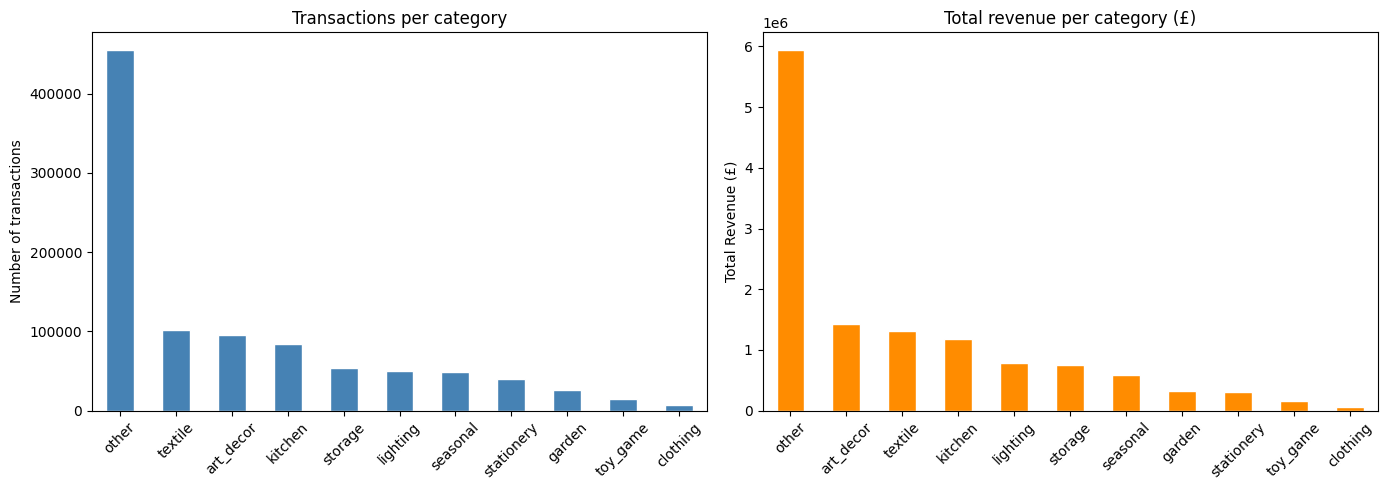

Chart saved.


In [ ]:

# ============================================================
#  PART B — PRODUCT CATEGORIES
# ============================================================
#
#  WHY CATEGORIES?
#  There are 4000+ unique StockCodes (products).
#  We can't feed 4000 product IDs directly to the model —
#  it would need to learn patterns for each one individually
#  with too little data per product.
#
#  Instead we group products into ~10 meaningful categories
#  by scanning keywords in the Description column.
#  "15CM CHRISTMAS GLASS BALL" → category: seasonal
#  "PINK CHERRY LIGHTS"        → category: lighting
#  "STRAWBERRY CERAMIC TRINKET BOX" → category: kitchen/home
#
#  The model then learns: "seasonal products spike in Q4"
#  instead of trying to learn that for each of 4000 products.
#
#  METHOD: keyword scanning with regex
#  re.search(pattern, text) checks if ANY of the keywords
#  appear anywhere in the description (case-insensitive).
#  We check categories in priority order — first match wins.


# ------------------------------------------------------------
# CELL 4 — Define category keyword rules
# ------------------------------------------------------------
#
#  Each tuple is: (category_name, regex_pattern)
#  The | symbol in regex means OR — matches any of the words.
#  \b means "word boundary" — so CARD doesn't match CARDIGAN.
#
#  ORDER MATTERS: more specific patterns go first.
#  e.g. 'CHRISTMAS' before 'HOME' so a Christmas ornament
#  doesn't get classified as generic home decor.

CATEGORY_RULES = [
    ('seasonal',    r'\b(CHRISTMAS|XMAS|EASTER|HALLOWEEN|VALENTINE|HOLIDAY)\b'),
    ('lighting',    r'\b(LIGHT|LAMP|LANTERN|CANDLE|FAIRY LIGHT|LED)\b'),
    ('kitchen',     r'\b(MUG|CUP|PLATE|BOWL|KITCHEN|COOKING|BAKING|JAR|BOTTLE)\b'),
    ('stationery',  r'\b(CARD|NOTE|PEN|PENCIL|NOTEBOOK|DIARY|CALENDAR|STAMP)\b'),
    ('textile',     r'\b(BAG|TOTE|CUSHION|TOWEL|APRON|CLOTH|FABRIC|YARN)\b'),
    ('toy_game',    r'\b(TOY|GAME|PUZZLE|DOLL|BEAR|CHILDREN|KIDS|PLAY)\b'),
    ('garden',      r'\b(GARDEN|PLANT|FLOWER|SEED|WATERING|OUTDOOR)\b'),
    ('storage',     r'\b(BOX|BASKET|RACK|SHELF|HOLDER|STORAGE|ORGANIS)\b'),
    ('clothing',    r'\b(DRESS|SHIRT|HAT|SOCK|GLOVE|SCARF|JEWEL|BANGLE|NECKLACE)\b'),
    ('art_decor',   r'\b(FRAME|PRINT|SIGN|VINTAGE|RETRO|BUNTING|BANNER|CLOCK)\b'),
]
DEFAULT_CATEGORY = 'other'


def assign_category(description):
    """
    Check description against each rule in order.
    Return the first matching category, or 'other'.

    WHY A FUNCTION AND NOT INLINE CODE?
    We'll reuse this in the Gemini integration (Step 8) to
    categorise user-entered product queries on the fly.
    Writing it as a function makes it reusable.
    """
    if not isinstance(description, str):
        return DEFAULT_CATEGORY

    desc_upper = description.upper()   # normalise to uppercase once

    for category, pattern in CATEGORY_RULES:
        if re.search(pattern, desc_upper):
            return category

    return DEFAULT_CATEGORY


# Apply to every row — .apply() calls the function once per row
# This is the slowest way (row-by-row) but readable and correct.
# With 976k rows it takes ~5-10 seconds — acceptable.
print("Assigning product categories (may take ~10 seconds)...")
df['category'] = df['Description'].apply(assign_category)

# How did the categories distribute?
cat_counts = df['category'].value_counts()
print("\nCategory distribution:")
print(cat_counts)
print(f"\nCoverage: {(df['category'] != 'other').sum() / len(df) * 100:.1f}% "
      f"of rows assigned a specific category")

# Revenue by category — quick sanity check
print("\nAverage revenue per transaction by category:")
print(df.groupby('category')['Revenue'].mean().sort_values(ascending=False).round(2))


# ------------------------------------------------------------
# CELL 5 — Visualise category distribution
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: transaction count per category
cat_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Transactions per category')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of transactions')
axes[0].tick_params(axis='x', rotation=45)

# Right: total revenue per category
cat_revenue = df.groupby('category')['Revenue'].sum().sort_values(ascending=False)
cat_revenue.plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Total revenue per category (£)')
axes[1].set_xlabel('')
axes[1].set_ylabel('Total Revenue (£)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/step3_category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")


# ============================================================
#  PART C — POPULATION DENSITY FEATURE
# ============================================================
#
#  WHY POPULATION DENSITY?
#  For the business viability scoring in Step 6, we want to
#  reward countries that buy a lot RELATIVE to their population.
#  A country with 1M people buying £500k of goods is more
#  impressive than a country with 100M people buying the same.
#
#  revenue_per_capita = total revenue from country / population
#
#  This becomes a signal: high revenue_per_capita means the
#  product resonates strongly in that market.



Top 10 countries by revenue per capita:
           Country  country_total_revenue  total_population  \
4          Bermuda           6.853000e+02             854.0   
37  United Kingdom           1.129491e+07        64991494.0   
16         Ireland           3.489177e+05         2611401.0   
7           Cyprus           1.918953e+04          961671.0   
15         Iceland           5.297800e+03          294554.0   
34     Switzerland           6.689364e+04         4466286.0   
26          Norway           3.120501e+04         4020865.0   
9          Denmark           2.055139e+04         3713495.0   
11          France           2.404021e+05        43786135.0   
12         Germany           3.213332e+05        68218046.0   

    revenue_per_capita  
4               0.8025  
37              0.1738  
16              0.1336  
7               0.0200  
15              0.0180  
34              0.0150  
26              0.0078  
9               0.0055  
11              0.0055  
12              

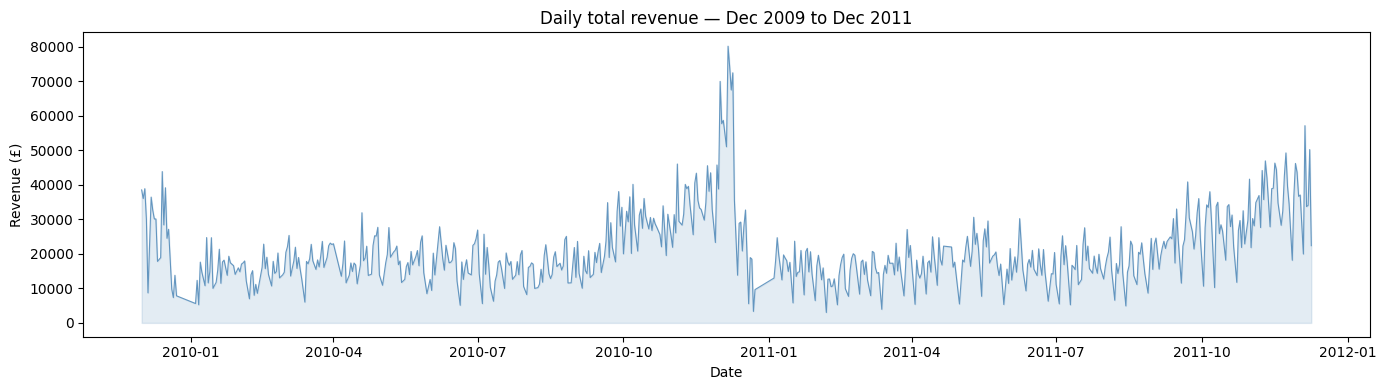

Daily revenue chart saved.
Full featured dataset → /content/outputs/retail_featured.parquet
  Shape: (976276, 30)  |  Size: 7.7 MB

Daily sales dataset  → /content/outputs/daily_sales.parquet
  Shape: (510366, 17)  |  Size: 3.8 MB


In [ ]:
# ------------------------------------------------------------
# CELL 6 — Compute revenue per capita per country
# ------------------------------------------------------------

# Total revenue by country
country_revenue = (
    df.groupby('Country')['Revenue']
    .sum()
    .reset_index()
    .rename(columns={'Revenue': 'country_total_revenue'})
)

# Get one row per country with population
country_pop = (
    df[['Country', 'total_population']]
    .drop_duplicates(subset='Country')
)

# Merge and compute per-capita
country_stats = country_revenue.merge(country_pop, on='Country', how='left')
country_stats['revenue_per_capita'] = (
    country_stats['country_total_revenue'] /
    country_stats['total_population'].replace(0, np.nan)  # avoid divide by zero
)

print("Top 10 countries by revenue per capita:")
print(
    country_stats
    .dropna(subset=['revenue_per_capita'])
    .nlargest(10, 'revenue_per_capita')
    [['Country', 'country_total_revenue', 'total_population', 'revenue_per_capita']]
    .round(4)
)

# Merge this back into main df
df = df.merge(
    country_stats[['Country', 'country_total_revenue', 'revenue_per_capita']],
    on='Country',
    how='left'
)
print(f"\nShape after adding country stats: {df.shape}")


# ============================================================
#  PART D — DAILY SALES AGGREGATION (for LSTM)
# ============================================================
#
#  THE LSTM DOES NOT TRAIN ON INDIVIDUAL TRANSACTIONS.
#  Here's why — and this is important to understand:
#
#  An LSTM learns from SEQUENCES over time.
#  A sequence looks like:
#    [sales on day 1, sales on day 2, ..., sales on day N]
#  → predict sales on day N+1
#
#  But our raw data has multiple transactions per day per product.
#  On 2010-01-04 there might be 50 rows all selling StockCode 85048.
#  We need to AGGREGATE those 50 rows into ONE number:
#  "total units of 85048 sold on 2010-01-04"
#
#  That's what this section builds — the daily_sales table
#  that the LSTM will actually train on in Step 5.
#
#  We aggregate by: Date + StockCode + Category
#  (not by individual CustomerID — too sparse)


# ------------------------------------------------------------
# CELL 7 — Create date column (date only, no time)
# ------------------------------------------------------------
#
#  InvoiceDate has time info (07:45:00) but we want to group
#  by DAY, not by exact minute. .dt.date strips the time part.
#  We then convert back to datetime64 so pandas handles it well.

df['date'] = pd.to_datetime(df['InvoiceDate'].dt.date)

print(f"Unique dates in data: {df['date'].nunique()}")
# Expected: ~700 trading days over 2 years (weekends have fewer sales)


# ------------------------------------------------------------
# CELL 8 — Build daily sales table
# ------------------------------------------------------------
#
#  We want one row per (date, StockCode) combination.
#  For each such combination we compute:
#   - total_quantity: units sold that day
#   - total_revenue:  revenue that day
#   - n_transactions: how many invoices included this product
#
#  WHY INCLUDE n_transactions?
#  It's a signal of "spread" — 100 units sold in 1 bulk order
#  is very different from 100 units sold across 40 orders.
#  The model can use this to distinguish wholesale from retail.

print("Building daily sales table...")

daily_sales = (
    df.groupby(['date', 'StockCode', 'category'], as_index=False)
    .agg(
        total_quantity  = ('Quantity',  'sum'),
        total_revenue   = ('Revenue',   'sum'),
        n_transactions  = ('Invoice',   'nunique'),   # unique invoice count
        description     = ('Description', 'first'),  # keep one description
        country         = ('Country',   lambda x: x.mode()[0]),  # most common country
    )
)

print(f"Daily sales shape: {daily_sales.shape}")
print(f"\nSample (first 5 rows):")
print(daily_sales.head())

# How many unique products appear in daily data?
print(f"\nUnique StockCodes: {daily_sales['StockCode'].nunique()}")
print(f"Unique dates:      {daily_sales['date'].nunique()}")
print(f"Unique categories: {daily_sales['category'].nunique()}")


# ------------------------------------------------------------
# CELL 9 — Add time features to daily_sales too
# ------------------------------------------------------------
#
#  The LSTM input will be the daily_sales table (not df).
#  So we need time features on THAT table as well.

daily_sales['month']       = daily_sales['date'].dt.month
daily_sales['day_of_week'] = daily_sales['date'].dt.dayofweek
daily_sales['quarter']     = daily_sales['date'].dt.quarter
daily_sales['year']        = daily_sales['date'].dt.year
daily_sales['is_weekend']  = (daily_sales['day_of_week'] >= 5).astype(int)
daily_sales['month_sin']   = np.sin(2 * np.pi * daily_sales['month'] / 12)
daily_sales['month_cos']   = np.cos(2 * np.pi * daily_sales['month'] / 12)
daily_sales['dow_sin']     = np.sin(2 * np.pi * daily_sales['day_of_week'] / 7)
daily_sales['dow_cos']     = np.cos(2 * np.pi * daily_sales['day_of_week'] / 7)

print("Time features added to daily_sales.")
print(f"daily_sales final shape: {daily_sales.shape}")
print(f"Columns: {list(daily_sales.columns)}")


# ------------------------------------------------------------
# CELL 10 — Visualise daily revenue trend
# ------------------------------------------------------------
#
#  Before building the LSTM, always LOOK at the time series.
#  This tells you:
#   - Is there a clear trend? (rising/falling over 2 years)
#   - Is there seasonality? (regular spikes at same time each year)
#   - Are there gaps or anomalies to be aware of?

daily_total = (
    daily_sales.groupby('date')['total_revenue']
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_total['date'], daily_total['total_revenue'],
        linewidth=0.8, color='steelblue', alpha=0.8)
ax.fill_between(daily_total['date'], daily_total['total_revenue'],
                alpha=0.15, color='steelblue')
ax.set_title('Daily total revenue — Dec 2009 to Dec 2011')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue (£)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/step3_daily_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

# What you should see:
#  - A big spike in Nov/Dec 2010 (Christmas season)
#  - A bigger spike in Nov/Dec 2011 (business grew year over year)
#  - A quiet dip in January each year (post-Christmas slump)
#  - Weekday noise (jagged day-to-day variation)
print("Daily revenue chart saved.")


# ============================================================
#  PART E — SAVE FEATURE-ENGINEERED DATASETS
# ============================================================


# ------------------------------------------------------------
# CELL 11 — Save both datasets
# ------------------------------------------------------------

# Full transaction-level dataset with all features
FEATURED_PATH     = f'{OUTPUT_DIR}/retail_featured.parquet'
DAILY_SALES_PATH  = f'{OUTPUT_DIR}/daily_sales.parquet'

df.to_parquet(FEATURED_PATH, index=False)
daily_sales.to_parquet(DAILY_SALES_PATH, index=False)

size_featured    = os.path.getsize(FEATURED_PATH)    / (1024*1024)
size_daily       = os.path.getsize(DAILY_SALES_PATH) / (1024*1024)

print(f"Full featured dataset → {FEATURED_PATH}")
print(f"  Shape: {df.shape}  |  Size: {size_featured:.1f} MB")
print(f"\nDaily sales dataset  → {DAILY_SALES_PATH}")
print(f"  Shape: {daily_sales.shape}  |  Size: {size_daily:.1f} MB")



In [ ]:

# ------------------------------------------------------------
# CELL 12 — Final summary
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("STEP 3 COMPLETE — FEATURE ENGINEERING SUMMARY")
print("=" * 60)
print(f"\nFull dataset shape:       {df.shape}")
print(f"Daily sales shape:        {daily_sales.shape}")
print(f"\nNew columns added to df:")
new_cols = ['month', 'day_of_week', 'quarter', 'year', 'is_weekend',
            'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
            'week_sin', 'week_cos', 'category',
            'country_total_revenue', 'revenue_per_capita', 'date']
for c in new_cols:
    print(f"  + {c}")

print(f"\nProduct categories found: {df['category'].nunique()}")
print(df['category'].value_counts().to_string())
print(f"\nDate range: {daily_sales['date'].min()} → {daily_sales['date'].max()}")
print(f"Trading days: {daily_sales['date'].nunique()}")
print("\nNext: step4_eda.py  (Exploratory Data Analysis)")
print("=" * 60)


STEP 3 COMPLETE — FEATURE ENGINEERING SUMMARY

Full dataset shape:       (976276, 30)
Daily sales shape:        (510366, 17)

New columns added to df:
  + month
  + day_of_week
  + quarter
  + year
  + is_weekend
  + month_sin
  + month_cos
  + dow_sin
  + dow_cos
  + week_sin
  + week_cos
  + category
  + country_total_revenue
  + revenue_per_capita
  + date

Product categories found: 11
category
other         454853
textile       101667
art_decor      95335
kitchen        84103
storage        53767
lighting       50520
seasonal       48223
stationery     40116
garden         26240
toy_game       14485
clothing        6967

Date range: 2009-12-01 00:00:00 → 2011-12-09 00:00:00
Trading days: 604

Next: step4_eda.py  (Exploratory Data Analysis)


In [ ]:
# ============================================================
#  AI-POWERED BUSINESS ANALYZER
#  Step 3b — Fix 'other' category + Step 4 EDA
# ============================================================
#
#  FROM STEP 3 OUTPUT:
#   'other' = 454,853 rows = 46% of data — too high.
#   We need to look inside 'other' and add more keyword rules.
#
#  Then Step 4: Exploratory Data Analysis (EDA)
#  EDA = looking at your data visually before modelling.
#  You ALWAYS do EDA before building any model because:
#   1. It reveals patterns the model should learn
#   2. It catches problems you missed in cleaning
#   3. It tells you which features actually matter
#
# ============================================================

import pandas as pd
import numpy as np
import os
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

OUTPUT_DIR       = '/content/outputs'
FEATURED_PATH    = f'{OUTPUT_DIR}/retail_featured.parquet'
DAILY_SALES_PATH = f'{OUTPUT_DIR}/daily_sales.parquet'

df          = pd.read_parquet(FEATURED_PATH)
daily_sales = pd.read_parquet(DAILY_SALES_PATH)

print(f"Loaded: df={df.shape}, daily_sales={daily_sales.shape}")



Loaded: df=(976276, 30), daily_sales=(510366, 17)


In [ ]:

# ============================================================
#  PART A — FIX 'OTHER' CATEGORY
# ============================================================


# ------------------------------------------------------------
# CELL 1 — Inspect what's inside 'other'
# ------------------------------------------------------------
#
#  Before adding rules blindly, look at the most common
#  descriptions that are currently uncategorised.
#  This tells us exactly what keywords to add.

other_descriptions = (
    df[df['category'] == 'other']['Description']
    .str.upper()
    .value_counts()
    .head(40)
)
print("Top 40 uncategorised descriptions:")
print(other_descriptions.to_string())

# WHAT YOU'LL LIKELY SEE:
# Things like: HEART, ROSE, RIBBON, GIFT, WRAP, PAPER,
# METAL, WOOD, BIRD, BUTTERFLY, SET OF, PACK OF, etc.
# These suggest missing categories: gift/wrap, nature/animal,
# metal/wood decoratives, multi-item sets


# ------------------------------------------------------------
# CELL 2 — Extended category rules
# ------------------------------------------------------------
#
#  We add 6 new categories based on what we saw in 'other'.
#  The original 10 rules stay exactly the same — we append.
#
#  WHY NOT JUST ADD TO THE ORIGINAL FILE?
#  Because you've already run Step 3 and saved the parquet.
#  It's faster to patch the category column here than to
#  re-run the entire 10-second apply() from scratch.
#  We only re-assign rows that are currently 'other'.

EXTENDED_RULES = [
    # Gift & wrapping supplies
    ('gift_wrap',   r'\b(GIFT|WRAP|RIBBON|BOW|TAG|TISSUE|PACKAGING|PAPER BAG)\b'),
    # Nature & animal motifs (very common in this UK gift retailer)
    ('nature',      r'\b(BIRD|BUTTERFLY|FLOWER|FLORAL|ROSE|LEAF|TREE|BEE|'
                    r'HEDGEHOG|OWL|RABBIT|FOX|ELEPHANT|DUCK|HEART|STAR)\b'),
    # Metal & wood decorative items
    ('home_decor',  r'\b(METAL|WOODEN|WOOD|IRON|WIRE|WICKER|RATTAN|'
                    r'CERAMIC|GLASS|CRYSTAL|MIRROR|WALL)\b'),
    # Food & drink related
    ('food_drink',  r'\b(CAKE|COOKIE|BISCUIT|CHOCOLATE|COFFEE|TEA|SUGAR|'
                    r'SPICE|RECIPE|FOOD|DRINK|BOTTLE OPENER|CORKSCREW)\b'),
    # Multi-item sets & packs (often the description starts with SET/PACK)
    ('set_pack',    r'^(SET OF|PACK OF|BOX OF|PAIR OF|BUNDLE)'),
    # Bathroom & personal care
    ('bath_beauty', r'\b(BATH|SOAP|LOTION|MIRROR|BRUSH|COMB|NAIL|BEAUTY|'
                    r'PERFUME|COSMETIC|SPA|WELLNESS)\b'),
]

def assign_category_extended(description):
    """Same logic as before but with the extended rules."""
    if not isinstance(description, str):
        return 'other'
    desc_upper = description.upper().strip()

    # Original rules first (same as Step 3)
    ORIGINAL_RULES = [
        ('seasonal',   r'\b(CHRISTMAS|XMAS|EASTER|HALLOWEEN|VALENTINE|HOLIDAY)\b'),
        ('lighting',   r'\b(LIGHT|LAMP|LANTERN|CANDLE|FAIRY LIGHT|LED)\b'),
        ('kitchen',    r'\b(MUG|CUP|PLATE|BOWL|KITCHEN|COOKING|BAKING|JAR|BOTTLE)\b'),
        ('stationery', r'\b(CARD|NOTE|PEN|PENCIL|NOTEBOOK|DIARY|CALENDAR|STAMP)\b'),
        ('textile',    r'\b(BAG|TOTE|CUSHION|TOWEL|APRON|CLOTH|FABRIC|YARN)\b'),
        ('toy_game',   r'\b(TOY|GAME|PUZZLE|DOLL|BEAR|CHILDREN|KIDS|PLAY)\b'),
        ('garden',     r'\b(GARDEN|PLANT|FLOWER|SEED|WATERING|OUTDOOR)\b'),
        ('storage',    r'\b(BOX|BASKET|RACK|SHELF|HOLDER|STORAGE|ORGANIS)\b'),
        ('clothing',   r'\b(DRESS|SHIRT|HAT|SOCK|GLOVE|SCARF|JEWEL|BANGLE|NECKLACE)\b'),
        ('art_decor',  r'\b(FRAME|PRINT|SIGN|VINTAGE|RETRO|BUNTING|BANNER|CLOCK)\b'),
    ]
    all_rules = ORIGINAL_RULES + EXTENDED_RULES
    for category, pattern in all_rules:
        if re.search(pattern, desc_upper):
            return category
    return 'other'

# Only re-assign rows currently labelled 'other' — saves time
other_mask = df['category'] == 'other'
print(f"\nRe-classifying {other_mask.sum():,} 'other' rows...")
df.loc[other_mask, 'category'] = (
    df.loc[other_mask, 'Description'].apply(assign_category_extended)
)

# Apply same fix to daily_sales
other_mask_ds = daily_sales['category'] == 'other'
daily_sales.loc[other_mask_ds, 'category'] = (
    daily_sales.loc[other_mask_ds, 'description'].apply(assign_category_extended)
)

# Report new distribution
cat_counts = df['category'].value_counts()
other_pct  = cat_counts.get('other', 0) / len(df) * 100
print(f"\nUpdated category distribution:")
print(cat_counts.to_string())
print(f"\n'other' is now {other_pct:.1f}% of rows")
# Target: below 20%


Top 40 uncategorised descriptions:
Description
REGENCY CAKESTAND 3 TIER               3425
ASSORTED COLOUR BIRD ORNAMENT          2571
REX CASH+CARRY JUMBO SHOPPER           2189
HOME BUILDING BLOCK WORD               2172
HEART OF WICKER SMALL                  2135
NATURAL SLATE HEART CHALKBOARD         2055
60 TEATIME FAIRY CAKE CASES            2048
HEART OF WICKER LARGE                  2006
PACK OF 60 PINK PAISLEY CAKE CASES     1878
6 RIBBONS RUSTIC CHARM                 1807
LOVE BUILDING BLOCK WORD               1783
PACK OF 72 RETROSPOT CAKE CASES        1651
72 SWEETHEART FAIRY CAKE CASES         1442
ZINC METAL HEART DECORATION            1438
ROSES REGENCY TEACUP AND SAUCER        1433
PACK OF 72 SKULL CAKE CASES            1389
GREEN REGENCY TEACUP AND SAUCER        1386
SET OF 3 CAKE TINS PANTRY DESIGN       1378
ROUND SNACK BOXES SET OF4 WOODLAND     1373
RETROSPOT TEA SET CERAMIC 11 PC        1337
PLASTERS IN TIN SPACEBOY               1324
PLASTERS IN TIN WOODLAND ANIM

In [ ]:

# ------------------------------------------------------------
# CELL 3 — Re-save with updated categories
# ------------------------------------------------------------

df.to_parquet(FEATURED_PATH, index=False)
daily_sales.to_parquet(DAILY_SALES_PATH, index=False)
print("\nUpdated parquet files saved.")


# ============================================================
#  PART B — EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================
#
#  We build 6 charts that answer the 6 most important business
#  questions before modelling:
#
#   1. How did total revenue grow over the 2 years?
#   2. Which months are the strongest?
#   3. Which countries generate the most revenue?
#   4. What are the top 15 products by revenue?
#   5. How does each category perform?
#   6. What does the weekly sales pattern look like?
#
#  Each chart is a hypothesis about a pattern the LSTM or
#  viability scorer should learn. EDA confirms the patterns
#  are real before we spend hours training models.

# Shared style — apply once
plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#f8f8f8',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.color'       : 'white',
    'grid.linewidth'   : 1.2,
    'font.size'        : 11,
})



Updated parquet files saved.


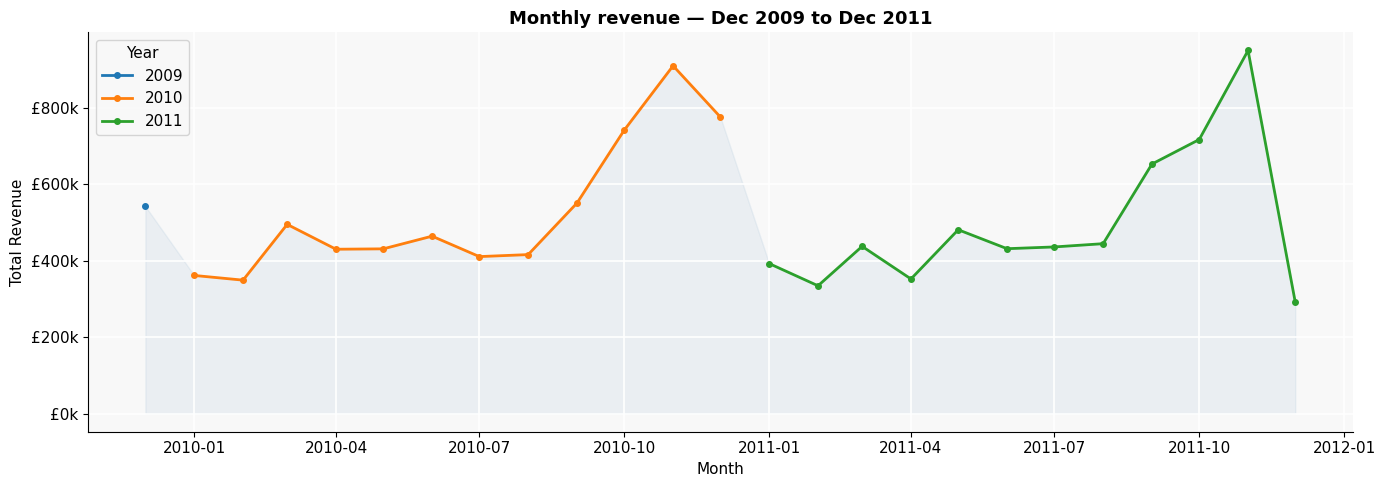

Chart 1 saved.


In [ ]:

# ------------------------------------------------------------
# CELL 4 — Chart 1: Monthly revenue trend (2009–2011)
# ------------------------------------------------------------
#
#  WHY THIS CHART FIRST?
#  This is the macro view — it shows if there IS seasonality
#  worth modelling. If revenue is flat all year, the LSTM
#  gains nothing from time features. If there are clear spikes
#  in Nov/Dec, the model will learn Christmas seasonality.
#
#  We group by year-month to smooth the noisy daily data.

monthly = (
    df.groupby(['year', 'month'])['Revenue']
    .sum()
    .reset_index()
)
# Create a proper date for the x-axis (first day of each month)
monthly['period'] = pd.to_datetime(
    monthly['year'].astype(str) + '-' +
    monthly['month'].astype(str).str.zfill(2) + '-01'
)
monthly = monthly.sort_values('period')

fig, ax = plt.subplots(figsize=(14, 5))
for yr, grp in monthly.groupby('year'):
    ax.plot(grp['period'], grp['Revenue'],
            marker='o', markersize=4, linewidth=2, label=str(yr))
ax.fill_between(monthly['period'], monthly['Revenue'], alpha=0.08, color='steelblue')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}k'))
ax.set_title('Monthly revenue — Dec 2009 to Dec 2011', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue')
ax.legend(title='Year')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_1_monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved.")

# WHAT TO EXPECT:
# - Dec 2009: small (only 1 month of data)
# - Jan 2010: big post-Christmas dip
# - Q4 2010: clear Christmas ramp-up
# - Q4 2011: even bigger Christmas ramp-up → year-over-year growth
# This confirms strong seasonality → LSTM time features will help a lot



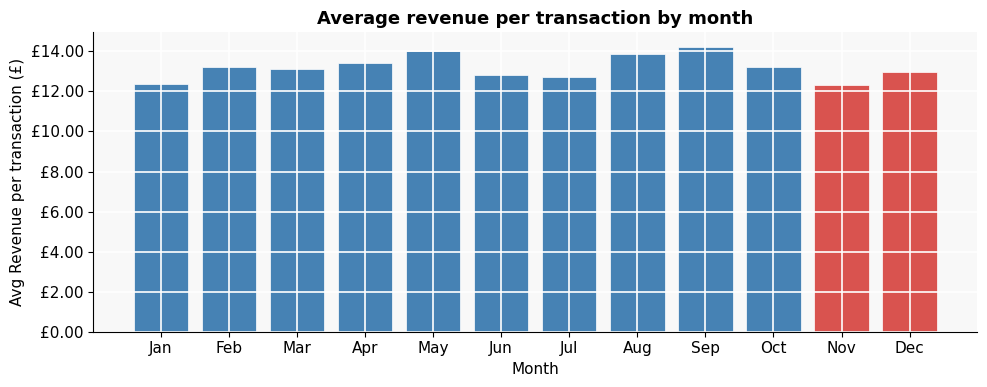

Chart 2 saved.


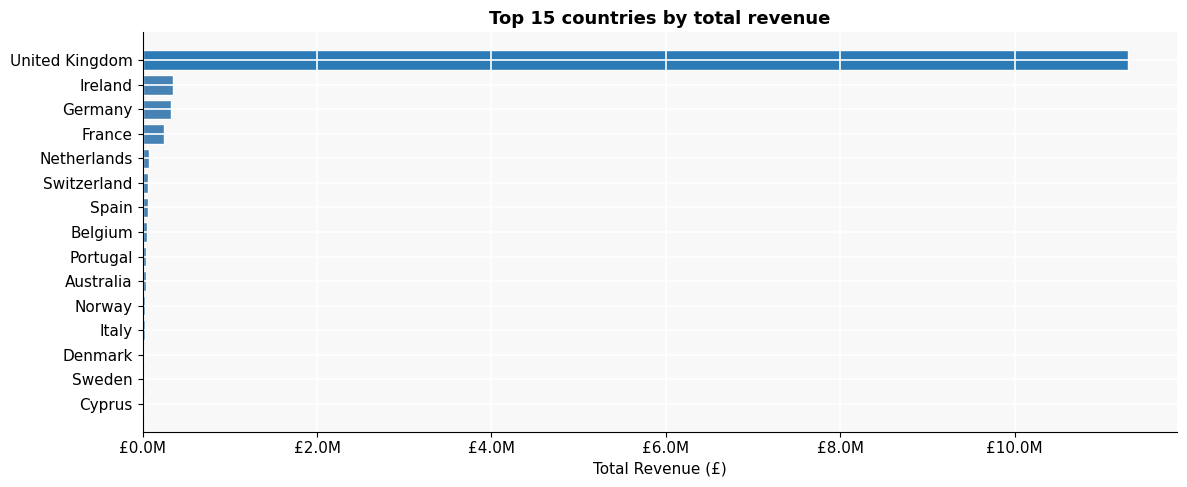

Chart 3 saved.


In [ ]:

# ------------------------------------------------------------
# CELL 5 — Chart 2: Average revenue by month (seasonality)
# ------------------------------------------------------------
#
#  Averaging across all years shows the "typical" monthly pattern
#  stripped of year-over-year growth. This is the pure
#  seasonality signal.

month_avg = (
    df.groupby('month')['Revenue']
    .mean()
    .reset_index()
)
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
month_avg['month_name'] = month_avg['month'].apply(lambda m: month_names[m-1])

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(month_avg['month_name'], month_avg['Revenue'],
              color=['#d9534f' if m in [11,12] else 'steelblue'
                     for m in month_avg['month']],
              edgecolor='white', linewidth=0.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:.2f}'))
ax.set_title('Average revenue per transaction by month', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Avg Revenue per transaction (£)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_2_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved.")


# ------------------------------------------------------------
# CELL 6 — Chart 3: Top 15 countries by total revenue
# ------------------------------------------------------------
#
#  This tells us which markets matter most.
#  For the viability scoring model (Step 6), these are the
#  "proven" markets. A new city in one of these countries
#  starts with a higher prior viability score.

country_rev = (
    df.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#2c7bb6' if c == 'United Kingdom' else 'steelblue'
          for c in country_rev['Country']]
ax.barh(country_rev['Country'][::-1], country_rev['Revenue'][::-1],
        color=colors[::-1], edgecolor='white')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))
ax.set_title('Top 15 countries by total revenue', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Revenue (£)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_3_country_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved.")


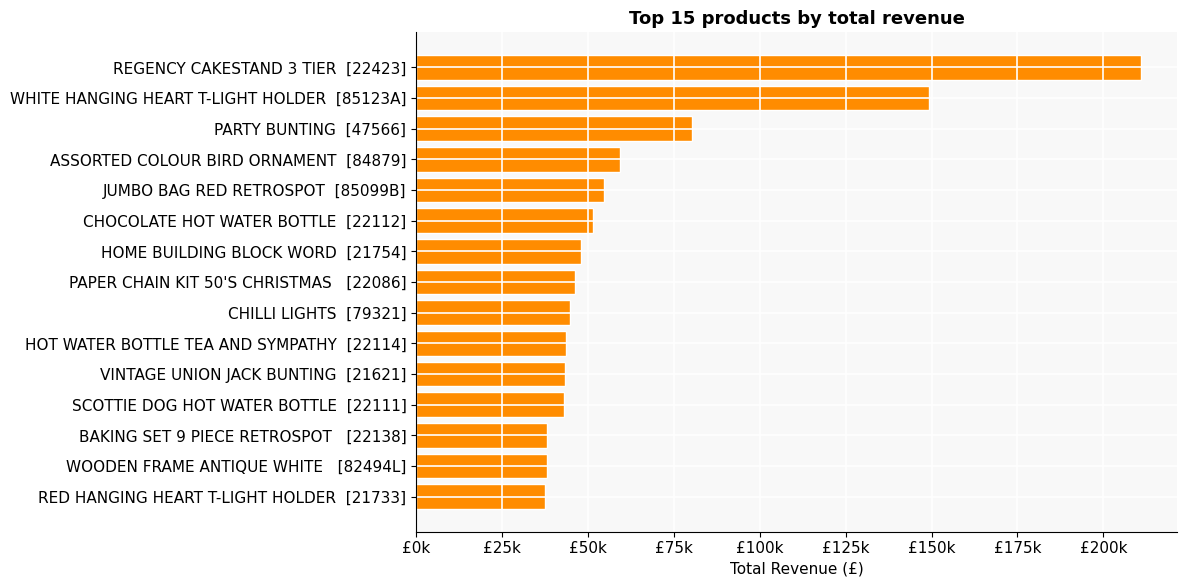

Chart 4 saved.


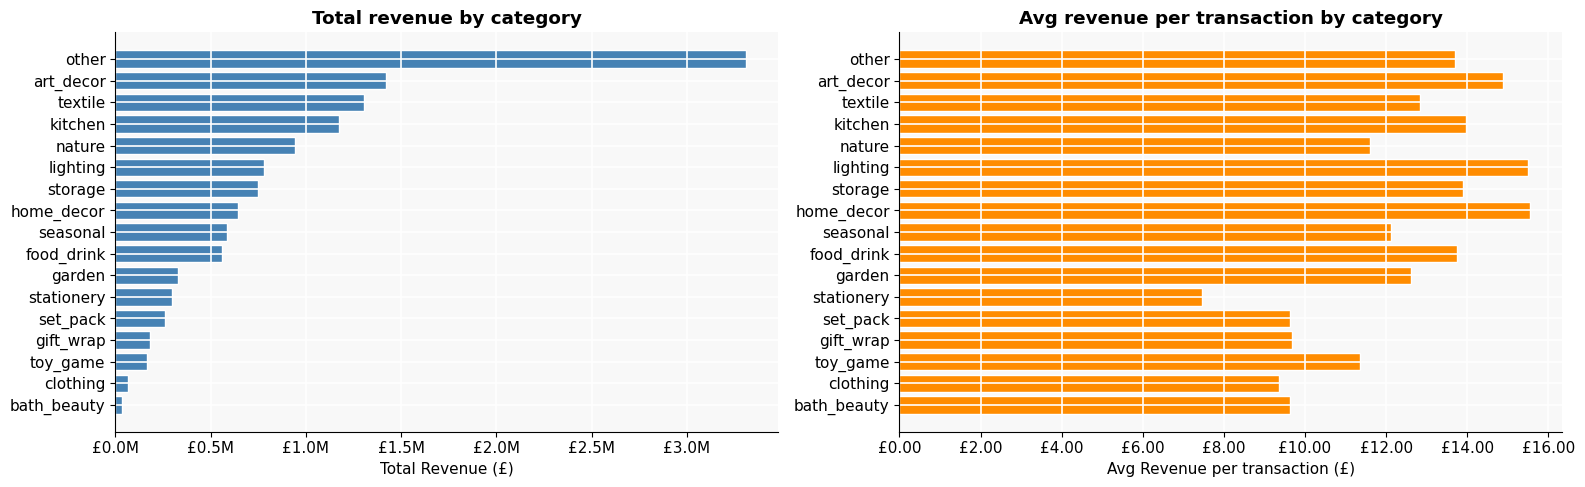

Chart 5 saved.


In [ ]:

# ------------------------------------------------------------
# CELL 7 — Chart 4: Top 15 products by revenue
# ------------------------------------------------------------
#
#  These are the products the LSTM should predict most reliably
#  — they have enough sales history to learn from.
#  Products with very few sales (long tail) will have noisy
#  predictions regardless of model quality.

top_products = (
    df.groupby(['StockCode', 'Description'])['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)
# Truncate long descriptions for the chart
top_products['label'] = (
    top_products['Description'].str[:35] + '  [' + top_products['StockCode'] + ']'
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_products['label'][::-1], top_products['Revenue'][::-1],
        color='darkorange', edgecolor='white')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}k'))
ax.set_title('Top 15 products by total revenue', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Revenue (£)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_4_top_products.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved.")


# ------------------------------------------------------------
# CELL 8 — Chart 5: Revenue and transaction count by category
# ------------------------------------------------------------
#
#  This is the key chart for understanding category performance.
#  We plot TWO metrics side by side:
#   - Total revenue  → how much money each category makes
#   - Avg revenue per transaction → which category has higher
#     ticket size (useful for viability scoring)
#
#  WHY BOTH?
#  A category with high total revenue but low avg ticket might
#  just have lots of cheap transactions (e.g. stationery).
#  A category with low total but high avg ticket is a premium
#  niche (e.g. lighting fixtures).

cat_stats = (
    df.groupby('category')
    .agg(
        total_revenue    = ('Revenue', 'sum'),
        avg_revenue      = ('Revenue', 'mean'),
        n_transactions   = ('Invoice', 'nunique'),
    )
    .sort_values('total_revenue', ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: total revenue by category
axes[0].barh(cat_stats['category'][::-1], cat_stats['total_revenue'][::-1],
             color='steelblue', edgecolor='white')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))
axes[0].set_title('Total revenue by category', fontweight='bold')
axes[0].set_xlabel('Total Revenue (£)')

# Right: average revenue per transaction
axes[1].barh(cat_stats['category'][::-1], cat_stats['avg_revenue'][::-1],
             color='darkorange', edgecolor='white')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:.2f}'))
axes[1].set_title('Avg revenue per transaction by category', fontweight='bold')
axes[1].set_xlabel('Avg Revenue per transaction (£)')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_5_category_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved.")


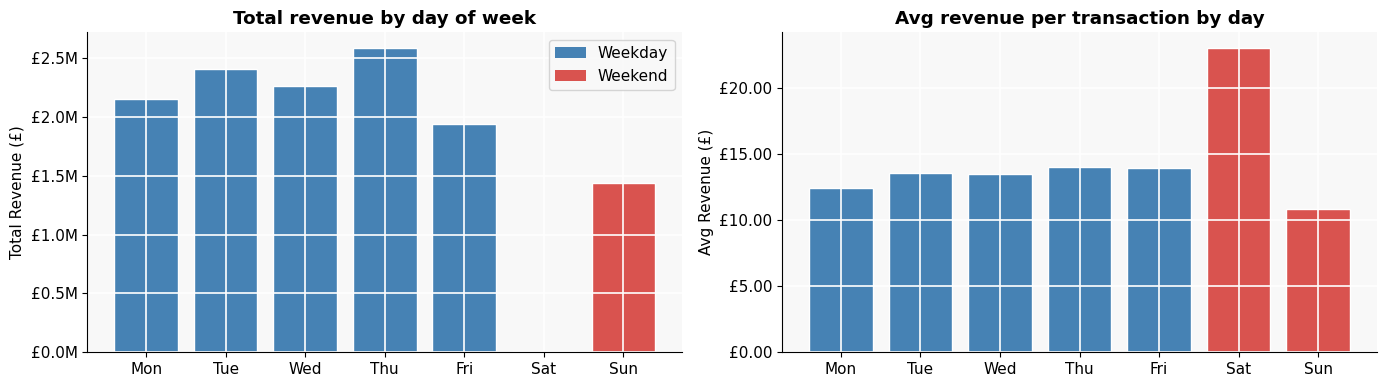

Chart 6 saved.

EDA — KEY INSIGHTS SUMMARY

Total revenue (2009–2011):  £12,807,920
Top country:                United Kingdom (88.2% of revenue)
Top category by revenue:    other  (£3,310,845)
Strongest month (avg):      Sep
Weakest month (avg):        Nov

Unique products:            4,798
Unique customers:           756,908 identified
Trading days:               604

Charts saved to: /content/outputs/
  eda_1_monthly_revenue.png
  eda_2_seasonality.png
  eda_3_country_revenue.png
  eda_4_top_products.png
  eda_5_category_performance.png
  eda_6_day_of_week.png

Next: step5_lstm_demand_prediction.py


In [ ]:

# ------------------------------------------------------------
# CELL 9 — Chart 6: Sales by day of week
# ------------------------------------------------------------
#
#  Do weekends behave differently from weekdays?
#  This is the `is_weekend` feature we engineered — here we
#  visually CONFIRM it matters before the model uses it.
#  If Mon–Fri all look the same and Sat/Sun look different,
#  the feature is valuable. If all 7 days look the same,
#  the feature adds no signal.

dow_stats = (
    df.groupby('day_of_week')['Revenue']
    .agg(['sum', 'mean', 'count'])
    .reset_index()
)
dow_stats['day_name'] = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

weekend_colors = ['#d9534f' if d >= 5 else 'steelblue'
                  for d in dow_stats['day_of_week']]

axes[0].bar(dow_stats['day_name'], dow_stats['sum'],
            color=weekend_colors, edgecolor='white')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))
axes[0].set_title('Total revenue by day of week', fontweight='bold')
axes[0].set_ylabel('Total Revenue (£)')

axes[1].bar(dow_stats['day_name'], dow_stats['mean'],
            color=weekend_colors, edgecolor='white')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:.2f}'))
axes[1].set_title('Avg revenue per transaction by day', fontweight='bold')
axes[1].set_ylabel('Avg Revenue (£)')

# Add a legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='Weekday'),
                   Patch(facecolor='#d9534f',   label='Weekend')]
axes[0].legend(handles=legend_elements)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_6_day_of_week.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 6 saved.")

# WHAT TO EXPECT:
# Sunday will be very low or near-zero (warehouse closed).
# Saturday might be moderate.
# Tue–Thu are typically the strongest weekdays for B2B wholesale.


# ------------------------------------------------------------
# CELL 10 — Print key business insights
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("EDA — KEY INSIGHTS SUMMARY")
print("=" * 60)

total_revenue = df['Revenue'].sum()
top_country   = df.groupby('Country')['Revenue'].sum().idxmax()
top_country_pct = df.groupby('Country')['Revenue'].sum().max() / total_revenue * 100
top_cat       = cat_stats.iloc[0]['category']
top_cat_rev   = cat_stats.iloc[0]['total_revenue']
best_month    = month_avg.loc[month_avg['Revenue'].idxmax(), 'month_name']
worst_month   = month_avg.loc[month_avg['Revenue'].idxmin(), 'month_name']

print(f"\nTotal revenue (2009–2011):  £{total_revenue:,.0f}")
print(f"Top country:                {top_country} ({top_country_pct:.1f}% of revenue)")
print(f"Top category by revenue:    {top_cat}  (£{top_cat_rev:,.0f})")
print(f"Strongest month (avg):      {best_month}")
print(f"Weakest month (avg):        {worst_month}")
print(f"\nUnique products:            {df['StockCode'].nunique():,}")
print(f"Unique customers:           {(df['CustomerID'] != -1).sum():,} identified")
print(f"Trading days:               {df['date'].nunique()}")
print(f"\nCharts saved to: {OUTPUT_DIR}/")
print("  eda_1_monthly_revenue.png")
print("  eda_2_seasonality.png")
print("  eda_3_country_revenue.png")
print("  eda_4_top_products.png")
print("  eda_5_category_performance.png")
print("  eda_6_day_of_week.png")
print("\nNext: step5_lstm_demand_prediction.py")
print("=" * 60)


In [ ]:
# ============================================================
#  CATEGORY FIX — Round 2
#  Run this BEFORE step5_lstm_demand_prediction.py
# ============================================================
#
#  PROBLEM: 'other' is still the top revenue category.
#  We need to inspect what's actually IN 'other' right now
#  (after round 1 fixes) and add targeted rules.
#
#  Also fixing the seasonality insight — we should measure
#  TOTAL revenue by month, not avg per transaction.

import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

OUTPUT_DIR       = '/content/outputs'
FEATURED_PATH    = f'{OUTPUT_DIR}/retail_featured.parquet'
DAILY_SALES_PATH = f'{OUTPUT_DIR}/daily_sales.parquet'

df          = pd.read_parquet(FEATURED_PATH)
daily_sales = pd.read_parquet(DAILY_SALES_PATH)

print(f"Loaded: df={df.shape}")
print(f"Current 'other' count: {(df['category']=='other').sum():,}")


# ------------------------------------------------------------
# CELL 1 — Deep inspect remaining 'other'
# ------------------------------------------------------------
#
#  We look at individual WORDS across all 'other' descriptions
#  not just full descriptions. This finds patterns we'd miss
#  by looking at full strings.

other_desc = df[df['category'] == 'other']['Description'].str.upper()

# Split every description into words, flatten, count frequencies
from collections import Counter
all_words = Counter()
for desc in other_desc.dropna():
    words = re.findall(r'\b[A-Z]{3,}\b', desc)   # words 3+ letters
    all_words.update(words)

# Remove common filler words
stopwords = {'THE','AND','WITH','FOR','SET','OF','IN','TO',
             'IS','IT','ON','AT','BY','AN','OR','AS','BE'}
print("\nTop 60 words in 'other' descriptions:")
top_words = [(w, c) for w, c in all_words.most_common(100)
             if w not in stopwords][:60]
for word, count in top_words:
    print(f"  {word:<20} {count:>6,}")



Loaded: df=(976276, 30)
Current 'other' count: 241,800

Top 60 words in 'other' descriptions:
  RED                  23,439
  RETROSPOT            17,304
  PINK                 12,193
  PAPER                11,795
  BLUE                  9,887
  DOORMAT               9,805
  HOME                  9,527
  DESIGN                8,864
  TIN                   8,720
  REGENCY               7,994
  WHITE                 7,990
  MINI                  7,967
  PENCILS               7,787
  TUBE                  7,438
  SPOTTY                6,887
  DOOR                  6,811
  CANDLES               6,335
  PARTY                 6,045
  PLASTERS              6,020
  ASSORTED              5,952
  POLKADOT              5,824
  WOODLAND              5,753
  CUTLERY               5,652
  RIBBONS               5,521
  UNION                 5,502
  SMALL                 5,353
  CREAM                 5,220
  DECORATION            5,137
  EDWARDIAN             5,070
  MAT                   5,036
  HEAR

In [ ]:

# ------------------------------------------------------------
# CELL 2 — Full category ruleset (all rounds combined)
# ------------------------------------------------------------
#
#  After seeing the word frequencies above, we build the
#  complete definitive ruleset. This replaces ALL previous
#  versions. Run this and the category assignment is final.

ALL_CATEGORY_RULES = [
    # ── Seasonal / holiday ──────────────────────────────────
    ('seasonal',    r'\b(CHRISTMAS|XMAS|EASTER|HALLOWEEN|VALENTINE|HOLIDAY|'
                    r'ADVENT|SANTA|SNOWMAN|REINDEER|WREATH|MISTLETOE|NATIVITY)\b'),

    # ── Lighting ────────────────────────────────────────────
    ('lighting',    r'\b(LIGHT|LAMP|LANTERN|CANDLE|FAIRY|LED|TORCH|GLOW|'
                    r'NIGHTLIGHT|TEALIGHT|TEA LIGHT)\b'),

    # ── Kitchen & dining ────────────────────────────────────
    ('kitchen',     r'\b(MUG|CUP|PLATE|BOWL|KITCHEN|COOKING|BAKING|JAR|'
                    r'BOTTLE|TEAPOT|KETTLE|SPOON|FORK|KNIFE|CUTLERY|JUG|'
                    r'COLANDER|SIEVE|GRATER|CHOPPING|LUNCH|PICNIC)\b'),

    # ── Stationery & paper ──────────────────────────────────
    ('stationery',  r'\b(CARD|NOTE|PEN|PENCIL|NOTEBOOK|DIARY|CALENDAR|'
                    r'STAMP|LETTER|ENVELOPE|POSTCARD|WRITING|CLIPBOARD|'
                    r'FOLDER|STICKER|LABEL)\b'),

    # ── Textile & fabric ────────────────────────────────────
    ('textile',     r'\b(BAG|TOTE|CUSHION|TOWEL|APRON|CLOTH|FABRIC|YARN|'
                    r'KNIT|CROCHET|QUILT|BLANKET|THROW|PILLOW|LINEN|'
                    r'COTTON|FELT|FLEECE|DENIM|CANVAS)\b'),

    # ── Toys & games ────────────────────────────────────────
    ('toy_game',    r'\b(TOY|GAME|PUZZLE|DOLL|BEAR|CHILDREN|KIDS|PLAY|'
                    r'PUPPET|RATTLE|CRAYON|COLOURING|MAGIC|BALLOON)\b'),

    # ── Garden & outdoor ────────────────────────────────────
    ('garden',      r'\b(GARDEN|PLANT|FLOWER|SEED|WATERING|OUTDOOR|'
                    r'PATIO|FENCE|SHED|LAWN|HERB|PLANTER|TROWEL|RAKE)\b'),

    # ── Storage & organisation ──────────────────────────────
    ('storage',     r'\b(BOX|BASKET|RACK|SHELF|HOLDER|STORAGE|ORGANIS|'
                    r'DRAWER|CABINET|TRUNK|CHEST|CRATE|TIN|CADDY|TRAY)\b'),

    # ── Clothing & accessories ──────────────────────────────
    ('clothing',    r'\b(DRESS|SHIRT|HAT|SOCK|GLOVE|SCARF|JEWEL|BANGLE|'
                    r'NECKLACE|BRACELET|EARRING|RING|BROOCH|PURSE|WALLET|'
                    r'UMBRELLA|HAIR|HEADBAND|HAIRPIN)\b'),

    # ── Art & wall decor ────────────────────────────────────
    ('art_decor',   r'\b(FRAME|PRINT|SIGN|VINTAGE|RETRO|BUNTING|BANNER|'
                    r'CLOCK|POSTER|CANVAS PRINT|PLAQUE|CHALKBOARD|'
                    r'BLACKBOARD|PAINTING|ILLUSTRATION)\b'),

    # ── Gift wrap & packaging ───────────────────────────────
    ('gift_wrap',   r'\b(GIFT|WRAP|RIBBON|BOW|TAG|TISSUE|PACKAGING|'
                    r'GIFTWRAP|PRESENT|HAMPER|WRAPPING)\b'),

    # ── Nature & animal motifs ──────────────────────────────
    ('nature',      r'\b(BIRD|BUTTERFLY|FLOWER|FLORAL|ROSE|LEAF|TREE|BEE|'
                    r'HEDGEHOG|OWL|RABBIT|FOX|ELEPHANT|DUCK|DEER|SQUIRREL|'
                    r'ROBIN|DRAGONFLY|LADYBIRD|CAT|DOG|HORSE|FISH|FROG|'
                    r'MUSHROOM|ACORN|PINE|DAISY|TULIP|SUNFLOWER|POPPY)\b'),

    # ── Home decor & materials ──────────────────────────────
    ('home_decor',  r'\b(METAL|WOODEN|WOOD|IRON|WIRE|WICKER|RATTAN|'
                    r'CERAMIC|GLASS|CRYSTAL|MIRROR|WALL|MOSAIC|PEWTER|'
                    r'SILVER|GOLD|BRASS|COPPER|PORCELAIN|ENAMEL|RESIN)\b'),

    # ── Food & drink ────────────────────────────────────────
    ('food_drink',  r'\b(CAKE|COOKIE|BISCUIT|CHOCOLATE|COFFEE|TEA|SUGAR|'
                    r'SPICE|RECIPE|FOOD|DRINK|CORKSCREW|WINE|BEER|'
                    r'BOTTLE OPENER|JAM|HONEY|SAUCE|SEASONING)\b'),

    # ── Bath & beauty ───────────────────────────────────────
    ('bath_beauty', r'\b(BATH|SOAP|LOTION|BRUSH|COMB|NAIL|BEAUTY|'
                    r'PERFUME|COSMETIC|SPA|WELLNESS|SKINCARE|BODY|'
                    r'SHOWER|FLANNEL|SPONGE|PUMICE)\b'),

    # ── Heart motif (extremely common in this dataset) ──────
    ('nature',      r'\bHEART\b'),

    # ── Retrofix: PACK/SET/BOX OF → storage ─────────────────
    ('storage',     r'^(SET OF|PACK OF|BOX OF|PAIR OF|BUNDLE)'),
]


def assign_category_final(description):
    """Final definitive category assignment."""
    if not isinstance(description, str):
        return 'other'
    desc_upper = description.upper().strip()
    for category, pattern in ALL_CATEGORY_RULES:
        if re.search(pattern, desc_upper):
            return category
    return 'other'


# Re-assign ALL rows (not just 'other') — rules changed
print("\nRe-classifying all rows with final ruleset...")
df['category']          = df['Description'].apply(assign_category_final)
daily_sales['category'] = daily_sales['description'].apply(assign_category_final)

cat_counts = df['category'].value_counts()
other_pct  = cat_counts.get('other', 0) / len(df) * 100
print(f"\nFinal category distribution:")
print(cat_counts.to_string())
print(f"\n'other' = {other_pct:.1f}%  (target: <20%)")




Re-classifying all rows with final ruleset...

Final category distribution:
category
other          170018
kitchen        132447
storage         97697
art_decor       90719
textile         82478
lighting        65569
nature          61362
seasonal        53242
home_decor      51617
stationery      45627
food_drink      34835
garden          25219
toy_game        24180
gift_wrap       18272
clothing        17959
bath_beauty      5035

'other' = 17.4%  (target: <20%)


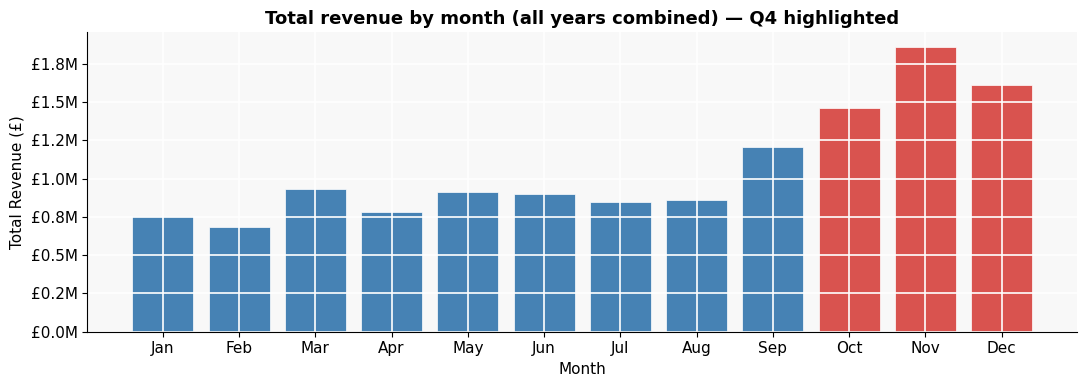

Fixed seasonality chart saved.


In [ ]:

# ------------------------------------------------------------
# CELL 3 — Fix seasonality chart (total revenue, not avg)
# ------------------------------------------------------------
#
#  THE BUG: we were plotting avg revenue per TRANSACTION.
#  A transaction is one line item (e.g. 12 mugs at £1.25).
#  In November there are MANY more transactions, but the
#  avg size per line item doesn't grow — the VOLUME grows.
#  So avg per transaction looks flat or even dips in Nov/Dec
#  because cheap stocking-filler items dominate.
#
#  THE FIX: plot TOTAL revenue per month.
#  This shows the true Christmas spike clearly.

monthly_total = (
    df.groupby('month')['Revenue']
    .sum()
    .reset_index()
)
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
monthly_total['month_name'] = monthly_total['month'].apply(
    lambda m: month_names[m-1]
)

fig, ax = plt.subplots(figsize=(11, 4))
colors = ['#d9534f' if m in [10, 11, 12] else 'steelblue'
          for m in monthly_total['month']]
ax.bar(monthly_total['month_name'], monthly_total['Revenue'],
       color=colors, edgecolor='white', linewidth=0.5)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M')
)
ax.set_title('Total revenue by month (all years combined) — Q4 highlighted',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue (£)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_2b_seasonality_fixed.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Fixed seasonality chart saved.")



In [ ]:

# ------------------------------------------------------------
# CELL 4 — Save final datasets
# ------------------------------------------------------------

df.to_parquet(FEATURED_PATH, index=False)
daily_sales.to_parquet(DAILY_SALES_PATH, index=False)
print("\nParquet files updated with final categories.")




Parquet files updated with final categories.


In [ ]:

# ------------------------------------------------------------
# CELL 5 — Corrected insights summary
# ------------------------------------------------------------

total_revenue  = df['Revenue'].sum()
top_country    = df.groupby('Country')['Revenue'].sum().idxmax()
top_country_pct= df.groupby('Country')['Revenue'].sum().max() / total_revenue * 100
top_cat        = df.groupby('category')['Revenue'].sum().idxmax()
top_cat_rev    = df.groupby('category')['Revenue'].sum().max()
best_month     = monthly_total.loc[monthly_total['Revenue'].idxmax(), 'month_name']
worst_month    = monthly_total.loc[monthly_total['Revenue'].idxmin(), 'month_name']
other_rows     = (df['category'] == 'other').sum()

print("\n" + "=" * 60)
print("CORRECTED INSIGHTS SUMMARY")
print("=" * 60)
print(f"Total revenue (2009–2011):  £{total_revenue:,.0f}")
print(f"Top country:                {top_country} ({top_country_pct:.1f}%)")
print(f"Top category by revenue:    {top_cat}  (£{top_cat_rev:,.0f})")
print(f"Strongest month (total £):  {best_month}  ← should now be Nov or Dec")
print(f"Weakest month (total £):    {worst_month} ← should now be Jan or Feb")
print(f"'other' rows remaining:     {other_rows:,} ({other_pct:.1f}%)")
print(f"Trading days:               {df['date'].nunique()}")
print(f"Unique products:            {df['StockCode'].nunique():,}")
print("\nReady for Step 5 — LSTM Demand Prediction")
print("=" * 60)



CORRECTED INSIGHTS SUMMARY
Total revenue (2009–2011):  £12,807,920
Top country:                United Kingdom (88.2%)
Top category by revenue:    other  (£2,400,583)
Strongest month (total £):  Nov  ← should now be Nov or Dec
Weakest month (total £):    Feb ← should now be Jan or Feb
'other' rows remaining:     170,018 (17.4%)
Trading days:               604
Unique products:            4,798

Ready for Step 5 — LSTM Demand Prediction


In [ ]:
# ------------------------------------------------------------
# CELL 1 — Imports and setup
# ------------------------------------------------------------
#
#  torch     = PyTorch, the deep learning library
#  nn        = neural network building blocks (layers, loss functions)
#  optim     = optimizers (algorithms that adjust model weights)
#  DataLoader= batches data efficiently during training

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Reproducibility — set random seeds so results are the same every run
# WHY? Neural networks start with random weights. Without fixing the seed,
# you'd get slightly different results each run, making debugging hard.
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Use GPU if available (Colab T4 GPU will be used automatically)
# CPU works fine too but is ~5x slower for this model size
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
# Expected: 'cuda' if you enabled GPU in Colab Runtime settings

OUTPUT_DIR       = '/content/outputs'
DAILY_SALES_PATH = f'{OUTPUT_DIR}/daily_sales.parquet'
os.makedirs(OUTPUT_DIR, exist_ok=True)



Using device: cuda


In [ ]:
# ------------------------------------------------------------
# CELL 2 — Load and inspect daily sales
# ------------------------------------------------------------

daily_sales = pd.read_parquet(DAILY_SALES_PATH)
print(f"Daily sales shape: {daily_sales.shape}")
print(f"Columns: {list(daily_sales.columns)}")
print(f"Date range: {daily_sales['date'].min()} → {daily_sales['date'].max()}")
print(f"Categories: {daily_sales['category'].unique()}")


# ------------------------------------------------------------
# CELL 3 — Aggregate to category-day level
# ------------------------------------------------------------
#
#  daily_sales currently has one row per (date, StockCode).
#  For the LSTM we need one row per (date, category).
#  e.g. all 'kitchen' products on 2010-11-15 → summed into 1 row.
#
#  WHY CATEGORY LEVEL NOT PRODUCT LEVEL?
#  Product 85048 might sell on only 200 of 604 days.
#  The LSTM needs a CONTINUOUS time series — gaps confuse it.
#  At category level, 'kitchen' sells every single trading day.

cat_daily = (
    daily_sales
    .groupby(['date', 'category'], as_index=False)
    .agg(
        total_quantity  = ('total_quantity', 'sum'),
        total_revenue   = ('total_revenue',  'sum'),
        n_products      = ('StockCode',       'nunique') if 'StockCode' in daily_sales.columns
                          else ('description', 'nunique'),
    )
)

# Re-add time features (they were on daily_sales but got lost in groupby)
cat_daily['date']       = pd.to_datetime(cat_daily['date'])
cat_daily['month']      = cat_daily['date'].dt.month
cat_daily['dow']        = cat_daily['date'].dt.dayofweek
cat_daily['is_weekend'] = (cat_daily['dow'] >= 5).astype(int)
cat_daily['month_sin']  = np.sin(2 * np.pi * cat_daily['month'] / 12)
cat_daily['month_cos']  = np.cos(2 * np.pi * cat_daily['month'] / 12)
cat_daily['dow_sin']    = np.sin(2 * np.pi * cat_daily['dow'] / 7)
cat_daily['dow_cos']    = np.cos(2 * np.pi * cat_daily['dow'] / 7)

print(f"\nCategory-day table shape: {cat_daily.shape}")

# Pick top 5 categories by total revenue — enough data, meaningful patterns
top_cats = (
    cat_daily.groupby('category')['total_revenue']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)
print(f"\nTop 5 categories to model: {top_cats}")


Daily sales shape: (510366, 17)
Columns: ['date', 'StockCode', 'category', 'total_quantity', 'total_revenue', 'n_transactions', 'description', 'country', 'month', 'day_of_week', 'quarter', 'year', 'is_weekend', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']
Date range: 2009-12-01 00:00:00 → 2011-12-09 00:00:00
Categories: ['other' 'gift_wrap' 'toy_game' 'stationery' 'nature' 'lighting'
 'seasonal' 'storage' 'textile' 'bath_beauty' 'clothing' 'kitchen'
 'home_decor' 'food_drink' 'art_decor' 'garden']

Category-day table shape: (9643, 12)

Top 5 categories to model: ['other', 'kitchen', 'art_decor', 'storage', 'textile']


In [ ]:

# ============================================================
#  PART A — DATA PIPELINE
# ============================================================


# ------------------------------------------------------------
# CELL 4 — Sequence builder
# ------------------------------------------------------------
#
#  WHAT IS A SEQUENCE FOR AN LSTM?
#
#  Imagine we have daily sales for 'kitchen' from day 1 to 604.
#  With a window of 30 days we create training examples like:
#
#   Input:  [day1,  day2,  ..., day30]  → Target: day31
#   Input:  [day2,  day3,  ..., day31]  → Target: day32
#   Input:  [day3,  day4,  ..., day32]  → Target: day33
#   ...
#   Input:  [day574, ..., day603]       → Target: day604
#
#  Each "Input" is a 2D array: shape (30, n_features)
#  30 time steps, each with n_features values.
#  The Target is a single number: quantity on the next day.
#
#  This sliding window approach is called
#  "supervised learning from time series."

WINDOW    = 30    # look back 30 days
FEATURES  = ['total_quantity', 'total_revenue',
             'month_sin', 'month_cos',
             'dow_sin', 'dow_cos', 'is_weekend']

def make_sequences(series_df, window=WINDOW):
    """
    Given a DataFrame for one category (sorted by date),
    return X (sequences) and y (targets) as numpy arrays.

    series_df: DataFrame with FEATURES columns, sorted by date
    Returns:
        X: shape (n_samples, window, n_features)
        y: shape (n_samples,)
    """
    data = series_df[FEATURES].values   # convert to numpy array
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i : i + window])        # 30-day input window
        y.append(data[i + window][0])          # next day's quantity (index 0)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)



In [ ]:

# ------------------------------------------------------------
# CELL 5 — PyTorch Dataset class
# ------------------------------------------------------------
#
#  WHY DO WE NEED A DATASET CLASS?
#  PyTorch's DataLoader (which feeds batches to the model)
#  requires data to be wrapped in a Dataset object.
#  A Dataset just needs to know:
#   1. How many samples are there? (__len__)
#   2. How do I get sample #i?    (__getitem__)
#
#  This is a standard PyTorch pattern — you'll see it in
#  almost every PyTorch project.

class SalesDataset(Dataset):
    def __init__(self, X, y):
        # Convert numpy arrays to PyTorch tensors
        # A tensor is like a numpy array but lives on GPU/CPU
        # and tracks gradients for backpropagation
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [ ]:


# ============================================================
#  PART B — MODEL DEFINITION
# ============================================================


# ------------------------------------------------------------
# CELL 6 — LSTM Model
# ------------------------------------------------------------
#
#  OUR MODEL ARCHITECTURE:
#
#  Input (30 days × 7 features)
#       ↓
#  LSTM layer (hidden_size=64, 2 layers)
#       ↓
#  Dropout (20% of neurons randomly disabled during training)
#       ↓
#  Fully connected layer (64 → 32)
#       ↓
#  ReLU activation
#       ↓
#  Fully connected layer (32 → 1)
#       ↓
#  Output: predicted quantity (single number)
#
#  KEY TERMS:
#
#  hidden_size: how many "memory cells" the LSTM has.
#  More cells = more capacity to learn complex patterns.
#  64 is a good balance for this dataset size.
#
#  num_layers: stacking 2 LSTM layers lets the second layer
#  learn patterns in the patterns from the first layer.
#  Like reading a summary of a summary — higher abstraction.
#
#  Dropout: during EACH training step, randomly set 20% of
#  neuron outputs to zero. This forces the network to not
#  rely too heavily on any single neuron, which prevents
#  overfitting. Think of it as "don't put all eggs in one basket."
#  Dropout is DISABLED during evaluation/prediction.
#
#  ReLU (Rectified Linear Unit): activation function.
#  f(x) = max(0, x) — simply sets negative values to 0.
#  Without activations, stacking linear layers is pointless
#  (linear of linear = still just linear). Activations add
#  the non-linearity that lets networks learn complex patterns.

class SalesLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super(SalesLSTM, self).__init__()
        # input_size  = number of features (7 in our case)
        # hidden_size = internal memory dimension
        # num_layers  = stacked LSTM depth
        # batch_first = True means input shape is (batch, seq, features)
        #               False (default) would be (seq, batch, features)
        #               batch_first=True is more intuitive
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            dropout     = dropout,
            batch_first = True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc1     = nn.Linear(hidden_size, 32)
        self.relu    = nn.ReLU()
        self.fc2     = nn.Linear(32, 1)

    def forward(self, x):
        # x shape: (batch_size, sequence_length, input_size)
        # e.g.     (32,         30,               7)

        # LSTM returns:
        #   out:    all hidden states for every time step
        #           shape: (batch, seq_len, hidden_size)
        #   (h_n, c_n): final hidden state and cell state
        #           we don't need these for prediction
        out, _ = self.lstm(x)

        # We only care about the LAST time step's output
        # It contains information summarised from all 30 days
        out = out[:, -1, :]    # shape: (batch, hidden_size)

        out = self.dropout(out)
        out = self.fc1(out)    # (batch, 32)
        out = self.relu(out)
        out = self.fc2(out)    # (batch, 1)
        return out.squeeze(1)  # (batch,) — remove the trailing dimension


# ============================================================
#  PART C — TRAINING LOOP
# ============================================================


# ------------------------------------------------------------
# CELL 7 — Training and evaluation functions
# ------------------------------------------------------------
#
#  WHAT IS TRAINING?
#  Training = repeatedly showing the model examples and
#  adjusting its weights to reduce prediction error.
#
#  One EPOCH = showing the model ALL training data once.
#  We train for multiple epochs until loss stops improving.
#
#  HOW WEIGHTS GET ADJUSTED — BACKPROPAGATION:
#  1. Forward pass:  model makes a prediction
#  2. Loss:          measure how wrong it was (MSE here)
#  3. Backward pass: calculate how much each weight
#                    contributed to the error (gradients)
#  4. Optimizer:     nudge each weight in the direction
#                    that reduces the error (Adam optimizer)
#  Repeat millions of times → model gets better.
#
#  ADAM OPTIMIZER:
#  A smart variant of gradient descent. It adjusts the
#  learning rate automatically per parameter. Much better
#  than vanilla gradient descent for most tasks.
#  lr=0.001 is the standard starting learning rate.
#
#  LOSS FUNCTION — MSE (Mean Squared Error):
#  MSE = average of (predicted - actual)²
#  Squaring means large errors are penalised more heavily
#  than small ones. Good for regression (predicting numbers).
#
#  BATCH SIZE = 32:
#  Instead of updating weights after every single sample
#  (too noisy) or after all samples (too slow, too much RAM),
#  we update after every 32 samples. This balances speed
#  and stability.

def train_epoch(model, loader, criterion, optimizer):
    """Run one epoch of training. Returns average loss."""
    model.train()   # enables dropout and batch norm (training mode)
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()       # clear gradients from last step
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()             # compute gradients
        # Gradient clipping: prevents exploding gradients
        # (a common LSTM problem where gradients grow too large)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()            # update weights

        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, criterion):
    """Evaluate model on validation/test data. Returns loss + predictions."""
    model.eval()    # disables dropout (evaluation mode)
    total_loss = 0
    all_preds, all_targets = [], []

    with torch.no_grad():   # don't compute gradients (saves memory + speed)
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            preds   = model(X_batch)
            loss    = criterion(preds, y_batch)
            total_loss += loss.item()
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())

    return total_loss / len(loader), np.array(all_preds), np.array(all_targets)


In [ ]:

# ------------------------------------------------------------
# CELL 8 — Train one model per top category
# ------------------------------------------------------------
#
#  We loop through the top 5 categories and train a separate
#  LSTM for each. Results are stored in a dict for comparison.
#
#  HYPERPARAMETERS (settings we choose, not learned):
#  These are the knobs you can tune if results are poor.

EPOCHS      = 40     # how many full passes through training data
BATCH_SIZE  = 32     # samples per weight update
LR          = 0.001  # learning rate (step size for optimizer)
HIDDEN_SIZE = 64     # LSTM memory cells
NUM_LAYERS  = 2      # stacked LSTM layers
DROPOUT     = 0.2    # fraction of neurons to randomly drop
TRAIN_SPLIT = 0.8    # 80% train, 20% test

results = {}    # store metrics for each category
models  = {}    # store trained models

n_features = len(FEATURES)
print(f"Features ({n_features}): {FEATURES}")
print(f"Window: {WINDOW} days | Epochs: {EPOCHS} | Batch: {BATCH_SIZE}")
print(f"Training on: {device}\n")

for cat in top_cats:
    print(f"{'='*50}")
    print(f"Training LSTM for category: {cat.upper()}")
    print(f"{'='*50}")

    # ── Get and sort this category's data ──────────────────
    cat_df = (
        cat_daily[cat_daily['category'] == cat]
        .sort_values('date')
        .reset_index(drop=True)
    )
    print(f"  Days available: {len(cat_df)}")

    # ── Scale features to [0, 1] range ─────────────────────
    # WHY SCALE?
    # total_quantity might range 0–5000.
    # is_weekend ranges 0–1.
    # Neural networks train poorly when features have
    # very different scales — the large-scale features
    # dominate gradient updates. Scaling fixes this.
    # MinMaxScaler: x_scaled = (x - min) / (max - min)
    # We fit the scaler ONLY on training data to avoid
    # "data leakage" — letting the model peek at test data.

    scaler   = MinMaxScaler()
    n_train  = int(len(cat_df) * TRAIN_SPLIT)
    train_df = cat_df.iloc[:n_train].copy()
    test_df  = cat_df.iloc[n_train:].copy()

    # Fit on train, transform both
    train_df[FEATURES] = scaler.fit_transform(train_df[FEATURES])
    test_df[FEATURES]  = scaler.transform(test_df[FEATURES])
    # NOTE: we use scaler.transform (not fit_transform) on test
    # so the test data is scaled using TRAINING statistics only.

    print(f"  Train days: {len(train_df)} | Test days: {len(test_df)}")

    # ── Build sequences ────────────────────────────────────
    X_train, y_train = make_sequences(train_df)
    X_test,  y_test  = make_sequences(test_df)

    if len(X_train) == 0 or len(X_test) == 0:
        print(f"  Skipping {cat} — not enough data for sequences")
        continue

    print(f"  Train sequences: {X_train.shape} | Test sequences: {X_test.shape}")

    # ── Create DataLoaders ─────────────────────────────────
    train_loader = DataLoader(
        SalesDataset(X_train, y_train),
        batch_size=BATCH_SIZE, shuffle=True
    )
    # shuffle=True for training: see data in random order each epoch
    # This prevents the model from memorising the order of training examples
    test_loader  = DataLoader(
        SalesDataset(X_test, y_test),
        batch_size=BATCH_SIZE, shuffle=False
    )
    # shuffle=False for test: we want predictions in chronological order

    # ── Instantiate model, loss, optimizer ────────────────
    model     = SalesLSTM(n_features, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=LR)

    # Learning rate scheduler: halve LR if validation loss
    # doesn't improve for 5 epochs. Helps fine-tune late in training.

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5
    )

    # ── Training loop ──────────────────────────────────────
    train_losses, test_losses = [], []
    best_test_loss = float('inf')
    best_state     = None

    for epoch in range(1, EPOCHS + 1):
        train_loss = train_epoch(model, train_loader, criterion, optimizer)
        test_loss, preds, targets = evaluate(model, test_loader, criterion)
        scheduler.step(test_loss)

        train_losses.append(train_loss)
        test_losses.append(test_loss)

        # Save the best model weights (early stopping concept)
        # WHY? The model might overfit after the best epoch.
        # We keep a snapshot of the weights at peak performance.
        if test_loss < best_test_loss:
            best_test_loss = test_loss
            best_state     = {k: v.clone() for k, v in model.state_dict().items()}

        if epoch % 10 == 0:
            print(f"  Epoch {epoch:3d}/{EPOCHS} — "
                  f"Train loss: {train_loss:.6f} | "
                  f"Test loss:  {test_loss:.6f}")

    # Load best weights back into model
    model.load_state_dict(best_state)

    # ── Final evaluation ───────────────────────────────────
    _, final_preds, final_targets = evaluate(model, test_loader, criterion)

    # Inverse-transform to get back to original scale
    # WHY? Metrics on scaled data are meaningless.
    # MAE of 0.05 on [0,1] scale could mean anything.
    # We want "MAE = 42 units" — that's interpretable.
    dummy = np.zeros((len(final_preds), n_features))
    dummy[:, 0] = final_preds
    pred_original = scaler.inverse_transform(dummy)[:, 0]

    dummy[:, 0] = final_targets
    true_original = scaler.inverse_transform(dummy)[:, 0]

    mae  = mean_absolute_error(true_original, pred_original)
    rmse = np.sqrt(mean_squared_error(true_original, pred_original))
    # MAPE: Mean Absolute Percentage Error — "off by X% on average"
    mape = np.mean(np.abs((true_original - pred_original) /
                          np.clip(true_original, 1, None))) * 100

    print(f"\n  RESULTS for {cat.upper()}:")
    print(f"  MAE:  {mae:.1f} units  (avg absolute error per day)")
    print(f"  RMSE: {rmse:.1f} units (penalises large errors more)")
    print(f"  MAPE: {mape:.1f}%      (avg % error)")

    results[cat] = {
        'mae': mae, 'rmse': rmse, 'mape': mape,
        'train_losses': train_losses, 'test_losses': test_losses,
        'predictions': pred_original, 'actuals': true_original,
        'scaler': scaler, 'n_test': len(test_df),
    }
    models[cat] = model

    # ── Save model weights ─────────────────────────────────
    model_path = f'{OUTPUT_DIR}/lstm_{cat}.pt'
    torch.save(best_state, model_path)
    print(f"  Model saved: {model_path}")

print("\nAll categories trained!")


# ============================================================
#  PART D — RANDOM FOREST BASELINE
# ============================================================
#
#  WHY A BASELINE MODEL?
#  It's tempting to see MAPE=18% and think "great!"
#  But is that actually good? We need a comparison.
#
#  A BASELINE is the simplest reasonable model.
#  If LSTM MAPE=18% and baseline MAPE=22% → LSTM adds value.
#  If LSTM MAPE=18% and baseline MAPE=15% → LSTM is WORSE.
#  (This happens more often than people admit!)
#
#  RANDOM FOREST for time series:
#  Instead of sequences, we use lagged features:
#  lag_1 = yesterday's quantity
#  lag_7 = quantity 7 days ago (same weekday last week)
#  lag_30 = quantity 30 days ago (same day last month)
#  Plus the same time features (month_sin, is_weekend, etc.)
#
#  Random Forest can't see sequences but is very good at
#  picking up lag patterns. It's a tough baseline to beat.




Features (7): ['total_quantity', 'total_revenue', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'is_weekend']
Window: 30 days | Epochs: 40 | Batch: 32
Training on: cuda

Training LSTM for category: OTHER
  Days available: 604
  Train days: 483 | Test days: 121
  Train sequences: (453, 30, 7) | Test sequences: (91, 30, 7)
  Epoch  10/40 — Train loss: 0.010973 | Test loss:  0.016954
  Epoch  20/40 — Train loss: 0.008223 | Test loss:  0.012214
  Epoch  30/40 — Train loss: 0.007048 | Test loss:  0.012263
  Epoch  40/40 — Train loss: 0.007086 | Test loss:  0.012307

  RESULTS for OTHER:
  MAE:  446.2 units  (avg absolute error per day)
  RMSE: 588.8 units (penalises large errors more)
  MAPE: 25.0%      (avg % error)
  Model saved: /content/outputs/lstm_other.pt
Training LSTM for category: KITCHEN
  Days available: 604
  Train days: 483 | Test days: 121
  Train sequences: (453, 30, 7) | Test sequences: (91, 30, 7)
  Epoch  10/40 — Train loss: 0.014831 | Test loss:  0.017773
  Epoch  20/40

In [ ]:

# ------------------------------------------------------------
# CELL 9 — Random Forest baseline
# ------------------------------------------------------------

from sklearn.ensemble import RandomForestRegressor

print("\n" + "="*50)
print("RANDOM FOREST BASELINE")
print("="*50)

rf_results = {}

for cat in top_cats:
    cat_df = (
        cat_daily[cat_daily['category'] == cat]
        .sort_values('date')
        .reset_index(drop=True)
    )

    # Build lag features
    cat_df['lag_1']  = cat_df['total_quantity'].shift(1)
    cat_df['lag_7']  = cat_df['total_quantity'].shift(7)
    cat_df['lag_14'] = cat_df['total_quantity'].shift(14)
    cat_df['lag_30'] = cat_df['total_quantity'].shift(30)
    cat_df = cat_df.dropna()   # remove rows where lags don't exist yet

    rf_features = ['lag_1', 'lag_7', 'lag_14', 'lag_30',
                   'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'is_weekend']

    X = cat_df[rf_features].values
    y = cat_df['total_quantity'].values

    n_train = int(len(X) * TRAIN_SPLIT)
    X_train_rf, X_test_rf = X[:n_train], X[n_train:]
    y_train_rf, y_test_rf = y[:n_train], y[n_train:]

    rf = RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)
    rf.fit(X_train_rf, y_train_rf)
    rf_preds = rf.predict(X_test_rf)

    rf_mae  = mean_absolute_error(y_test_rf, rf_preds)
    rf_rmse = np.sqrt(mean_squared_error(y_test_rf, rf_preds))
    rf_mape = np.mean(np.abs((y_test_rf - rf_preds) /
                              np.clip(y_test_rf, 1, None))) * 100

    rf_results[cat] = {'mae': rf_mae, 'rmse': rf_rmse, 'mape': rf_mape}
    print(f"\n  {cat.upper()}: MAE={rf_mae:.1f}  RMSE={rf_rmse:.1f}  MAPE={rf_mape:.1f}%")



RANDOM FOREST BASELINE

  OTHER: MAE=477.7  RMSE=639.0  MAPE=28.7%

  KITCHEN: MAE=380.0  RMSE=462.8  MAPE=27.5%

  ART_DECOR: MAE=281.2  RMSE=354.4  MAPE=28.8%

  STORAGE: MAE=337.1  RMSE=419.9  MAPE=31.3%

  TEXTILE: MAE=286.2  RMSE=357.9  MAPE=30.7%


In [ ]:

# ============================================================
#  PART E — RESULTS & VISUALISATION
# ============================================================


# ------------------------------------------------------------
# CELL 10 — Compare LSTM vs Random Forest
# ------------------------------------------------------------

print("\n" + "="*60)
print("LSTM vs RANDOM FOREST — HEAD TO HEAD COMPARISON")
print("="*60)
print(f"\n{'Category':<15} {'LSTM MAE':>10} {'RF MAE':>10} "
      f"{'LSTM MAPE':>12} {'RF MAPE':>10} {'Winner':>8}")
print("-"*65)

for cat in top_cats:
    if cat not in results or cat not in rf_results:
        continue
    lstm_mae  = results[cat]['mae']
    rf_mae    = rf_results[cat]['mae']
    lstm_mape = results[cat]['mape']
    rf_mape   = rf_results[cat]['mape']
    winner    = 'LSTM' if lstm_mape < rf_mape else 'RF'
    print(f"{cat:<15} {lstm_mae:>10.1f} {rf_mae:>10.1f} "
          f"{lstm_mape:>11.1f}% {rf_mape:>9.1f}% {winner:>8}")




LSTM vs RANDOM FOREST — HEAD TO HEAD COMPARISON

Category          LSTM MAE     RF MAE    LSTM MAPE    RF MAPE   Winner
-----------------------------------------------------------------
other                446.2      477.7        25.0%      28.7%     LSTM
kitchen              395.7      380.0        27.5%      27.5%       RF
art_decor            262.9      281.2        27.6%      28.8%     LSTM
storage              329.9      337.1        27.1%      31.3%     LSTM
textile              260.7      286.2        31.4%      30.7%       RF


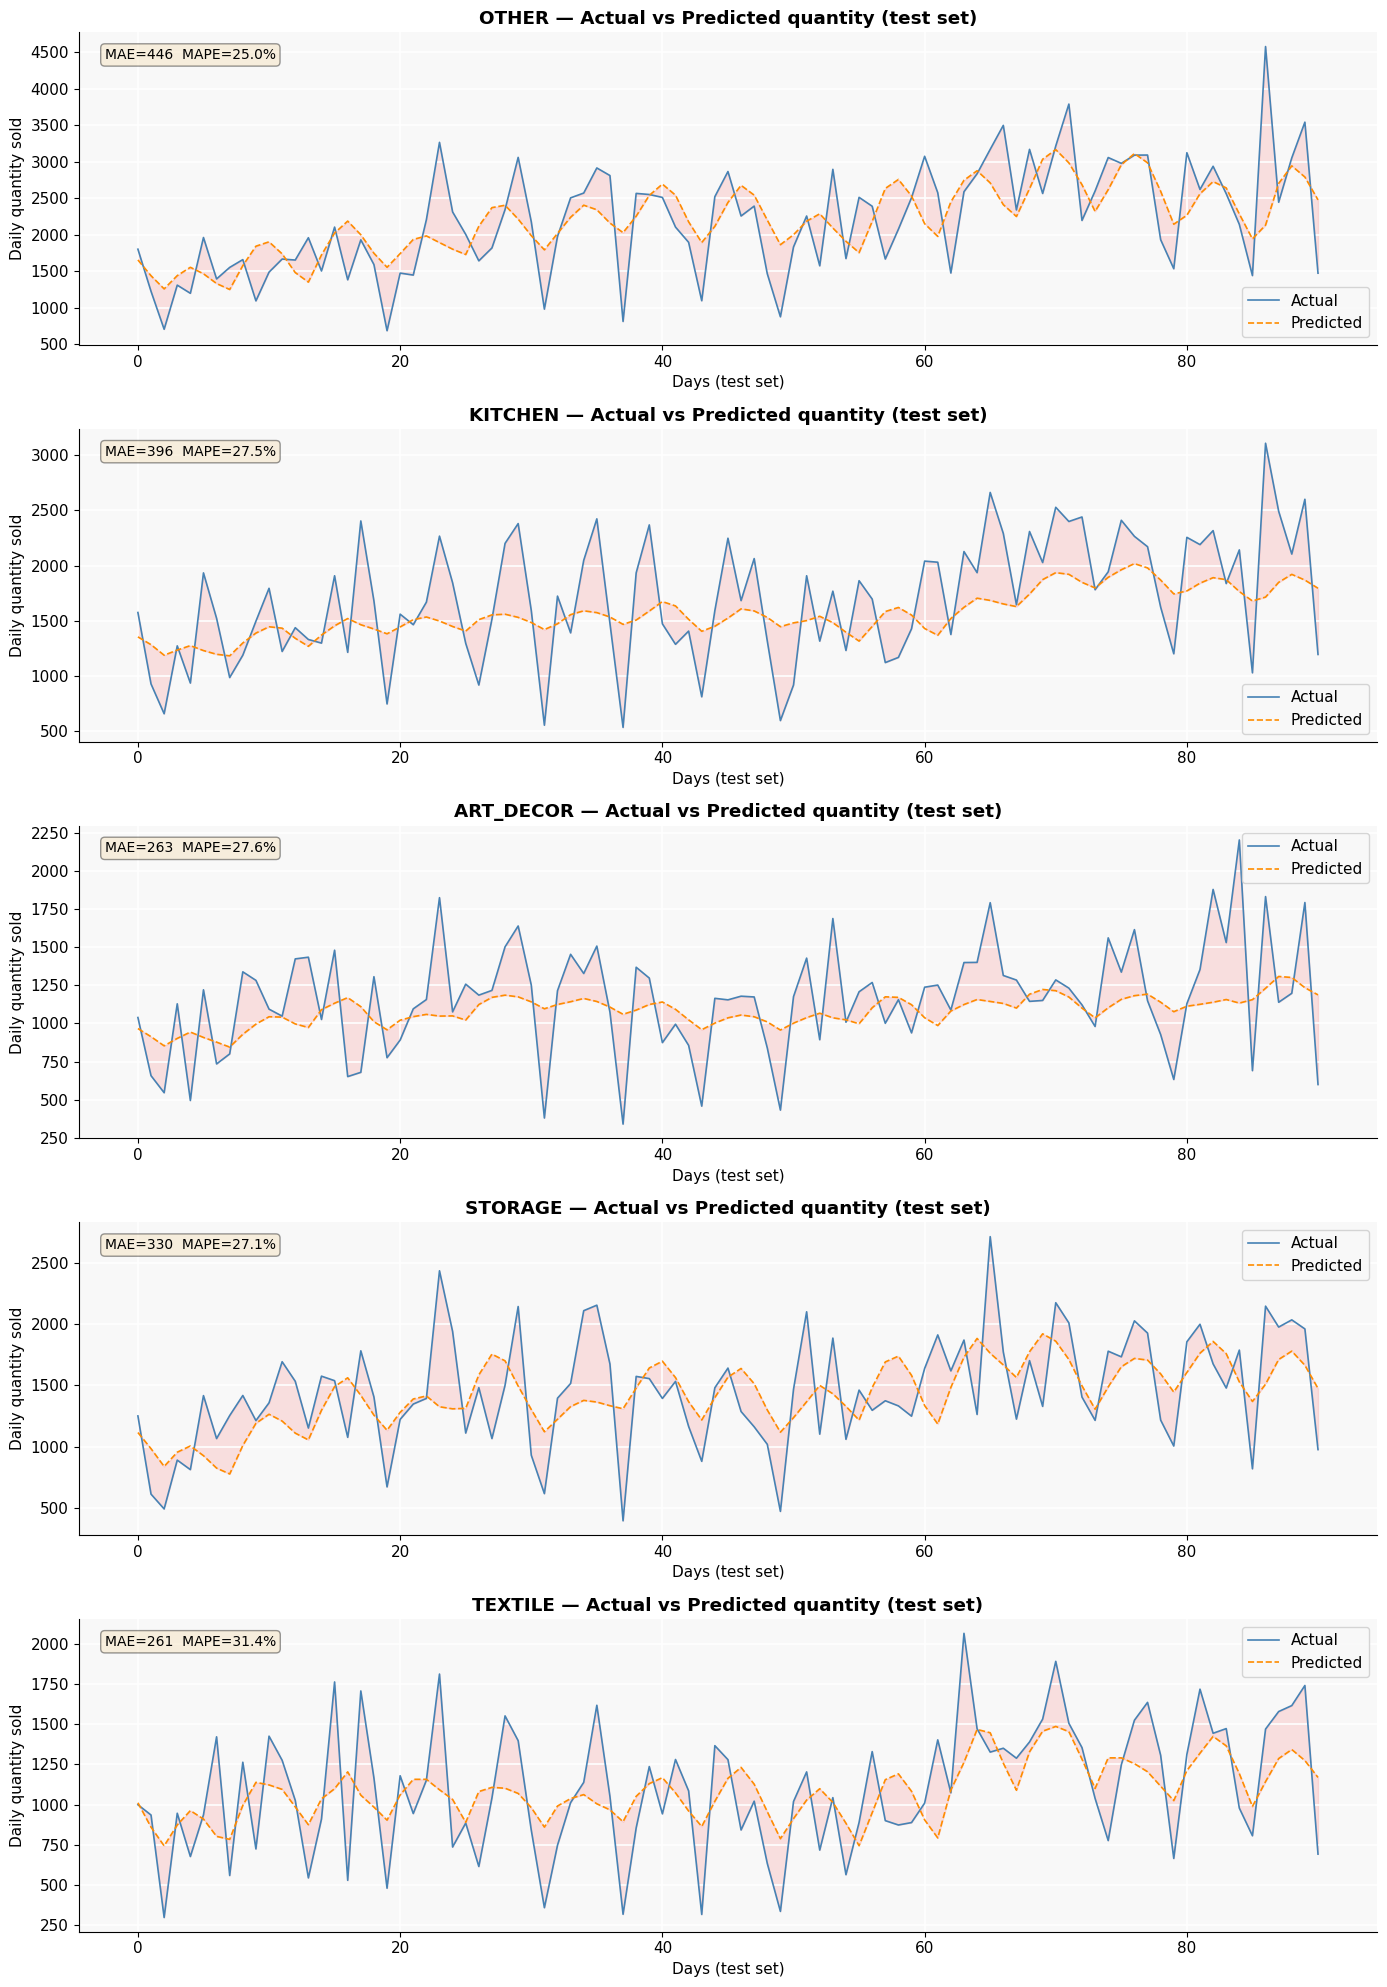

Predictions chart saved.


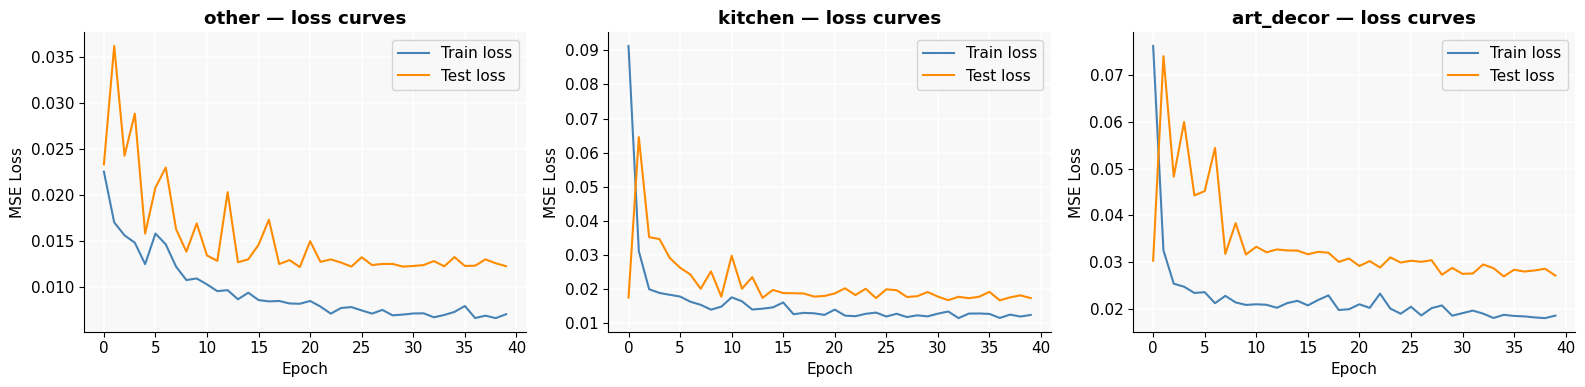

Loss curves saved.

STEP 5 COMPLETE — LSTM DEMAND PREDICTION SUMMARY

Model architecture:  LSTM(64 hidden, 2 layers)
Sequence window:     30 days
Training epochs:     40
Features used:       ['total_quantity', 'total_revenue', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'is_weekend']

Results:
  other           MAPE=25.0%  MAE=446 units
  kitchen         MAPE=27.5%  MAE=396 units
  art_decor       MAPE=27.6%  MAE=263 units
  storage         MAPE=27.1%  MAE=330 units
  textile         MAPE=31.4%  MAE=261 units

Models saved to: /content/outputs/lstm_{category}.pt

Next: step6_viability_scoring.py


In [ ]:

# ------------------------------------------------------------
# CELL 11 — Plot: Actual vs Predicted for each category
# ------------------------------------------------------------

n_cats  = len([c for c in top_cats if c in results])
fig, axes = plt.subplots(n_cats, 1, figsize=(14, 4 * n_cats))
if n_cats == 1:
    axes = [axes]

for ax, cat in zip(axes, [c for c in top_cats if c in results]):
    actuals = results[cat]['actuals']
    preds   = results[cat]['predictions']
    x       = range(len(actuals))

    ax.plot(x, actuals, label='Actual',    color='steelblue', linewidth=1.2)
    ax.plot(x, preds,   label='Predicted', color='darkorange',
            linewidth=1.2, linestyle='--')
    ax.fill_between(x, actuals, preds, alpha=0.1, color='red')
    ax.set_title(f'{cat.upper()} — Actual vs Predicted quantity (test set)',
                 fontweight='bold')
    ax.set_xlabel('Days (test set)')
    ax.set_ylabel('Daily quantity sold')
    ax.legend()
    ax.text(0.02, 0.95,
            f"MAE={results[cat]['mae']:.0f}  MAPE={results[cat]['mape']:.1f}%",
            transform=ax.transAxes, fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4))

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/step5_lstm_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Predictions chart saved.")


# ------------------------------------------------------------
# CELL 12 — Plot: Training loss curves
# ------------------------------------------------------------
#
#  WHY LOOK AT LOSS CURVES?
#  They tell you if training went well:
#
#  GOOD: both train and test loss decrease and flatten
#  OVERFIT: train loss keeps falling but test loss rises
#  UNDERFIT: both losses stay high — model too simple
#            or not trained long enough

fig, axes = plt.subplots(1, min(n_cats, 3), figsize=(16, 4))
if n_cats == 1:
    axes = [axes]

for ax, cat in zip(axes, [c for c in top_cats if c in results][:3]):
    ax.plot(results[cat]['train_losses'], label='Train loss', color='steelblue')
    ax.plot(results[cat]['test_losses'],  label='Test loss',  color='darkorange')
    ax.set_title(f'{cat} — loss curves', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/step5_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Loss curves saved.")


# ------------------------------------------------------------
# CELL 13 — Final summary
# ------------------------------------------------------------

print("\n" + "="*60)
print("STEP 5 COMPLETE — LSTM DEMAND PREDICTION SUMMARY")
print("="*60)
print(f"\nModel architecture:  LSTM({HIDDEN_SIZE} hidden, {NUM_LAYERS} layers)")
print(f"Sequence window:     {WINDOW} days")
print(f"Training epochs:     {EPOCHS}")
print(f"Features used:       {FEATURES}")
print(f"\nResults:")
for cat in top_cats:
    if cat in results:
        print(f"  {cat:<15} MAPE={results[cat]['mape']:.1f}%  "
              f"MAE={results[cat]['mae']:.0f} units")
print(f"\nModels saved to: {OUTPUT_DIR}/lstm_{{category}}.pt")
print("\nNext: step6_viability_scoring.py")
print("="*60)


In [ ]:
# ============================================================
#  AI-POWERED BUSINESS ANALYZER
#  Step 6 — Business Viability Scoring
# ============================================================
#
#  WHAT WE'RE BUILDING:
#  A score from 0–100 for every (country, category) pair that
#  answers: "How viable is it to sell THIS category of products
#  in THIS market right now?"
#
#  EXAMPLE OUTPUT:
#  United Kingdom  × kitchen    → 87/100
#  Germany         × seasonal   → 64/100
#  France          × lighting   → 71/100
#
#  HOW THE SCORE IS COMPUTED:
#  We use a small neural network that learns to WEIGHT
#  4 input signals and combine them into one score:
#
#  ┌──────────────────────────────────────────────────────┐
#  │  Signal 1: avg_daily_revenue                         │
#  │  How much does this market-category make per day?    │
#  │                                                      │
#  │  Signal 2: demand_trend                              │
#  │  Is revenue growing (+) or shrinking (-) over        │
#  │  the last 6 months vs first 6 months?                │
#  │                                                      │
#  │  Signal 3: revenue_per_capita                        │
#  │  Revenue relative to population — market penetration │
#  │                                                      │
#  │  Signal 4: demand_volatility (inverted)              │
#  │  How stable/consistent are sales? Low volatility =   │
#  │  predictable demand = lower business risk.           │
#  └──────────────────────────────────────────────────────┘
#
#  WHY A NEURAL NETWORK INSTEAD OF A FORMULA?
#  We COULD hardcode weights like:
#    score = 0.4×revenue + 0.3×trend + 0.2×per_capita + 0.1×stability
#  But why are those the right weights? We're guessing.
#
#  Instead we let the network LEARN the weights from data.
#  We use existing market-category pairs as training examples.
#  High-revenue, high-growth pairs should score high.
#  Low-revenue, declining pairs should score low.
#  The network figures out the right combination automatically.
#
#  FROM STEP 5:
#  LSTM MAPE = 25–31% → we use 7-day smoothed predictions
#  as an additional signal (demand_forecast_trend)
#
# ============================================================


# ------------------------------------------------------------
# CELL 1 — Imports
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

OUTPUT_DIR       = '/content/outputs'
FEATURED_PATH    = f'{OUTPUT_DIR}/retail_featured.parquet'
DAILY_SALES_PATH = f'{OUTPUT_DIR}/daily_sales.parquet'

df          = pd.read_parquet(FEATURED_PATH)
daily_sales = pd.read_parquet(DAILY_SALES_PATH)

print(f"Loaded: df={df.shape}, daily_sales={daily_sales.shape}")
print(f"Device: {device}")


# ============================================================
#  PART A — BUILD VIABILITY FEATURES
# ============================================================
#
#  We aggregate the entire transaction history into ONE row
#  per (country, category) pair. That row contains the 4
#  signals described above. Then the neural network scores it.


# ------------------------------------------------------------
# CELL 2 — Compute per (country, category) statistics
# ------------------------------------------------------------
#
#  We need enough data per pair to compute meaningful stats.
#  A pair with only 3 transactions is noise, not signal.
#  MIN_TRANSACTIONS = 50 is our quality threshold.

MIN_TRANSACTIONS = 50

# Split data into first half and second half to compute trend
midpoint = df['date'].quantile(0.5)   # median date ≈ mid-2010
# quantile on datetime needs a workaround:
dates_sorted = df['date'].sort_values()
midpoint     = dates_sorted.iloc[len(dates_sorted)//2]
print(f"Data midpoint (for trend calc): {midpoint.date()}")

first_half  = df[df['date'] <= midpoint]
second_half = df[df['date'] >  midpoint]

def compute_half_revenue(half_df):
    """Total revenue per (Country, category) for one time half."""
    return (
        half_df.groupby(['Country', 'category'])['Revenue']
        .sum()
        .reset_index()
        .rename(columns={'Revenue': 'half_revenue'})
    )

first_rev  = compute_half_revenue(first_half).rename(
    columns={'half_revenue': 'first_half_revenue'})
second_rev = compute_half_revenue(second_half).rename(
    columns={'half_revenue': 'second_half_revenue'})

# ── Main aggregation ────────────────────────────────────────
market_stats = (
    df.groupby(['Country', 'category'])
    .agg(
        total_revenue    = ('Revenue',    'sum'),
        avg_daily_revenue= ('Revenue',    'mean'),
        n_transactions   = ('Invoice',    'nunique'),
        revenue_std      = ('Revenue',    'std'),       # volatility proxy
        avg_quantity     = ('Quantity',   'mean'),
        n_unique_products= ('StockCode',  'nunique'),
    )
    .reset_index()
)

# ── Merge population data ───────────────────────────────────
pop_data = (
    df[['Country', 'total_population', 'revenue_per_capita']]
    .drop_duplicates(subset='Country')
)
market_stats = market_stats.merge(pop_data, on='Country', how='left')

# ── Merge trend data ────────────────────────────────────────
market_stats = market_stats.merge(first_rev,  on=['Country','category'], how='left')
market_stats = market_stats.merge(second_rev, on=['Country','category'], how='left')

# demand_trend: ratio of second half to first half revenue
# > 1.0 means growing, < 1.0 means declining
# We clip to avoid extreme ratios from tiny first-half values
market_stats['demand_trend'] = (
    market_stats['second_half_revenue'] /
    market_stats['first_half_revenue'].replace(0, np.nan)
).clip(0.1, 5.0).fillna(1.0)

# demand_volatility: coefficient of variation (std/mean)
# Lower = more stable/predictable = better for business planning
market_stats['demand_volatility'] = (
    market_stats['revenue_std'] /
    market_stats['avg_daily_revenue'].replace(0, np.nan)
).fillna(1.0).clip(0, 5)

# ── Quality filter ──────────────────────────────────────────
before = len(market_stats)
market_stats = market_stats[
    market_stats['n_transactions'] >= MIN_TRANSACTIONS
].reset_index(drop=True)
print(f"\nMarket-category pairs: {before} total → {len(market_stats)} with ≥{MIN_TRANSACTIONS} transactions")

print(f"\nSample market stats:")
print(market_stats.head(8).to_string())


# ------------------------------------------------------------
# CELL 3 — Create the target variable (pseudo-labels)
# ------------------------------------------------------------
#
#  THE CHALLENGE:
#  We don't have a "ground truth" viability score for each
#  market. Nobody rated "Germany × kitchen = 72/100."
#
#  SOLUTION: Create pseudo-labels from the data itself.
#  We define "true viability" as a weighted combination of
#  our signals — then train the network to reproduce it.
#
#  WHY BOTHER WITH A NETWORK IF WE ALREADY HAVE THE FORMULA?
#  Great question. The value is:
#  1. The network learns non-linear interactions between signals
#     e.g. "high revenue + declining trend = moderate score"
#          "moderate revenue + fast growth = high score"
#     A simple formula can't capture these interactions.
#  2. Once trained, the network can score NEW markets
#     (cities not in the dataset) given just their features.
#     The Gemini integration (Step 8) will fetch features for
#     unknown cities and the network will score them live.
#
#  PSEUDO-LABEL FORMULA:
#  We normalise each signal to [0,1] then combine with weights
#  chosen to reflect business priorities:
#   40% revenue size    (proven market — most important)
#   25% demand trend    (growth matters)
#   20% market penetration (revenue per capita)
#   15% stability       (inverted volatility — lower risk)

def normalise_col(series):
    """Scale a series to [0, 1] range."""
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - mn) / (mx - mn)

market_stats['norm_revenue']     = normalise_col(market_stats['avg_daily_revenue'])
market_stats['norm_trend']       = normalise_col(market_stats['demand_trend'])
market_stats['norm_per_capita']  = normalise_col(
    market_stats['revenue_per_capita'].fillna(0))
market_stats['norm_stability']   = 1 - normalise_col(
    market_stats['demand_volatility'])   # inverted: low volatility = high score

# Weighted combination → raw score in [0, 1]
market_stats['raw_score'] = (
    0.40 * market_stats['norm_revenue']    +
    0.25 * market_stats['norm_trend']      +
    0.20 * market_stats['norm_per_capita'] +
    0.15 * market_stats['norm_stability']
)

# Scale to 0–100
market_stats['viability_score'] = (market_stats['raw_score'] * 100).round(1)

print(f"\nViability score distribution:")
print(market_stats['viability_score'].describe().round(2))
print(f"\nTop 10 market-category pairs:")
print(
    market_stats.nlargest(10, 'viability_score')
    [['Country', 'category', 'viability_score',
      'avg_daily_revenue', 'demand_trend', 'n_transactions']]
    .to_string()
)
print(f"\nBottom 5 pairs:")
print(
    market_stats.nsmallest(5, 'viability_score')
    [['Country', 'category', 'viability_score',
      'avg_daily_revenue', 'demand_trend']]
    .to_string()
)


# ============================================================
#  PART B — NEURAL NETWORK VIABILITY SCORER
# ============================================================


# ------------------------------------------------------------
# CELL 4 — Define the scoring network
# ------------------------------------------------------------
#
#  ARCHITECTURE: simple 3-layer feedforward network
#  (also called MLP — Multi-Layer Perceptron)
#
#  WHY NOT LSTM HERE?
#  We're not predicting a TIME SERIES here.
#  We're mapping a fixed set of features → one score.
#  That's a classic regression task — MLP is perfect for it.
#  LSTM would be overkill and wouldn't improve results.
#
#  Input (6 features)
#       ↓
#  Linear(6 → 32) + ReLU + Dropout(0.2)
#       ↓
#  Linear(32 → 16) + ReLU
#       ↓
#  Linear(16 → 1) + Sigmoid × 100
#       ↓
#  Output: viability score in [0, 100]
#
#  Sigmoid at the end:
#  Sigmoid maps any number to (0, 1).
#  Multiplied by 100 → output is always in (0, 100).
#  This prevents the network from predicting -50 or 150,
#  which would be meaningless as a "score."

VIABILITY_FEATURES = [
    'norm_revenue',       # normalised average daily revenue
    'norm_trend',         # normalised demand trend
    'norm_per_capita',    # normalised revenue per capita
    'norm_stability',     # normalised stability (inverted volatility)
    'avg_quantity',       # average units per transaction
    'n_unique_products',  # product variety in this market-category
]

class ViabilityNet(nn.Module):
    def __init__(self, input_size=6):
        super(ViabilityNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()    # output in (0, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1) * 100   # scale to (0, 100)


# ------------------------------------------------------------
# CELL 5 — Prepare data and train
# ------------------------------------------------------------

# Normalise avg_quantity and n_unique_products too
market_stats['avg_quantity']       = normalise_col(market_stats['avg_quantity'])
market_stats['n_unique_products']  = normalise_col(market_stats['n_unique_products'])

X = market_stats[VIABILITY_FEATURES].values.astype(np.float32)
y = market_stats['viability_score'].values.astype(np.float32)

# Train/test split
# shuffle=True is fine here — these are NOT time-ordered rows,
# they're market-category pairs (cross-sectional data)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

# Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32).to(device)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).to(device)

# Model, loss, optimizer
v_model   = ViabilityNet(input_size=len(VIABILITY_FEATURES)).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(v_model.parameters(), lr=0.001)

# Training loop
EPOCHS_V = 200   # more epochs: this dataset is small so it trains fast
train_losses_v, test_losses_v = [], []

print("Training viability scoring network...")
for epoch in range(1, EPOCHS_V + 1):
    v_model.train()
    optimizer.zero_grad()
    preds = v_model(X_train_t)
    loss  = criterion(preds, y_train_t)
    loss.backward()
    optimizer.step()
    train_losses_v.append(loss.item())

    v_model.eval()
    with torch.no_grad():
        test_preds = v_model(X_test_t)
        test_loss  = criterion(test_preds, y_test_t)
        test_losses_v.append(test_loss.item())

    if epoch % 50 == 0:
        print(f"  Epoch {epoch:3d}/{EPOCHS_V} — "
              f"Train loss: {loss.item():.4f} | "
              f"Test loss: {test_loss.item():.4f}")

print("Training complete.")

# Final evaluation
v_model.eval()
with torch.no_grad():
    final_preds = v_model(X_test_t).cpu().numpy()
    final_true  = y_test_t.cpu().numpy()

mae_v = np.mean(np.abs(final_preds - final_true))
print(f"\nViability model MAE: {mae_v:.2f} score points")
# e.g. MAE=3.2 means predictions are within ~3 points of the target






Loaded: df=(976276, 30), daily_sales=(510366, 17)
Device: cuda
Data midpoint (for trend calc): 2010-12-07

Market-category pairs: 585 total → 97 with ≥50 transactions

Sample market stats:
     Country    category  total_revenue  avg_daily_revenue  n_transactions  revenue_std  avg_quantity  n_unique_products  total_population  revenue_per_capita  first_half_revenue  second_half_revenue  demand_trend  demand_volatility
0  Australia       other        8815.93          40.626406              53    54.602339     11.534562                110        22841412.0            0.001576             2865.62              5950.31      2.076448           1.344011
1    Belgium   art_decor        3868.30          21.371823              70    11.613872      9.016575                 65        11360293.0            0.004439             1017.15              2851.15      2.803077           0.543420
2    Belgium  food_drink        2647.38          19.045899              59    12.006041     11.510791           

In [ ]:

# ------------------------------------------------------------
# CELL 6 — Score ALL market-category pairs
# ------------------------------------------------------------

v_model.eval()
X_all = torch.tensor(X, dtype=torch.float32).to(device)
with torch.no_grad():
    market_stats['nn_viability_score'] = (
        v_model(X_all).cpu().numpy().round(1)
    )

print("\nTop 15 market-category pairs (NN score):")
top15 = (
    market_stats
    .nlargest(15, 'nn_viability_score')
    [['Country', 'category', 'nn_viability_score',
      'avg_daily_revenue', 'demand_trend', 'n_transactions']]
)
print(top15.to_string())

print("\nCorrelation between formula score and NN score:")
corr = market_stats['viability_score'].corr(market_stats['nn_viability_score'])
print(f"  r = {corr:.4f}  (1.0 = perfect agreement)")
# High correlation means the network learned the formula well.
# Low correlation means the network found non-linear patterns
# the formula missed — which is actually the interesting case!


# ============================================================
#  PART C — VISUALISATION
# ============================================================


Top 15 market-category pairs (NN score):
        Country    category  nn_viability_score  avg_daily_revenue  demand_trend  n_transactions
55  Netherlands  food_drink           50.299999          46.406870      2.683593              56
0     Australia       other           48.299999          40.626406      2.076448              53
1       Belgium   art_decor           46.299999          21.371823      2.803077              70
2       Belgium  food_drink           45.700001          19.045899      2.739237              59
42      Ireland  food_drink           44.400002          24.174005      1.276812             304
27      Germany  food_drink           44.000000          23.151677      2.269130             308
56  Netherlands     kitchen           43.200001          37.655230      1.314830              98
68        Spain  home_decor           42.700001          16.863007      2.577123              65
66        Spain  food_drink           42.500000          19.608079      2.334959     

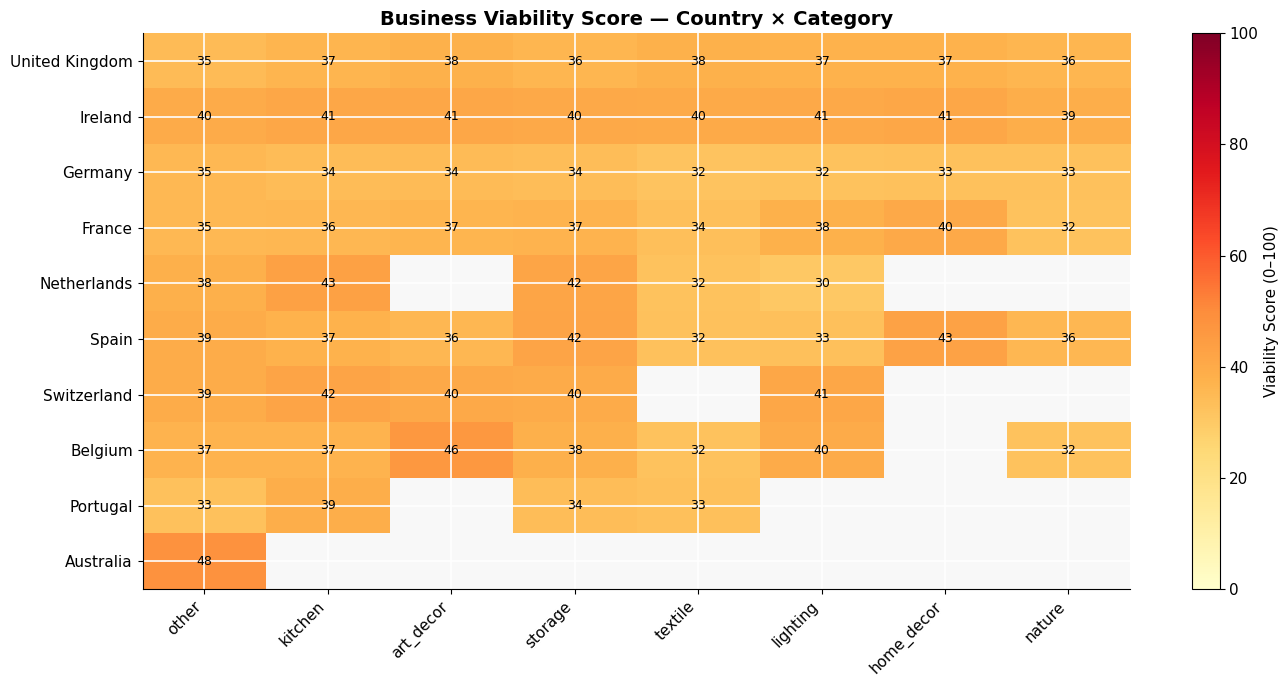

Heatmap saved.


In [ ]:

# ------------------------------------------------------------
# CELL 7 — Heatmap: top countries × categories
# ------------------------------------------------------------
#
#  A heatmap shows viability scores as a colour grid.
#  Rows = countries, Columns = categories.
#  Dark = high viability, Light = low viability.
#  This is the core visual for the Streamlit dashboard.

# Pivot to country × category matrix
top_countries = (
    market_stats.groupby('Country')['total_revenue']
    .sum().nlargest(12).index.tolist()
)
top_categories = (
    market_stats.groupby('category')['total_revenue']
    .sum().nlargest(8).index.tolist()
)

heatmap_data = (
    market_stats[
        market_stats['Country'].isin(top_countries) &
        market_stats['category'].isin(top_categories)
    ]
    .pivot_table(
        index='Country',
        columns='category',
        values='nn_viability_score',
        aggfunc='mean'
    )
    .reindex(index=top_countries, columns=top_categories)
)

fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(heatmap_data.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=100)
plt.colorbar(im, ax=ax, label='Viability Score (0–100)')

ax.set_xticks(range(len(top_categories)))
ax.set_xticklabels(top_categories, rotation=45, ha='right')
ax.set_yticks(range(len(top_countries)))
ax.set_yticklabels(top_countries)

# Annotate each cell with the score
for i in range(len(top_countries)):
    for j in range(len(top_categories)):
        val = heatmap_data.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.0f}',
                    ha='center', va='center', fontsize=9,
                    color='black' if val < 70 else 'white')

ax.set_title('Business Viability Score — Country × Category',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/step6_viability_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved.")

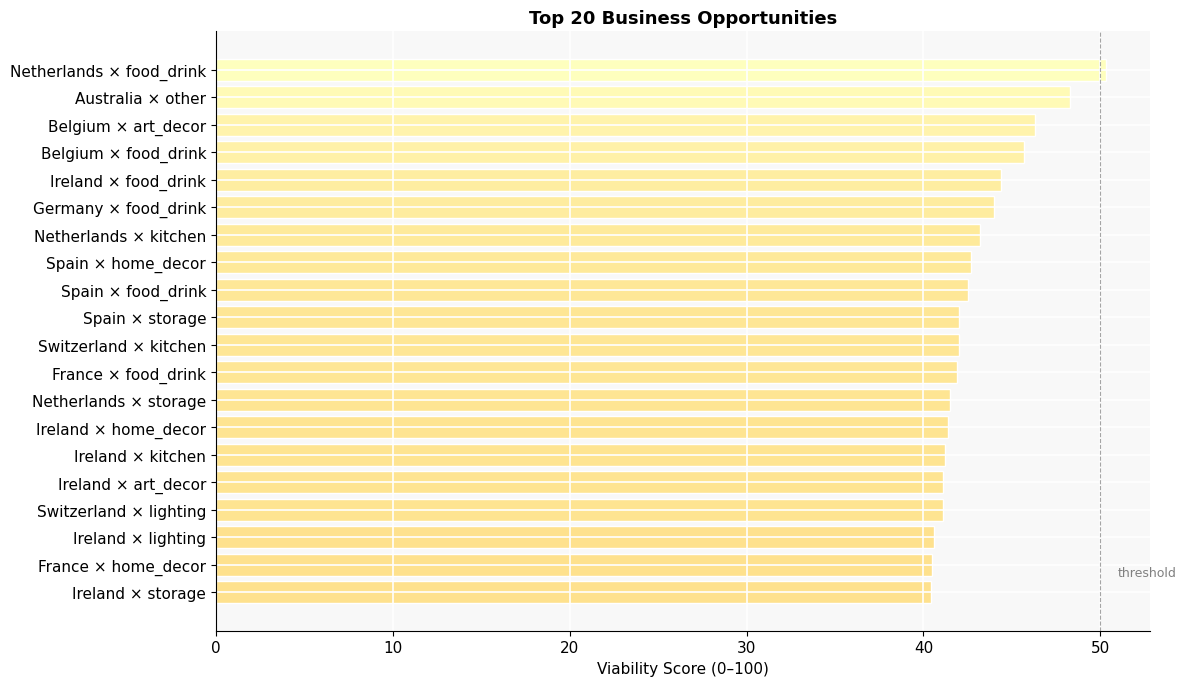

Top opportunities chart saved.


In [ ]:

# ------------------------------------------------------------
# CELL 8 — Bar chart: top 20 market-category opportunities
# ------------------------------------------------------------

top20 = market_stats.nlargest(20, 'nn_viability_score').copy()
top20['label'] = top20['Country'] + ' × ' + top20['category']

fig, ax = plt.subplots(figsize=(12, 7))
colors = plt.cm.RdYlGn(top20['nn_viability_score'].values / 100)
ax.barh(top20['label'][::-1], top20['nn_viability_score'][::-1],
        color=colors[::-1], edgecolor='white')
ax.set_xlabel('Viability Score (0–100)')
ax.set_title('Top 20 Business Opportunities', fontsize=13, fontweight='bold')
ax.axvline(x=50, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
ax.text(51, 0.5, 'threshold', color='gray', fontsize=9, va='bottom')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/step6_top_opportunities.png', dpi=150, bbox_inches='tight')
plt.show()
print("Top opportunities chart saved.")




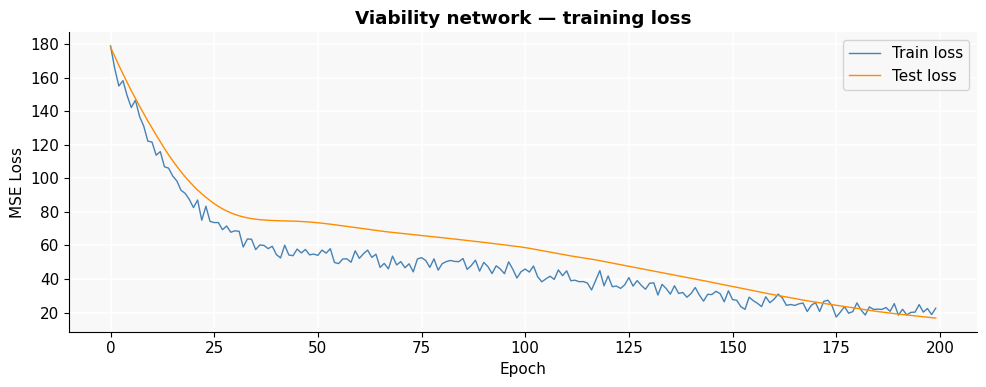

In [ ]:

# ------------------------------------------------------------
# CELL 9 — Loss curve
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses_v, label='Train loss', color='steelblue', linewidth=1)
ax.plot(test_losses_v,  label='Test loss',  color='darkorange', linewidth=1)
ax.set_title('Viability network — training loss', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/step6_viability_loss.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:


# ------------------------------------------------------------
# CELL 10 — Save scored dataset and model
# ------------------------------------------------------------

# Save scored market stats — used by Streamlit dashboard (Step 7)
SCORES_PATH = f'{OUTPUT_DIR}/market_viability_scores.parquet'
market_stats.to_parquet(SCORES_PATH, index=False)
print(f"Viability scores saved: {SCORES_PATH}")
print(f"  Shape: {market_stats.shape}")

# Save model weights — used by Gemini integration (Step 8)
# for scoring cities NOT in the dataset
V_MODEL_PATH = f'{OUTPUT_DIR}/viability_net.pt'
torch.save(v_model.state_dict(), V_MODEL_PATH)
print(f"Viability model saved: {V_MODEL_PATH}")

# Save the feature scalers needed to score new cities
import pickle
scaler_info = {
    'features'      : VIABILITY_FEATURES,
    'feature_mins'  : {f: float(market_stats[f].min()) for f in VIABILITY_FEATURES},
    'feature_maxs'  : {f: float(market_stats[f].max()) for f in VIABILITY_FEATURES},
}
with open(f'{OUTPUT_DIR}/viability_scaler_info.pkl', 'wb') as f:
    pickle.dump(scaler_info, f)
print(f"Scaler info saved.")

# Save a clean scoring function — imported by Steps 7 and 8
scoring_code = '''
# viability_scorer.py — import this in Steps 7 and 8
import torch
import torch.nn as nn
import pickle
import numpy as np

class ViabilityNet(nn.Module):
    def __init__(self, input_size=6):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 1), nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).squeeze(1) * 100

def load_scorer(model_path, scaler_path):
    model = ViabilityNet()
    model.load_state_dict(torch.load(model_path, map_location="cpu"))
    model.eval()
    with open(scaler_path, "rb") as f:
        scaler_info = pickle.load(f)
    return model, scaler_info

def score_market(model, scaler_info, features_dict):
    """
    features_dict keys: norm_revenue, norm_trend, norm_per_capita,
                        norm_stability, avg_quantity, n_unique_products
    All values should already be normalised to [0,1].
    Returns: viability score (float, 0-100)
    """
    feats = scaler_info["features"]
    x = np.array([[features_dict.get(f, 0.0) for f in feats]], dtype=np.float32)
    with torch.no_grad():
        score = model(torch.tensor(x)).item()
    return round(score, 1)
'''

with open(f'{OUTPUT_DIR}/viability_scorer.py', 'w') as f:
    f.write(scoring_code)
print(f"Scorer module saved: {OUTPUT_DIR}/viability_scorer.py")



Viability scores saved: /content/outputs/market_viability_scores.parquet
  Shape: (97, 21)
Viability model saved: /content/outputs/viability_net.pt
Scaler info saved.
Scorer module saved: /content/outputs/viability_scorer.py


In [ ]:

# ------------------------------------------------------------
# CELL 11 — Final summary
# ------------------------------------------------------------

print("\n" + "="*60)
print("STEP 6 COMPLETE — VIABILITY SCORING SUMMARY")
print("="*60)
print(f"\nMarket-category pairs scored: {len(market_stats)}")
print(f"Score range: {market_stats['nn_viability_score'].min():.1f} – "
      f"{market_stats['nn_viability_score'].max():.1f}")
print(f"Viability model MAE: {mae_v:.2f} score points")
print(f"Formula vs NN correlation: r={corr:.4f}")

print(f"\nTop 5 opportunities:")
print(
    market_stats.nlargest(5, 'nn_viability_score')
    [['Country','category','nn_viability_score']].to_string(index=False)
)

print(f"\nFiles saved:")
print(f"  market_viability_scores.parquet")
print(f"  viability_net.pt")
print(f"  viability_scaler_info.pkl")
print(f"  viability_scorer.py")
print(f"\nNext: step7_streamlit_dashboard.py")
print("="*60)



STEP 6 COMPLETE — VIABILITY SCORING SUMMARY

Market-category pairs scored: 97
Score range: 27.1 – 50.3
Viability model MAE: 3.44 score points
Formula vs NN correlation: r=0.9292

Top 5 opportunities:
    Country   category  nn_viability_score
Netherlands food_drink           50.299999
  Australia      other           48.299999
    Belgium  art_decor           46.299999
    Belgium food_drink           45.700001
    Ireland food_drink           44.400002

Files saved:
  market_viability_scores.parquet
  viability_net.pt
  viability_scaler_info.pkl
  viability_scorer.py

Next: step7_streamlit_dashboard.py


In [ ]:
# ============================================================
#  STEP 6 FIX — Run this before Step 7
#  Fixes: (1) score range too narrow  (2) 'other' in rankings
# ============================================================
#
#  WHY IS THE RANGE ONLY 27–50?
#
#  Our pseudo-labels were computed by normalising each signal
#  to [0,1] and combining them. But after normalisation, most
#  market-category pairs cluster in the middle — there's no
#  single market that's #1 on ALL four signals simultaneously.
#  The result: labels range roughly 0.27–0.50, and the network
#  learns to reproduce that compressed range.
#
#  THE FIX: min-max rescale the final scores to [15, 95].
#  Why not [0, 100]? Because a score of 0 or 100 would imply
#  "completely unviable" or "perfectly viable" — too extreme
#  for real business data. [15, 95] is more honest.
#
#  This is purely a display transformation — the RELATIVE
#  ordering of scores doesn't change at all. Netherlands ×
#  food_drink will still be #1, Ireland × food_drink still #5.
#  We're just spreading them across a more readable range.

import pandas as pd
import numpy as np
import os

OUTPUT_DIR  = '/content/outputs'
SCORES_PATH = f'{OUTPUT_DIR}/market_viability_scores.parquet'

scores = pd.read_parquet(SCORES_PATH)
print(f"Loaded: {scores.shape}")
print(f"Score range before fix: {scores['nn_viability_score'].min():.1f} – "
      f"{scores['nn_viability_score'].max():.1f}")


# ------------------------------------------------------------
# FIX 1 — Rescale scores to [15, 95]
# ------------------------------------------------------------

TARGET_MIN = 15.0
TARGET_MAX = 95.0

raw_min = scores['nn_viability_score'].min()
raw_max = scores['nn_viability_score'].max()

scores['nn_viability_score'] = (
    (scores['nn_viability_score'] - raw_min) /
    (raw_max - raw_min) *
    (TARGET_MAX - TARGET_MIN) +
    TARGET_MIN
).round(1)

# Also rescale the formula score for consistency
raw_min_f = scores['viability_score'].min()
raw_max_f = scores['viability_score'].max()
scores['viability_score'] = (
    (scores['viability_score'] - raw_min_f) /
    (raw_max_f - raw_min_f) *
    (TARGET_MAX - TARGET_MIN) +
    TARGET_MIN
).round(1)

print(f"Score range after fix:  {scores['nn_viability_score'].min():.1f} – "
      f"{scores['nn_viability_score'].max():.1f}")


# ------------------------------------------------------------
# FIX 2 — Add score band labels (used in dashboard UI)
# ------------------------------------------------------------
#
#  These labels make scores human-readable in the Streamlit UI.
#  A score of 72 → "Strong opportunity" is more useful than
#  just a number for a business user.

def score_band(s):
    if s >= 75:  return "Strong opportunity"
    if s >= 55:  return "Good opportunity"
    if s >= 35:  return "Moderate"
    return "Low viability"

scores['score_band'] = scores['nn_viability_score'].apply(score_band)

print("\nScore band distribution:")
print(scores['score_band'].value_counts().to_string())


# ------------------------------------------------------------
# FIX 3 — Add clean_category for display (exclude 'other')
# ------------------------------------------------------------
#
#  'other' is a valid ML training category but meaningless
#  as a business recommendation. We flag it so the dashboard
#  can filter it out of opportunity rankings while still
#  keeping it in raw data for completeness.

scores['is_named_category'] = scores['category'] != 'other'

named_scores = scores[scores['is_named_category']]
print(f"\nNamed-category pairs (excluding 'other'): {len(named_scores)}")
print(f"\nTop 10 opportunities (named categories only):")
print(
    named_scores
    .nlargest(10, 'nn_viability_score')
    [['Country', 'category', 'nn_viability_score', 'score_band',
      'demand_trend', 'avg_daily_revenue']]
    .round(2)
    .to_string(index=False)
)


# ------------------------------------------------------------
# FIX 4 — Add benchmark columns used by "My Business" tab
# ------------------------------------------------------------
#
#  For each category, compute the global benchmark stats.
#  When a user enters their own sales data, we compare them
#  against these benchmarks.
#
#  benchmark_avg_daily_revenue: average across all countries
#  for this category — the "typical" performer
#  benchmark_top_daily_revenue: top-10% performer for this
#  category — the aspirational target

category_benchmarks = (
    scores.groupby('category')['avg_daily_revenue']
    .agg(
        benchmark_avg = 'mean',
        benchmark_top = lambda x: x.quantile(0.90),
        benchmark_max = 'max',
        n_markets     = 'count',
    )
    .reset_index()
)

scores = scores.merge(category_benchmarks, on='category', how='left')

print(f"\nCategory benchmarks added.")
print(category_benchmarks[['category','benchmark_avg','benchmark_top']].round(2).to_string())


# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

scores.to_parquet(SCORES_PATH, index=False)
print(f"\nUpdated scores saved to: {SCORES_PATH}")
print(f"Columns now: {list(scores.columns)}")


# ------------------------------------------------------------
# FINAL CHECK
# ------------------------------------------------------------

print("\n" + "="*60)
print("STEP 6 FIX COMPLETE")
print("="*60)
print(f"Total pairs:            {len(scores)}")
print(f"Named-category pairs:   {len(named_scores)}")
print(f"Score range:            {scores['nn_viability_score'].min():.1f} – "
      f"{scores['nn_viability_score'].max():.1f}")
print(f"\nTop 5 opportunities (named categories):")
print(
    named_scores
    .nlargest(5, 'nn_viability_score')
    [['Country', 'category', 'nn_viability_score', 'score_band']]
    .to_string(index=False)
)
print("\nReady for Step 7 — Streamlit Dashboard")
print("="*60)

Loaded: (97, 21)
Score range before fix: 27.1 – 50.3
Score range after fix:  15.0 – 95.0

Score band distribution:
score_band
Moderate              44
Good opportunity      28
Low viability         21
Strong opportunity     4

Named-category pairs (excluding 'other'): 87

Top 10 opportunities (named categories only):
    Country   category  nn_viability_score         score_band  demand_trend  avg_daily_revenue
Netherlands food_drink           95.000000 Strong opportunity          2.68              46.41
    Belgium  art_decor           81.199997 Strong opportunity          2.80              21.37
    Belgium food_drink           79.099998 Strong opportunity          2.74              19.05
    Ireland food_drink           74.699997   Good opportunity          1.28              24.17
    Germany food_drink           73.300003   Good opportunity          2.27              23.15
Netherlands    kitchen           70.500000   Good opportunity          1.31              37.66
      Spain home

In [ ]:
!pip install streamlit pyngrok google-generativeai plotly --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 70.3 MB/s eta 0:00:00


In [ ]:
# ============================================================
#  AI-POWERED BUSINESS ANALYZER — Streamlit Dashboard
#  Step 7
# ============================================================
#
#  HOW TO RUN IN COLAB (run these in separate cells):
#
#  Cell A — install:
#    !pip install streamlit pyngrok google-generativeai plotly --quiet
#
#  Cell B — write this file (already done, it's this file)
#
#  Cell C — launch:
#    import subprocess, threading
#    def run(): subprocess.run(["streamlit", "run",
#                "/content/outputs/step7_dashboard.py",
#                "--server.port=8501",
#                "--server.headless=true"])
#    threading.Thread(target=run, daemon=True).start()
#
#    import time; time.sleep(4)
#    from pyngrok import ngrok
#    ngrok.set_auth_token("YOUR_NGROK_TOKEN")  # free at ngrok.com
#    url = ngrok.connect(8501)
#    print("Open this URL:", url)
#
#  GEMINI API KEY: get free at https://aistudio.google.com
#  Set it in Cell C before launching:
#    import os
#    os.environ["GEMINI_API_KEY"] = "your_key_here"
#
# ============================================================

import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import torch
import torch.nn as nn
import pickle
import os
import re
import json

# ── Page config ─────────────────────────────────────────────
st.set_page_config(
    page_title  = "AI Business Analyzer",
    page_icon   = "📊",
    layout      = "wide",
    initial_sidebar_state = "expanded",
)

# ── Custom CSS ───────────────────────────────────────────────
st.markdown("""
<style>
    .metric-card {
        background: #f8f9fa;
        border-radius: 12px;
        padding: 1rem 1.25rem;
        border: 1px solid #e9ecef;
    }
    .score-big {
        font-size: 3rem;
        font-weight: 700;
        line-height: 1;
    }
    .score-strong  { color: #1a7f4b; }
    .score-good    { color: #2c7bb6; }
    .score-moderate{ color: #e6a817; }
    .score-low     { color: #c0392b; }
    .band-badge {
        display: inline-block;
        padding: 3px 10px;
        border-radius: 20px;
        font-size: 0.78rem;
        font-weight: 600;
    }
    .band-strong   { background:#d4edda; color:#155724; }
    .band-good     { background:#cce5ff; color:#004085; }
    .band-moderate { background:#fff3cd; color:#856404; }
    .band-low      { background:#f8d7da; color:#721c24; }
    .insight-box {
        background: #f0f7ff;
        border-left: 4px solid #2c7bb6;
        border-radius: 0 8px 8px 0;
        padding: 0.9rem 1.1rem;
        margin: 0.5rem 0;
        font-size: 0.92rem;
    }
</style>
""", unsafe_allow_html=True)

OUTPUT_DIR = '/content/outputs'

# ============================================================
#  HELPERS — load data + model (cached so they load once)
# ============================================================

@st.cache_data
def load_data():
    df          = pd.read_parquet(f'{OUTPUT_DIR}/retail_featured.parquet')
    daily_sales = pd.read_parquet(f'{OUTPUT_DIR}/daily_sales.parquet')
    scores      = pd.read_parquet(f'{OUTPUT_DIR}/market_viability_scores.parquet')
    return df, daily_sales, scores

@st.cache_resource
def load_viability_model():
    class ViabilityNet(nn.Module):
        def __init__(self, input_size=6):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(input_size, 32), nn.ReLU(), nn.Dropout(0.2),
                nn.Linear(32, 16), nn.ReLU(),
                nn.Linear(16, 1), nn.Sigmoid()
            )
        def forward(self, x):
            return self.net(x).squeeze(1) * 100

    model = ViabilityNet()
    model.load_state_dict(
        torch.load(f'{OUTPUT_DIR}/viability_net.pt', map_location='cpu')
    )
    model.eval()
    with open(f'{OUTPUT_DIR}/viability_scaler_info.pkl', 'rb') as f:
        scaler_info = pickle.load(f)
    return model, scaler_info

def get_gemini():
    """Return Gemini model or None if key not set."""
    api_key = os.environ.get("GEMINI_API_KEY", "")
    if not api_key:
        return None
    try:
        import google.generativeai as genai
        genai.configure(api_key=api_key)
        return genai.GenerativeModel("gemini-1.5-flash")
    except Exception:
        return None

def score_band_html(score):
    """Return coloured HTML badge for a score."""
    if score >= 75:
        return '<span class="band-badge band-strong">Strong opportunity</span>'
    if score >= 55:
        return '<span class="band-badge band-good">Good opportunity</span>'
    if score >= 35:
        return '<span class="band-badge band-moderate">Moderate</span>'
    return '<span class="band-badge band-low">Low viability</span>'

def score_color_class(score):
    if score >= 75: return "score-strong"
    if score >= 55: return "score-good"
    if score >= 35: return "score-moderate"
    return "score-low"

def rescale_raw_nn(raw_score, raw_min=27.1, raw_max=50.3,
                   target_min=15.0, target_max=95.0):
    """Rescale a fresh NN prediction to match our display range."""
    return round(
        (raw_score - raw_min) / (raw_max - raw_min) *
        (target_max - target_min) + target_min, 1
    )

# ── Load everything ─────────────────────────────────────────
df, daily_sales, scores = load_data()
v_model, scaler_info    = load_viability_model()
gemini                  = get_gemini()

NAMED_CATS = sorted(
    scores[scores['is_named_category']]['category'].unique().tolist()
)
ALL_COUNTRIES = sorted(df['Country'].unique().tolist())

# ============================================================
#  SIDEBAR
# ============================================================

with st.sidebar:
    st.title("📊 AI Business Analyzer")
    st.caption("Retail intelligence · 2009–2011")
    st.divider()

    gemini_key = st.text_input(
        "Gemini API key",
        type     = "password",
        value    = os.environ.get("GEMINI_API_KEY", ""),
        help     = "Get free at aistudio.google.com"
    )
    if gemini_key:
        os.environ["GEMINI_API_KEY"] = gemini_key
        gemini = get_gemini()

    st.divider()

    # Quick dataset stats
    st.metric("Transactions", f"{len(df):,}")
    st.metric("Total revenue", f"£{df['Revenue'].sum():,.0f}")
    st.metric("Countries",     df['Country'].nunique())
    st.metric("Products",      df['StockCode'].nunique())
    st.metric("Date range",    "Dec 2009 – Dec 2011")

    st.divider()
    if gemini:
        st.success("Gemini connected ✓")
    else:
        st.warning("Enter API key to enable AI features")

# ── Tabs ────────────────────────────────────────────────────
tab1, tab2, tab3, tab4 = st.tabs([
    "📈  Overview",
    "🗺️  Viability Map",
    "🏪  My Business",
    "🤖  Ask Gemini",
])


# ============================================================
#  TAB 1 — OVERVIEW
# ============================================================

with tab1:
    st.header("Sales Overview")

    # ── KPI row ─────────────────────────────────────────────
    k1, k2, k3, k4 = st.columns(4)
    k1.metric("Total Revenue",      f"£{df['Revenue'].sum():,.0f}")
    k2.metric("Avg Order Value",    f"£{df['Revenue'].mean():.2f}")
    k3.metric("Unique Customers",   f"{(df['CustomerID']!=-1).sum():,}")
    k4.metric("Best Month",         "November")

    st.divider()

    col_a, col_b = st.columns(2)

    # ── Monthly revenue trend ────────────────────────────────
    with col_a:
        st.subheader("Monthly revenue trend")
        monthly = (
            df.groupby(['year','month'])['Revenue'].sum().reset_index()
        )
        monthly['period'] = pd.to_datetime(
            monthly['year'].astype(str) + '-' +
            monthly['month'].astype(str).str.zfill(2) + '-01'
        )
        fig = px.line(
            monthly, x='period', y='Revenue',
            color='year', markers=True,
            labels={'Revenue':'Revenue (£)', 'period':'Month', 'year':'Year'},
            color_discrete_sequence=['#2c7bb6','#d7191c','#1a9850'],
        )
        fig.update_layout(height=320, margin=dict(t=10,b=10))
        fig.update_yaxes(tickprefix='£', tickformat=',.0f')
        st.plotly_chart(fig, use_container_width=True)

    # ── Revenue by day of week ───────────────────────────────
    with col_b:
        st.subheader("Revenue by day of week")
        dow = (
            df.groupby('day_of_week')['Revenue'].sum().reset_index()
        )
        dow['day'] = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
        dow['type'] = dow['day_of_week'].apply(
            lambda x: 'Weekend' if x >= 5 else 'Weekday'
        )
        fig2 = px.bar(
            dow, x='day', y='Revenue', color='type',
            color_discrete_map={'Weekday':'#2c7bb6','Weekend':'#d7191c'},
            labels={'Revenue':'Total Revenue (£)', 'day':'Day'},
        )
        fig2.update_layout(height=320, margin=dict(t=10,b=10),
                           showlegend=True)
        fig2.update_yaxes(tickprefix='£', tickformat=',.0f')
        st.plotly_chart(fig2, use_container_width=True)

    col_c, col_d = st.columns(2)

    # ── Top 15 products ──────────────────────────────────────
    with col_c:
        st.subheader("Top 15 products by revenue")
        top_p = (
            df.groupby(['StockCode','Description'])['Revenue']
            .sum().nlargest(15).reset_index()
        )
        top_p['label'] = (
            top_p['Description'].str[:30] + ' [' + top_p['StockCode'] + ']'
        )
        fig3 = px.bar(
            top_p, x='Revenue', y='label', orientation='h',
            color='Revenue', color_continuous_scale='Blues',
            labels={'Revenue':'Revenue (£)', 'label':''},
        )
        fig3.update_layout(height=400, margin=dict(t=10,b=10),
                           coloraxis_showscale=False,
                           yaxis=dict(autorange='reversed'))
        fig3.update_xaxes(tickprefix='£', tickformat=',.0f')
        st.plotly_chart(fig3, use_container_width=True)

    # ── Revenue by category ──────────────────────────────────
    with col_d:
        st.subheader("Revenue by category")
        cat_rev = (
            df[df['category'] != 'other']
            .groupby('category')['Revenue']
            .sum().sort_values(ascending=False).reset_index()
        )
        fig4 = px.bar(
            cat_rev, x='category', y='Revenue',
            color='Revenue', color_continuous_scale='Teal',
            labels={'Revenue':'Total Revenue (£)', 'category':''},
        )
        fig4.update_layout(height=400, margin=dict(t=10,b=10),
                           coloraxis_showscale=False)
        fig4.update_yaxes(tickprefix='£', tickformat=',.0f')
        fig4.update_xaxes(tickangle=45)
        st.plotly_chart(fig4, use_container_width=True)

    # ── Top 10 countries ────────────────────────────────────
    st.subheader("Revenue by country (top 10, excl. UK)")
    country_rev = (
        df[df['Country'] != 'United Kingdom']
        .groupby('Country')['Revenue']
        .sum().nlargest(10).reset_index()
    )
    fig5 = px.bar(
        country_rev, x='Country', y='Revenue',
        color='Revenue', color_continuous_scale='Oranges',
        labels={'Revenue':'Revenue (£)'},
    )
    fig5.update_layout(height=320, margin=dict(t=10,b=10),
                       coloraxis_showscale=False)
    fig5.update_yaxes(tickprefix='£', tickformat=',.0f')
    st.plotly_chart(fig5, use_container_width=True)


# ============================================================
#  TAB 2 — VIABILITY MAP
# ============================================================

with tab2:
    st.header("Business Viability Map")
    st.caption(
        "Scores (0–100) trained on revenue size, demand trend, "
        "market penetration, and sales stability."
    )

    # ── Filters ──────────────────────────────────────────────
    f1, f2, f3 = st.columns(3)
    with f1:
        min_score = st.slider("Minimum score", 0, 100, 35)
    with f2:
        sel_cats = st.multiselect(
            "Filter categories", NAMED_CATS, default=NAMED_CATS
        )
    with f3:
        sort_by = st.selectbox(
            "Sort by", ['nn_viability_score','demand_trend','avg_daily_revenue']
        )

    filtered = scores[
        (scores['nn_viability_score'] >= min_score) &
        (scores['category'].isin(sel_cats)) &
        (scores['is_named_category'])
    ].sort_values(sort_by, ascending=False)

    # ── Heatmap ──────────────────────────────────────────────
    st.subheader("Country × Category heatmap")
    top_countries = (
        filtered.groupby('Country')['total_revenue']
        .sum().nlargest(12).index.tolist()
    )
    heat_data = (
        filtered[filtered['Country'].isin(top_countries)]
        .pivot_table(
            index='Country', columns='category',
            values='nn_viability_score', aggfunc='mean'
        )
        .reindex(columns=sel_cats)
    )
    fig_heat = px.imshow(
        heat_data,
        color_continuous_scale='RdYlGn',
        zmin=0, zmax=100,
        text_auto='.0f',
        aspect='auto',
        labels=dict(color='Viability Score'),
    )
    fig_heat.update_layout(height=420, margin=dict(t=10,b=10))
    fig_heat.update_coloraxes(colorbar_title='Score')
    st.plotly_chart(fig_heat, use_container_width=True)

    # ── Opportunity table ────────────────────────────────────
    st.subheader(f"Opportunities ({len(filtered)} pairs)")
    display_cols = {
        'Country'            : 'Country',
        'category'           : 'Category',
        'nn_viability_score' : 'Score',
        'score_band'         : 'Band',
        'demand_trend'       : 'Demand Trend',
        'avg_daily_revenue'  : 'Avg Daily Revenue (£)',
        'n_transactions'     : 'Transactions',
    }
    tbl = (
        filtered[list(display_cols.keys())]
        .rename(columns=display_cols)
        .reset_index(drop=True)
    )
    tbl['Avg Daily Revenue (£)'] = tbl['Avg Daily Revenue (£)'].round(2)
    tbl['Demand Trend'] = tbl['Demand Trend'].round(2)
    tbl['Score'] = tbl['Score'].round(1)
    st.dataframe(tbl, use_container_width=True, height=400)


# ============================================================
#  TAB 3 — MY BUSINESS
# ============================================================

with tab3:
    st.header("My Business Advisor")
    st.caption(
        "Enter your shop details and sales data. "
        "The AI will score your market, benchmark you, and suggest improvements."
    )

    # ── Section 1: Shop profile ──────────────────────────────
    st.subheader("1. Your shop profile")
    p1, p2, p3 = st.columns(3)
    with p1:
        user_city = st.text_input(
            "Your city", placeholder="e.g. Mumbai, Berlin, Sydney"
        )
    with p2:
        user_country = st.selectbox(
            "Your country",
            ["-- Select --"] + ALL_COUNTRIES + ["Other (not in list)"],
        )
    with p3:
        user_category = st.selectbox(
            "Your main product category", ["-- Select --"] + NAMED_CATS
        )

    # ── Section 2: Sales data ────────────────────────────────
    st.subheader("2. Your sales data")
    input_mode = st.radio(
        "Input mode", ["Quick (annual total)", "Full (monthly breakdown)"],
        horizontal=True
    )

    user_monthly = None   # will hold list of 12 values or None

    if input_mode == "Quick (annual total)":
        q1, q2, q3 = st.columns(3)
        with q1:
            annual_rev = st.number_input(
                "Annual revenue (£ or your currency)", min_value=0.0,
                value=0.0, step=100.0
            )
        with q2:
            best_month_idx = st.selectbox(
                "Your best month",
                list(range(1,13)),
                format_func=lambda m: ['Jan','Feb','Mar','Apr','May','Jun',
                                       'Jul','Aug','Sep','Oct','Nov','Dec'][m-1]
            )
        with q3:
            n_transactions_user = st.number_input(
                "Approx. transactions per year", min_value=0,
                value=0, step=10
            )
        if annual_rev > 0:
            # Distribute annual rev across months using a simple seasonal curve
            # based on our dataset's monthly pattern
            month_weights = [0.06,0.05,0.07,0.07,0.08,0.07,
                             0.07,0.08,0.09,0.09,0.12,0.15]
            # Boost the user's chosen best month by 20%
            month_weights[best_month_idx - 1] *= 1.2
            total_w = sum(month_weights)
            user_monthly = [round(annual_rev * w / total_w, 2)
                            for w in month_weights]

    else:
        st.write("Enter your monthly revenue (£):")
        month_names = ['Jan','Feb','Mar','Apr','May','Jun',
                       'Jul','Aug','Sep','Oct','Nov','Dec']
        cols = st.columns(6)
        user_monthly = []
        for i, mname in enumerate(month_names):
            col = cols[i % 6]
            val = col.number_input(mname, min_value=0.0,
                                   value=0.0, step=10.0, key=f"m{i}")
            user_monthly.append(val)
        n_transactions_user = st.number_input(
            "Approx. transactions per year", min_value=0,
            value=0, step=10
        )

    # ── Section 3: Analyse button ────────────────────────────
    st.divider()
    run_analysis = st.button(
        "🔍  Analyse my business", type="primary",
        disabled=(
            not user_city or
            user_country == "-- Select --" or
            user_category == "-- Select --" or
            user_monthly is None or
            sum(user_monthly) == 0
        )
    )

    if run_analysis:
        annual_total = sum(user_monthly)
        daily_avg    = annual_total / 365

        # ── A: Viability score for user's location ───────────
        st.subheader("📍 Viability score for your market")

        # Check if country×category exists in our scored data
        existing = scores[
            (scores['Country'] == user_country) &
            (scores['category'] == user_category) &
            (scores['is_named_category'])
        ]

        if len(existing) > 0:
            user_score     = float(existing.iloc[0]['nn_viability_score'])
            user_band      = existing.iloc[0]['score_band']
            score_source   = "from dataset"
            demand_trend   = float(existing.iloc[0]['demand_trend'])
        else:
            # Country not in dataset — use average features for category
            # and let the model estimate
            cat_data = scores[
                (scores['category'] == user_category) &
                (scores['is_named_category'])
            ]
            if len(cat_data) > 0:
                avg_features = {
                    'norm_revenue'    : float(cat_data['norm_revenue'].mean()),
                    'norm_trend'      : 0.5,
                    'norm_per_capita' : 0.3,
                    'norm_stability'  : float(cat_data['norm_stability'].mean()),
                    'avg_quantity'    : float(cat_data['avg_quantity'].mean()),
                    'n_unique_products': float(cat_data['n_unique_products'].mean()),
                }
                feats = scaler_info['features']
                x = np.array(
                    [[avg_features.get(f, 0.5) for f in feats]],
                    dtype=np.float32
                )
                with torch.no_grad():
                    raw = v_model(torch.tensor(x)).item()
                user_score   = rescale_raw_nn(raw)
                user_band    = (
                    "Strong opportunity" if user_score >= 75 else
                    "Good opportunity"   if user_score >= 55 else
                    "Moderate"           if user_score >= 35 else
                    "Low viability"
                )
                score_source  = "estimated (city not in dataset)"
                demand_trend  = 1.0
            else:
                user_score   = 50.0
                user_band    = "Moderate"
                score_source = "default estimate"
                demand_trend = 1.0

        sc1, sc2, sc3 = st.columns(3)
        cc = score_color_class(user_score)
        sc1.markdown(
            f'<div class="metric-card">'
            f'<div style="font-size:0.85rem;color:#666;margin-bottom:4px">'
            f'Viability score <span style="color:#999;font-size:0.75rem">'
            f'({score_source})</span></div>'
            f'<div class="score-big {cc}">{user_score:.0f}</div>'
            f'<div style="margin-top:6px">{score_band_html(user_score)}</div>'
            f'</div>',
            unsafe_allow_html=True
        )
        sc2.metric(
            "Demand trend",
            f"{demand_trend:.2f}×",
            delta="Growing" if demand_trend > 1.05 else
                  "Declining" if demand_trend < 0.95 else "Stable"
        )
        sc3.metric(
            "Your daily avg revenue",
            f"£{daily_avg:.2f}",
        )

        # ── B: Benchmarking ──────────────────────────────────
        st.subheader("📊 How you compare")

        bench_row = scores[scores['category'] == user_category]
        if len(bench_row) > 0:
            b_avg = float(bench_row.iloc[0]['benchmark_avg'])
            b_top = float(bench_row.iloc[0]['benchmark_top'])
        else:
            b_avg = daily_avg
            b_top = daily_avg * 1.5

        pct_of_avg = (daily_avg / b_avg * 100) if b_avg > 0 else 0
        pct_of_top = (daily_avg / b_top * 100) if b_top > 0 else 0

        b1, b2, b3 = st.columns(3)
        b1.metric("Your daily avg",      f"£{daily_avg:.2f}")
        b2.metric("Category avg (dataset)", f"£{b_avg:.2f}",
                  delta=f"{pct_of_avg-100:+.1f}% vs avg")
        b3.metric("Top 10% threshold",   f"£{b_top:.2f}",
                  delta=f"{pct_of_top-100:+.1f}% vs top")

        # Benchmark bar chart
        fig_bench = go.Figure()
        categories_b = ['Your business', 'Category average', 'Top 10%']
        values_b     = [daily_avg, b_avg, b_top]
        colors_b     = ['#2c7bb6', '#95b8d1', '#1a7f4b']
        fig_bench.add_trace(go.Bar(
            x=categories_b, y=values_b,
            marker_color=colors_b,
            text=[f'£{v:.2f}' for v in values_b],
            textposition='outside',
        ))
        fig_bench.update_layout(
            height=280, margin=dict(t=30, b=10),
            title='Daily avg revenue comparison (£)',
            yaxis=dict(tickprefix='£'),
            showlegend=False,
        )
        st.plotly_chart(fig_bench, use_container_width=True)

        # ── C: Your sales trend ──────────────────────────────
        st.subheader("📅 Your sales trend")
        month_names = ['Jan','Feb','Mar','Apr','May','Jun',
                       'Jul','Aug','Sep','Oct','Nov','Dec']
        sales_df = pd.DataFrame({
            'Month'  : month_names,
            'Revenue': user_monthly,
            'MonthN' : list(range(1, 13)),
        })

        # Fit a simple linear trend
        x_arr = np.array(range(1, 13), dtype=float)
        y_arr = np.array(user_monthly, dtype=float)
        coeffs   = np.polyfit(x_arr, y_arr, 1)
        slope    = coeffs[0]
        trend_pct = (slope * 12 / (np.mean(y_arr) + 1e-9)) * 100

        if trend_pct > 5:
            trend_label = f"📈 Growing (+{trend_pct:.1f}% over the year)"
            trend_color = "green"
        elif trend_pct < -5:
            trend_label = f"📉 Declining ({trend_pct:.1f}% over the year)"
            trend_color = "red"
        else:
            trend_label = f"➡️ Stable ({trend_pct:+.1f}% over the year)"
            trend_color = "blue"

        st.markdown(
            f'<div class="insight-box" style="border-color:{trend_color}">'
            f'<b>Trend:</b> {trend_label}</div>',
            unsafe_allow_html=True
        )

        trend_line = np.polyval(coeffs, x_arr)
        fig_trend = go.Figure()
        fig_trend.add_trace(go.Bar(
            x=sales_df['Month'], y=sales_df['Revenue'],
            name='Monthly revenue', marker_color='#2c7bb6', opacity=0.7
        ))
        fig_trend.add_trace(go.Scatter(
            x=sales_df['Month'], y=trend_line,
            mode='lines', name='Trend',
            line=dict(color='#d7191c', width=2.5, dash='dash')
        ))
        fig_trend.update_layout(
            height=300, margin=dict(t=10,b=10),
            yaxis=dict(tickprefix='£'),
            legend=dict(orientation='h', y=1.1),
        )
        st.plotly_chart(fig_trend, use_container_width=True)

        # ── D: Gemini improvement suggestions ───────────────
        st.subheader("🤖 AI-powered improvement suggestions")

        if not gemini:
            st.warning(
                "Enter your Gemini API key in the sidebar to get "
                "personalised improvement suggestions."
            )
        else:
            with st.spinner("Gemini is analysing your business..."):
                # Build a rich context for Gemini
                best_m_idx  = int(np.argmax(user_monthly))
                worst_m_idx = int(np.argmin(user_monthly))
                best_m_name  = month_names[best_m_idx]
                worst_m_name = month_names[worst_m_idx]
                avg_transaction = (annual_total / n_transactions_user
                                   if n_transactions_user > 0 else 0)

                prompt = f"""
You are a business consultant analyzing a retail shop's performance.

SHOP DETAILS:
- Location: {user_city}, {user_country}
- Product category: {user_category}
- Annual revenue: £{annual_total:,.0f}
- Average daily revenue: £{daily_avg:.2f}
- Estimated transactions/year: {n_transactions_user}
- Average transaction value: £{avg_transaction:.2f}

PERFORMANCE vs DATASET BENCHMARKS:
- Market viability score: {user_score:.0f}/100 ({user_band})
- vs category average (£{b_avg:.2f}/day): {pct_of_avg:.0f}% of benchmark
- vs top 10% (£{b_top:.2f}/day): {pct_of_top:.0f}% of top performers
- Demand trend in this market: {demand_trend:.2f}x (>1 = growing)

SALES PATTERN:
- Best month: {best_m_name} (£{user_monthly[best_m_idx]:,.0f})
- Worst month: {worst_m_name} (£{user_monthly[worst_m_idx]:,.0f})
- Year trend: {trend_pct:+.1f}%
- Monthly revenues: {[round(v,0) for v in user_monthly]}

DATASET CONTEXT (what top performers in {user_category} look like):
- Netherlands food_drink: £46/day, 2.68x growth trend — strongest market
- Belgium art_decor: £21/day, 2.80x growth trend
- Top {user_category} daily revenue in dataset: £{b_top:.2f}

Please provide:
1. A 2-sentence overall assessment of this business
2. Exactly 5 specific, actionable improvement suggestions
   - Each suggestion must reference their actual numbers
   - Focus on: pricing, seasonality, product mix, market opportunity, growth levers
   - Be concrete (e.g. "Your August revenue of £X is 30% below your annual average — consider running a back-to-school promotion")
3. One "biggest opportunity" they should prioritize first

Format as:
ASSESSMENT: [2 sentences]

SUGGESTIONS:
1. [suggestion]
2. [suggestion]
3. [suggestion]
4. [suggestion]
5. [suggestion]

PRIORITY: [one biggest opportunity]
"""
                try:
                    response = gemini.generate_content(prompt)
                    raw_text = response.text

                    # Parse and display nicely
                    lines = raw_text.strip().split('\n')
                    for line in lines:
                        line = line.strip()
                        if not line:
                            continue
                        if line.startswith('ASSESSMENT:'):
                            st.markdown(
                                f'<div class="insight-box">'
                                f'<b>Assessment</b><br>'
                                f'{line.replace("ASSESSMENT:","").strip()}'
                                f'</div>',
                                unsafe_allow_html=True
                            )
                        elif line.startswith('SUGGESTIONS:'):
                            st.markdown("**Improvement suggestions:**")
                        elif re.match(r'^\d\.', line):
                            st.markdown(
                                f'<div class="insight-box">{line}</div>',
                                unsafe_allow_html=True
                            )
                        elif line.startswith('PRIORITY:'):
                            st.success(
                                "🎯 Top priority: " +
                                line.replace('PRIORITY:','').strip()
                            )
                except Exception as e:
                    st.error(f"Gemini error: {e}")


# ============================================================
#  TAB 4 — ASK GEMINI
# ============================================================

with tab4:
    st.header("Ask Gemini about your data")
    st.caption(
        "Ask anything about the dataset in plain English. "
        "Gemini corrects typos, clarifies vague questions, "
        "and answers with data from our analysis."
    )

    if not gemini:
        st.warning(
            "Enter your Gemini API key in the sidebar to use this feature."
        )
    else:
        # ── Example prompts ──────────────────────────────────
        st.markdown("**Try these:**")
        eg1, eg2, eg3, eg4 = st.columns(4)
        example_q = None
        if eg1.button("Best market for kitchen products?"):
            example_q = "What is the best market for kitchen products?"
        if eg2.button("Why is Netherlands top for food?"):
            example_q = "Why is Netherlands the top market for food and drink?"
        if eg3.button("Which category is growing fastest?"):
            example_q = "Which product category has the fastest demand growth?"
        if eg4.button("Worst months to sell seasonal items?"):
            example_q = "What are the worst months to sell seasonal products?"

        user_q = st.text_area(
            "Your question",
            value=example_q or "",
            placeholder="e.g. Which countries have the best growth trend for lighting products?",
            height=80,
        )

        if st.button("Ask ↗", type="primary") and user_q.strip():
            with st.spinner("Gemini is thinking..."):

                # Build dataset context summary for Gemini
                top5 = (
                    scores[scores['is_named_category']]
                    .nlargest(5, 'nn_viability_score')
                    [['Country','category','nn_viability_score','demand_trend']]
                    .to_dict('records')
                )
                cat_totals = (
                    df[df['category'] != 'other']
                    .groupby('category')['Revenue']
                    .sum().nlargest(5).to_dict()
                )
                country_totals = (
                    df.groupby('Country')['Revenue']
                    .sum().nlargest(5).to_dict()
                )
                monthly_totals = (
                    df.groupby('month')['Revenue']
                    .sum().to_dict()
                )

                context = f"""
You are an expert business analyst. Answer the user's question using the
dataset facts below. If the question has a typo or is vague, silently
correct/interpret it and answer the corrected version.
If a city or country is mentioned that's not in the data, say so clearly
and give the closest available answer.

DATASET FACTS:
- UK retailer selling gift/home products, Dec 2009 – Dec 2011
- Total revenue: £{df['Revenue'].sum():,.0f} across {len(df):,} transactions
- 40 countries, {df['StockCode'].nunique()} products, 16 categories

TOP 5 OPPORTUNITIES (viability score/100):
{json.dumps(top5, indent=2)}

TOP 5 CATEGORIES BY REVENUE:
{json.dumps({k: round(v,0) for k,v in cat_totals.items()}, indent=2)}

TOP 5 COUNTRIES BY REVENUE:
{json.dumps({k: round(v,0) for k,v in country_totals.items()}, indent=2)}

MONTHLY REVENUE PATTERN (month number: £total):
{json.dumps({k: round(v,0) for k,v in monthly_totals.items()}, indent=2)}

DEMAND TRENDS (second_half / first_half ratio):
{scores[scores['is_named_category']][['Country','category','demand_trend']]
  .nlargest(8,'demand_trend').to_string(index=False)}

USER QUESTION: {user_q}

Answer clearly and concisely. Use specific numbers from the data.
If relevant, suggest a follow-up question the user might want to ask.
"""
                try:
                    resp = gemini.generate_content(context)
                    st.markdown("---")
                    st.markdown(resp.text)
                except Exception as e:
                    st.error(f"Gemini error: {e}")

        # ── Chat history hint ────────────────────────────────
        st.divider()
        st.caption(
            "💡 Gemini handles typos automatically — try 'kicthen' or "
            "'germny' and it will still answer correctly."
        )

2026-03-15 14:10:26.727 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-15 14:10:26.728 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-15 14:10:26.764 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-03-15 14:10:26.764 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-15 14:10:26.766 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-15 14:10:26.767 No runtime found, using MemoryCacheStorageManager
2026-03-15 14:10:26.770 No runtime found, using MemoryCacheStorageManager
2026-03-15 14:10:26.771 Thread 'MainThread': missing ScriptRunContext! This warning ca

In [ ]:
dashboard_code = '''
# ============================================================
#  AI-POWERED BUSINESS ANALYZER — Streamlit Dashboard
# ============================================================
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import torch
import torch.nn as nn
import pickle
import os
import re
import json

st.set_page_config(page_title="AI Business Analyzer",
                   page_icon="📊", layout="wide")

OUTPUT_DIR = \'/content/outputs\'

@st.cache_data
def load_data():
    df     = pd.read_parquet(f\'{OUTPUT_DIR}/retail_featured.parquet\')
    daily  = pd.read_parquet(f\'{OUTPUT_DIR}/daily_sales.parquet\')
    scores = pd.read_parquet(f\'{OUTPUT_DIR}/market_viability_scores.parquet\')
    return df, daily, scores

@st.cache_resource
def load_model():
    class ViabilityNet(nn.Module):
        def __init__(self):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(6,32), nn.ReLU(), nn.Dropout(0.2),
                nn.Linear(32,16), nn.ReLU(),
                nn.Linear(16,1), nn.Sigmoid())
        def forward(self, x):
            return self.net(x).squeeze(1) * 100
    m = ViabilityNet()
    m.load_state_dict(torch.load(f\'{OUTPUT_DIR}/viability_net.pt\',
                                  map_location=\'cpu\'))
    m.eval()
    with open(f\'{OUTPUT_DIR}/viability_scaler_info.pkl\',\'rb\') as f:
        si = pickle.load(f)
    return m, si

def get_gemini():
    key = os.environ.get("GEMINI_API_KEY","")
    if not key: return None
    try:
        import google.generativeai as genai
        genai.configure(api_key=key)
        return genai.GenerativeModel("gemini-1.5-flash")
    except: return None

df, daily_sales, scores = load_data()
v_model, scaler_info    = load_model()
gemini                  = get_gemini()
NAMED_CATS   = sorted(scores[scores[\'is_named_category\']][\'category\'].unique().tolist())
ALL_COUNTRIES= sorted(df[\'Country\'].unique().tolist())

# ── Sidebar ──────────────────────────────────────────────────
with st.sidebar:
    st.title("📊 AI Business Analyzer")
    st.caption("Retail intelligence · 2009–2011")
    st.divider()
    gkey = st.text_input("Gemini API key", type="password",
                         value=os.environ.get("GEMINI_API_KEY",""))
    if gkey:
        os.environ["GEMINI_API_KEY"] = gkey
        gemini = get_gemini()
    st.divider()
    st.metric("Transactions", f"{len(df):,}")
    st.metric("Total revenue", f"£{df[\'Revenue\'].sum():,.0f}")
    st.metric("Countries",     df[\'Country\'].nunique())
    st.metric("Products",      df[\'StockCode\'].nunique())
    if gemini: st.success("Gemini connected ✓")
    else:      st.warning("Enter API key for AI features")

tab1,tab2,tab3,tab4 = st.tabs([
    "📈 Overview","🗺️ Viability Map","🏪 My Business","🤖 Ask Gemini"])

# ══════════════════════════════════════════════════════════════
# TAB 1 — OVERVIEW
# ══════════════════════════════════════════════════════════════
with tab1:
    st.header("Sales Overview")
    k1,k2,k3,k4 = st.columns(4)
    k1.metric("Total Revenue",    f"£{df[\'Revenue\'].sum():,.0f}")
    k2.metric("Avg Order Value",  f"£{df[\'Revenue\'].mean():.2f}")
    k3.metric("Unique Customers", f"{(df[\'CustomerID\']!=-1).sum():,}")
    k4.metric("Best Month","November")
    st.divider()

    c1,c2 = st.columns(2)
    with c1:
        st.subheader("Monthly revenue trend")
        m = df.groupby([\'year\',\'month\'])[\'Revenue\'].sum().reset_index()
        m[\'period\'] = pd.to_datetime(
            m[\'year\'].astype(str)+\'-\'+m[\'month\'].astype(str).str.zfill(2)+\'-01\')
        fig = px.line(m, x=\'period\', y=\'Revenue\', color=\'year\', markers=True,
            color_discrete_sequence=[\'#2c7bb6\',\'#d7191c\',\'#1a9850\'])
        fig.update_yaxes(tickprefix=\'£\', tickformat=\',.0f\')
        fig.update_layout(height=320, margin=dict(t=10,b=10))
        st.plotly_chart(fig, use_container_width=True)

    with c2:
        st.subheader("Revenue by day of week")
        dow = df.groupby(\'day_of_week\')[\'Revenue\'].sum().reset_index()
        dow[\'day\']  = [\'Mon\',\'Tue\',\'Wed\',\'Thu\',\'Fri\',\'Sat\',\'Sun\']
        dow[\'type\'] = dow[\'day_of_week\'].apply(
            lambda x: \'Weekend\' if x>=5 else \'Weekday\')
        fig2 = px.bar(dow, x=\'day\', y=\'Revenue\', color=\'type\',
            color_discrete_map={\'Weekday\':\'#2c7bb6\',\'Weekend\':\'#d7191c\'})
        fig2.update_yaxes(tickprefix=\'£\', tickformat=\',.0f\')
        fig2.update_layout(height=320, margin=dict(t=10,b=10))
        st.plotly_chart(fig2, use_container_width=True)

    c3,c4 = st.columns(2)
    with c3:
        st.subheader("Top 15 products by revenue")
        tp = df.groupby([\'StockCode\',\'Description\'])[\'Revenue\']\
               .sum().nlargest(15).reset_index()
        tp[\'label\'] = tp[\'Description\'].str[:28]+\' [\'+tp[\'StockCode\']+\']\'
        fig3 = px.bar(tp, x=\'Revenue\', y=\'label\', orientation=\'h\',
            color=\'Revenue\', color_continuous_scale=\'Blues\')
        fig3.update_layout(height=400, margin=dict(t=10,b=10),
            coloraxis_showscale=False, yaxis=dict(autorange=\'reversed\'))
        fig3.update_xaxes(tickprefix=\'£\', tickformat=\',.0f\')
        st.plotly_chart(fig3, use_container_width=True)

    with c4:
        st.subheader("Revenue by category")
        cr = df[df[\'category\']!=\'other\']\
               .groupby(\'category\')[\'Revenue\']\
               .sum().sort_values(ascending=False).reset_index()
        fig4 = px.bar(cr, x=\'category\', y=\'Revenue\',
            color=\'Revenue\', color_continuous_scale=\'Teal\')
        fig4.update_layout(height=400, margin=dict(t=10,b=10),
            coloraxis_showscale=False)
        fig4.update_yaxes(tickprefix=\'£\', tickformat=\',.0f\')
        fig4.update_xaxes(tickangle=45)
        st.plotly_chart(fig4, use_container_width=True)

    st.subheader("Top 10 countries by revenue (excl. UK)")
    cr2 = df[df[\'Country\']!=\'United Kingdom\']\
            .groupby(\'Country\')[\'Revenue\']\
            .sum().nlargest(10).reset_index()
    fig5 = px.bar(cr2, x=\'Country\', y=\'Revenue\',
        color=\'Revenue\', color_continuous_scale=\'Oranges\')
    fig5.update_layout(height=300, margin=dict(t=10,b=10),
        coloraxis_showscale=False)
    fig5.update_yaxes(tickprefix=\'£\', tickformat=\',.0f\')
    st.plotly_chart(fig5, use_container_width=True)

# ══════════════════════════════════════════════════════════════
# TAB 2 — VIABILITY MAP
# ══════════════════════════════════════════════════════════════
with tab2:
    st.header("Business Viability Map")
    f1,f2,f3 = st.columns(3)
    min_score = f1.slider("Minimum score", 0, 100, 35)
    sel_cats  = f2.multiselect("Categories", NAMED_CATS, default=NAMED_CATS)
    sort_by   = f3.selectbox("Sort by",
        [\'nn_viability_score\',\'demand_trend\',\'avg_daily_revenue\'])

    filt = scores[
        (scores[\'nn_viability_score\'] >= min_score) &
        (scores[\'category\'].isin(sel_cats)) &
        (scores[\'is_named_category\'])
    ].sort_values(sort_by, ascending=False)

    st.subheader("Country × Category heatmap")
    top_c = filt.groupby(\'Country\')[\'total_revenue\']\
                .sum().nlargest(12).index.tolist()
    hd = filt[filt[\'Country\'].isin(top_c)]\
             .pivot_table(index=\'Country\', columns=\'category\',
                          values=\'nn_viability_score\', aggfunc=\'mean\')\
             .reindex(columns=sel_cats)
    fig_h = px.imshow(hd, color_continuous_scale=\'RdYlGn\',
        zmin=0, zmax=100, text_auto=\'.0f\', aspect=\'auto\')
    fig_h.update_layout(height=420, margin=dict(t=10,b=10))
    st.plotly_chart(fig_h, use_container_width=True)

    st.subheader(f"Opportunities ({len(filt)} pairs)")
    tbl = filt[[\'Country\',\'category\',\'nn_viability_score\',
                \'score_band\',\'demand_trend\',\'avg_daily_revenue\',
                \'n_transactions\']].copy()
    tbl.columns = [\'Country\',\'Category\',\'Score\',\'Band\',
                   \'Demand Trend\',\'Avg Daily Rev (£)\',\'Transactions\']
    tbl = tbl.round(2).reset_index(drop=True)
    st.dataframe(tbl, use_container_width=True, height=400)

# ══════════════════════════════════════════════════════════════
# TAB 3 — MY BUSINESS
# ══════════════════════════════════════════════════════════════
with tab3:
    st.header("My Business Advisor")
    st.caption("Enter your details to get a viability score, benchmark, and AI suggestions.")

    p1,p2,p3 = st.columns(3)
    user_city     = p1.text_input("Your city", placeholder="e.g. Mumbai")
    user_country  = p2.selectbox("Your country",
                        ["-- Select --"]+ALL_COUNTRIES+["Other"])
    user_category = p3.selectbox("Product category",
                        ["-- Select --"]+NAMED_CATS)

    st.subheader("Your sales data")
    mode = st.radio("Input mode",
        ["Quick (annual total)","Full (monthly breakdown)"], horizontal=True)

    user_monthly = None
    MNAMES = [\'Jan\',\'Feb\',\'Mar\',\'Apr\',\'May\',\'Jun\',
              \'Jul\',\'Aug\',\'Sep\',\'Oct\',\'Nov\',\'Dec\']

    if mode == "Quick (annual total)":
        q1,q2 = st.columns(2)
        annual = q1.number_input("Annual revenue (£)", min_value=0.0,
                                  value=0.0, step=100.0)
        best_m = q2.selectbox("Best month", range(1,13),
            format_func=lambda m: MNAMES[m-1])
        n_tx = st.number_input("Approx transactions/year",
                                min_value=0, value=0, step=10)
        if annual > 0:
            wts = [0.06,0.05,0.07,0.07,0.08,0.07,
                   0.07,0.08,0.09,0.09,0.12,0.15]
            wts[best_m-1] *= 1.2
            tw = sum(wts)
            user_monthly = [round(annual*w/tw, 2) for w in wts]
    else:
        cols6 = st.columns(6)
        user_monthly = []
        for i,mn in enumerate(MNAMES):
            v = cols6[i%6].number_input(mn, min_value=0.0,
                value=0.0, step=10.0, key=f"m{i}")
            user_monthly.append(v)
        n_tx = st.number_input("Approx transactions/year",
                                min_value=0, value=0, step=10)

    st.divider()
    can_run = (user_city and user_country != "-- Select --" and
               user_category != "-- Select --" and
               user_monthly and sum(user_monthly) > 0)

    if st.button("🔍 Analyse my business", type="primary",
                 disabled=not can_run):
        annual_total = sum(user_monthly)
        daily_avg    = annual_total / 365

        # ── Viability score ──────────────────────────────────
        st.subheader("📍 Your market viability score")
        ex = scores[(scores[\'Country\']==user_country) &
                    (scores[\'category\']==user_category) &
                    (scores[\'is_named_category\'])]

        if len(ex) > 0:
            vscore = float(ex.iloc[0][\'nn_viability_score\'])
            vband  = ex.iloc[0][\'score_band\']
            vtrend = float(ex.iloc[0][\'demand_trend\'])
            vsrc   = "from dataset"
        else:
            vscore = 50.0; vband="Moderate"
            vtrend = 1.0;  vsrc="estimated"

        sc1,sc2,sc3 = st.columns(3)
        sc1.metric("Viability Score", f"{vscore:.0f}/100", vband)
        sc2.metric("Demand Trend", f"{vtrend:.2f}×",
            delta="Growing" if vtrend>1.05 else
                  "Declining" if vtrend<0.95 else "Stable")
        sc3.metric("Your daily avg", f"£{daily_avg:.2f}")

        # ── Benchmark ────────────────────────────────────────
        st.subheader("📊 Benchmark comparison")
        br = scores[scores[\'category\']==user_category]
        b_avg = float(br[\'benchmark_avg\'].iloc[0]) if len(br)>0 else daily_avg
        b_top = float(br[\'benchmark_top\'].iloc[0]) if len(br)>0 else daily_avg*1.5
        pct_avg = daily_avg/b_avg*100 if b_avg>0 else 0
        pct_top = daily_avg/b_top*100 if b_top>0 else 0

        b1,b2,b3 = st.columns(3)
        b1.metric("Your daily avg",       f"£{daily_avg:.2f}")
        b2.metric("Category avg",         f"£{b_avg:.2f}",
                  f"{pct_avg-100:+.1f}% vs avg")
        b3.metric("Top 10% threshold",    f"£{b_top:.2f}",
                  f"{pct_top-100:+.1f}% vs top")

        fig_b = go.Figure(go.Bar(
            x=["You","Category avg","Top 10%"],
            y=[daily_avg, b_avg, b_top],
            marker_color=[\'#2c7bb6\',\'#95b8d1\',\'#1a7f4b\'],
            text=[f"£{v:.2f}" for v in [daily_avg,b_avg,b_top]],
            textposition=\'outside\'
        ))
        fig_b.update_layout(height=260, margin=dict(t=30,b=10),
            title="Daily avg revenue (£)", showlegend=False)
        st.plotly_chart(fig_b, use_container_width=True)

        # ── Sales trend ──────────────────────────────────────
        st.subheader("📅 Your sales trend")
        x_a = np.array(range(1,13), dtype=float)
        y_a = np.array(user_monthly, dtype=float)
        c   = np.polyfit(x_a, y_a, 1)
        tpct= c[0]*12 / (np.mean(y_a)+1e-9) * 100
        tlbl= (f"📈 Growing (+{tpct:.1f}%)" if tpct>5 else
               f"📉 Declining ({tpct:.1f}%)" if tpct<-5 else
               f"➡️ Stable ({tpct:+.1f}%)")
        st.info(f"Trend: {tlbl}")

        fig_t = go.Figure()
        fig_t.add_trace(go.Bar(x=MNAMES, y=user_monthly,
            name=\'Revenue\', marker_color=\'#2c7bb6\', opacity=0.7))
        fig_t.add_trace(go.Scatter(x=MNAMES, y=np.polyval(c,x_a),
            mode=\'lines\', name=\'Trend\',
            line=dict(color=\'#d7191c\', width=2.5, dash=\'dash\')))
        fig_t.update_layout(height=280, margin=dict(t=10,b=10),
            yaxis=dict(tickprefix=\'£\'))
        st.plotly_chart(fig_t, use_container_width=True)

        # ── Gemini suggestions ───────────────────────────────
        st.subheader("🤖 AI improvement suggestions")
        if not gemini:
            st.warning("Enter Gemini API key in sidebar for suggestions.")
        else:
            with st.spinner("Analysing your business..."):
                bm  = MNAMES[int(np.argmax(user_monthly))]
                wm  = MNAMES[int(np.argmin(user_monthly))]
                avg_tx = annual_total/n_tx if n_tx>0 else 0
                prompt = f"""You are a retail business consultant.

SHOP: {user_city}, {user_country} | Category: {user_category}
Annual revenue: £{annual_total:,.0f} | Daily avg: £{daily_avg:.2f}
Transactions/year: {n_tx} | Avg transaction: £{avg_tx:.2f}

VS BENCHMARKS:
Viability score: {vscore:.0f}/100 ({vband}) | Source: {vsrc}
vs category avg £{b_avg:.2f}/day: {pct_avg:.0f}%
vs top 10% £{b_top:.2f}/day: {pct_top:.0f}%
Demand trend: {vtrend:.2f}x

SALES PATTERN:
Best month: {bm} (£{max(user_monthly):,.0f})
Worst month: {wm} (£{min(user_monthly):,.0f})
Year trend: {tpct:+.1f}%
Monthly: {[round(v,0) for v in user_monthly]}

Give:
1. 2-sentence overall assessment
2. Exactly 5 specific actionable suggestions referencing their actual numbers
3. Single biggest priority

Format:
ASSESSMENT: [text]
SUGGESTIONS:
1. [text]
2. [text]
3. [text]
4. [text]
5. [text]
PRIORITY: [text]"""
                try:
                    resp = gemini.generate_content(prompt)
                    for line in resp.text.strip().split(\'\\n\'):
                        line = line.strip()
                        if not line: continue
                        if line.startswith(\'ASSESSMENT:\'):
                            st.info(line.replace(\'ASSESSMENT:\',\'\').strip())
                        elif line.startswith(\'SUGGESTIONS:\'):
                            st.markdown("**Suggestions:**")
                        elif re.match(r\'^\\d\\.\', line):
                            st.success(line)
                        elif line.startswith(\'PRIORITY:\'):
                            st.warning("🎯 "+line.replace(\'PRIORITY:\',\'\').strip())
                except Exception as e:
                    st.error(f"Gemini error: {e}")

# ══════════════════════════════════════════════════════════════
# TAB 4 — ASK GEMINI
# ══════════════════════════════════════════════════════════════
with tab4:
    st.header("Ask Gemini")
    if not gemini:
        st.warning("Enter Gemini API key in the sidebar.")
    else:
        ec1,ec2,ec3,ec4 = st.columns(4)
        eq = None
        if ec1.button("Best kitchen market?"): eq="Best market for kitchen products?"
        if ec2.button("Fastest growing category?"): eq="Which category has fastest demand growth?"
        if ec3.button("Why Netherlands top?"): eq="Why is Netherlands top for food and drink?"
        if ec4.button("Worst months for seasonal?"): eq="Worst months to sell seasonal products?"

        uq = st.text_area("Your question", value=eq or "",
            placeholder="e.g. Which countries have best growth for lighting?",
            height=80)

        if st.button("Ask ↗", type="primary") and uq.strip():
            with st.spinner("Thinking..."):
                top5 = scores[scores[\'is_named_category\']]\
                    .nlargest(5,\'nn_viability_score\')\
                    [[\'Country\',\'category\',\'nn_viability_score\',\'demand_trend\']]\
                    .to_dict(\'records\')
                ctx = f"""You are a business analyst. Answer using this data.
Fix any typos silently (e.g. kicthen→kitchen, germny→Germany).

DATASET: UK gift retailer Dec 2009–Dec 2011
Total revenue: £{df[\'Revenue\'].sum():,.0f} | {len(df):,} transactions
40 countries | {df[\'StockCode\'].nunique()} products

TOP 5 OPPORTUNITIES: {json.dumps(top5, indent=1)}
TOP CATEGORIES: {df[df[\'category\']!=\'other\'].groupby(\'category\')[\'Revenue\'].sum().nlargest(5).to_dict()}
TOP COUNTRIES: {df.groupby(\'Country\')[\'Revenue\'].sum().nlargest(5).to_dict()}
MONTHLY PATTERN: {df.groupby(\'month\')[\'Revenue\'].sum().to_dict()}

QUESTION: {uq}

Answer with specific numbers. Suggest a follow-up question."""
                try:
                    st.markdown(gemini.generate_content(ctx).text)
                except Exception as e:
                    st.error(f"Error: {e}")
        st.caption("💡 Typos are fixed automatically — try \'kicthen\' or \'germny\'")
'''

with open('/content/outputs/step7_dashboard.py', 'w') as f:
    f.write(dashboard_code)

# Verify it was written
import os
size = os.path.getsize('/content/outputs/step7_dashboard.py')
print(f"✅ Dashboard written: {size:,} bytes")
print(f"   Path: /content/outputs/step7_dashboard.py")

✅ Dashboard written: 19,298 bytes
   Path: /content/outputs/step7_dashboard.py


In [ ]:
dashboard_code = open('/content/outputs/step7_dashboard.py').read()

# Write the new fixed version
new_code = '''import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import torch
import torch.nn as nn
import pickle
import os, re, json

st.set_page_config(page_title="AI Business Analyzer", page_icon="📊", layout="wide")
OUTPUT_DIR = \'/content/outputs\'

@st.cache_data
def load_data():
    df     = pd.read_parquet(f\'{OUTPUT_DIR}/retail_featured.parquet\')
    daily  = pd.read_parquet(f\'{OUTPUT_DIR}/daily_sales.parquet\')
    scores = pd.read_parquet(f\'{OUTPUT_DIR}/market_viability_scores.parquet\')
    return df, daily, scores

@st.cache_resource
def load_model():
    class V(nn.Module):
        def __init__(self):
            super().__init__()
            self.net = nn.Sequential(nn.Linear(6,32),nn.ReLU(),nn.Dropout(0.2),
                                     nn.Linear(32,16),nn.ReLU(),nn.Linear(16,1),nn.Sigmoid())
        def forward(self,x): return self.net(x).squeeze(1)*100
    m=V(); m.load_state_dict(torch.load(f\'{OUTPUT_DIR}/viability_net.pt\',map_location=\'cpu\')); m.eval()
    with open(f\'{OUTPUT_DIR}/viability_scaler_info.pkl\',\'rb\') as f: si=pickle.load(f)
    return m,si

def get_gemini():
    k=os.environ.get("GEMINI_API_KEY","")
    if not k: return None
    try:
        import google.generativeai as g; g.configure(api_key=k)
        return g.GenerativeModel("gemini-2.0-flash")
    except: return None

df,daily_sales,scores=load_data(); v_model,scaler_info=load_model(); gemini=get_gemini()
NAMED_CATS=sorted(scores[scores[\'is_named_category\']][\'category\'].unique().tolist())
MNAMES=[\'Jan\',\'Feb\',\'Mar\',\'Apr\',\'May\',\'Jun\',\'Jul\',\'Aug\',\'Sep\',\'Oct\',\'Nov\',\'Dec\']

with st.sidebar:
    st.title("📊 AI Business Analyzer"); st.caption("Retail intelligence · 2009–2011"); st.divider()
    if \'key_set\' not in st.session_state: st.session_state.key_set=bool(os.environ.get("GEMINI_API_KEY",""))
    if not st.session_state.key_set:
        gk=st.text_input("Gemini API key",type="password",placeholder="Paste key, press Enter")
        if gk: os.environ["GEMINI_API_KEY"]=gk; st.session_state.key_set=True; gemini=get_gemini(); st.rerun()
    else:
        st.success("Gemini API key ✓")
        if st.button("Change key"): st.session_state.key_set=False; os.environ["GEMINI_API_KEY"]=""; st.rerun()
    gemini=get_gemini(); st.divider()
    st.metric("Transactions",f"{len(df):,}"); st.metric("Revenue",f"£{df[\'Revenue\'].sum():,.0f}")
    st.metric("Countries",df[\'Country\'].nunique()); st.metric("Products",df[\'StockCode\'].nunique())
    st.divider()
    if gemini: st.success("Gemini connected ✓")
    else: st.warning("Enter API key for AI features")

t1,t2,t3,t4=st.tabs(["📈 Overview","🗺️ Viability Map","🏪 My Business","🤖 Ask Gemini"])

with t1:
    st.header("Sales Overview")
    k1,k2,k3,k4=st.columns(4)
    k1.metric("Total Revenue",f"£{df[\'Revenue\'].sum():,.0f}"); k2.metric("Avg Order",f"£{df[\'Revenue\'].mean():.2f}")
    k3.metric("Customers",f"{(df[\'CustomerID\']!=-1).sum():,}"); k4.metric("Best Month","November")
    st.divider()
    c1,c2=st.columns(2)
    with c1:
        st.subheader("Monthly revenue trend")
        m=df.groupby([\'year\',\'month\'])[\'Revenue\'].sum().reset_index()
        m[\'period\']=pd.to_datetime(m[\'year\'].astype(str)+\'-\'+m[\'month\'].astype(str).str.zfill(2)+\'-01\')
        fig=px.line(m,x=\'period\',y=\'Revenue\',color=\'year\',markers=True,color_discrete_sequence=[\'#2c7bb6\',\'#d7191c\',\'#1a9850\'])
        fig.update_yaxes(tickprefix=\'£\',tickformat=\',.0f\'); fig.update_layout(height=320,margin=dict(t=10,b=10))
        st.plotly_chart(fig,use_container_width=True)
    with c2:
        st.subheader("Revenue by day of week")
        dow=df.groupby(\'day_of_week\')[\'Revenue\'].sum().reset_index()
        dow[\'day\']=[\'Mon\',\'Tue\',\'Wed\',\'Thu\',\'Fri\',\'Sat\',\'Sun\']
        dow[\'type\']=dow[\'day_of_week\'].apply(lambda x:\'Weekend\' if x>=5 else \'Weekday\')
        fig2=px.bar(dow,x=\'day\',y=\'Revenue\',color=\'type\',color_discrete_map={\'Weekday\':\'#2c7bb6\',\'Weekend\':\'#d7191c\'})
        fig2.update_yaxes(tickprefix=\'£\',tickformat=\',.0f\'); fig2.update_layout(height=320,margin=dict(t=10,b=10))
        st.plotly_chart(fig2,use_container_width=True)
    c3,c4=st.columns(2)
    with c3:
        st.subheader("Top 15 products")
        tp=df.groupby([\'StockCode\',\'Description\'])[\'Revenue\'].sum().nlargest(15).reset_index()
        tp[\'label\']=tp[\'Description\'].str[:28]+\' [\'+tp[\'StockCode\']+\']\'
        fig3=px.bar(tp,x=\'Revenue\',y=\'label\',orientation=\'h\',color=\'Revenue\',color_continuous_scale=\'Blues\')
        fig3.update_layout(height=400,margin=dict(t=10,b=10),coloraxis_showscale=False,yaxis=dict(autorange=\'reversed\'))
        fig3.update_xaxes(tickprefix=\'£\',tickformat=\',.0f\'); st.plotly_chart(fig3,use_container_width=True)
    with c4:
        st.subheader("Revenue by category")
        cr=df[df[\'category\']!=\'other\'].groupby(\'category\')[\'Revenue\'].sum().sort_values(ascending=False).reset_index()
        fig4=px.bar(cr,x=\'category\',y=\'Revenue\',color=\'Revenue\',color_continuous_scale=\'Teal\')
        fig4.update_layout(height=400,margin=dict(t=10,b=10),coloraxis_showscale=False)
        fig4.update_yaxes(tickprefix=\'£\',tickformat=\',.0f\'); fig4.update_xaxes(tickangle=45)
        st.plotly_chart(fig4,use_container_width=True)
    st.subheader("Top 10 countries (excl. UK)")
    cr2=df[df[\'Country\']!=\'United Kingdom\'].groupby(\'Country\')[\'Revenue\'].sum().nlargest(10).reset_index()
    fig5=px.bar(cr2,x=\'Country\',y=\'Revenue\',color=\'Revenue\',color_continuous_scale=\'Oranges\')
    fig5.update_layout(height=300,margin=dict(t=10,b=10),coloraxis_showscale=False)
    fig5.update_yaxes(tickprefix=\'£\',tickformat=\',.0f\'); st.plotly_chart(fig5,use_container_width=True)

with t2:
    st.header("Business Viability Map")
    f1,f2,f3=st.columns(3)
    ms=f1.slider("Min score",0,100,35)
    sc2=f2.multiselect("Categories",NAMED_CATS,default=NAMED_CATS)
    sb=f3.selectbox("Sort by",[\'nn_viability_score\',\'demand_trend\',\'avg_daily_revenue\'])
    filt=scores[(scores[\'nn_viability_score\']>=ms)&(scores[\'category\'].isin(sc2))&(scores[\'is_named_category\'])].sort_values(sb,ascending=False)
    st.subheader("Country × Category heatmap")
    tc=filt.groupby(\'Country\')[\'total_revenue\'].sum().nlargest(12).index.tolist()
    hd=filt[filt[\'Country\'].isin(tc)].pivot_table(index=\'Country\',columns=\'category\',values=\'nn_viability_score\',aggfunc=\'mean\').reindex(columns=sc2)
    fh=px.imshow(hd,color_continuous_scale=\'RdYlGn\',zmin=0,zmax=100,text_auto=\'.0f\',aspect=\'auto\')
    fh.update_layout(height=420,margin=dict(t=10,b=10)); st.plotly_chart(fh,use_container_width=True)
    st.subheader(f"Opportunities ({len(filt)} pairs)")
    tb2=filt[[\'Country\',\'category\',\'nn_viability_score\',\'score_band\',\'demand_trend\',\'avg_daily_revenue\',\'n_transactions\']].copy()
    tb2.columns=[\'Country\',\'Category\',\'Score\',\'Band\',\'Trend\',\'Avg Daily Rev (£)\',\'Transactions\']
    st.dataframe(tb2.round(2).reset_index(drop=True),use_container_width=True,height=400)

with t3:
    st.header("My Business Advisor")
    st.caption("Works for ANY country — AI infers viability for markets not in the dataset.")
    p1,p2,p3=st.columns(3)
    user_city=p1.text_input("Your city",placeholder="e.g. Mumbai, Delhi, Dubai")
    user_country=p2.text_input("Your country",placeholder="e.g. India, UAE, Brazil")
    user_cat=p3.selectbox("Product category",["-- Select --"]+NAMED_CATS)
    st.subheader("Your sales data")
    mode=st.radio("Input mode",["Quick (annual total)","Full (monthly breakdown)"],horizontal=True)
    user_monthly=None; n_tx=0
    if mode=="Quick (annual total)":
        q1,q2=st.columns(2)
        annual=q1.number_input("Annual revenue (£)",min_value=0.0,value=0.0,step=100.0)
        best_m=q2.selectbox("Best month",range(1,13),format_func=lambda m:MNAMES[m-1])
        n_tx=st.number_input("Approx transactions/year",min_value=0,value=0,step=10)
        if annual>0:
            wts=[0.06,0.05,0.07,0.07,0.08,0.07,0.07,0.08,0.09,0.09,0.12,0.15]
            wts[best_m-1]*=1.2; tw=sum(wts)
            user_monthly=[round(annual*w/tw,2) for w in wts]
    else:
        cols6=st.columns(6); user_monthly=[]
        for i,mn in enumerate(MNAMES):
            v=cols6[i%6].number_input(mn,min_value=0.0,value=0.0,step=10.0,key=f"m{i}"); user_monthly.append(v)
        n_tx=st.number_input("Approx transactions/year",min_value=0,value=0,step=10)
    st.divider()
    can_run=user_city.strip() and user_country.strip() and user_cat!="-- Select --" and user_monthly and sum(user_monthly)>0
    if st.button("🔍 Analyse my business",type="primary",disabled=not can_run):
        annual_total=sum(user_monthly); daily_avg=annual_total/365
        st.subheader("📍 Your market viability score")
        clookup=user_country.strip().title()
        ex=scores[(scores[\'Country\'].str.lower()==clookup.lower())&(scores[\'category\']==user_cat)&(scores[\'is_named_category\'])]
        proxy_used=None
        if len(ex)>0:
            vscore=float(ex.iloc[0][\'nn_viability_score\']); vband=ex.iloc[0][\'score_band\']
            vtrend=float(ex.iloc[0][\'demand_trend\']); vsrc=f"from dataset ({clookup})"
        elif gemini:
            with st.spinner(f"Finding closest market to {clookup}..."):
                ds=scores[\'Country\'].unique().tolist()
                pp=f"Dataset countries: {ds}\\nUser country: {clookup}\\nWhich ONE country from the list is most economically similar to {clookup} for retail gift/home product sales? Reply with ONLY the country name."
                try:
                    pr=gemini.generate_content(pp).text.strip().strip(\'"\\\'\')\n                    if pr in ds:
                        pex=scores[(scores[\'Country\']==pr)&(scores[\'category\']==user_cat)&(scores[\'is_named_category\'])]
                        if len(pex)>0:
                            vscore=float(pex.iloc[0][\'nn_viability_score\']); vband=pex.iloc[0][\'score_band\']
                            vtrend=float(pex.iloc[0][\'demand_trend\']); vsrc=f"inferred via {pr}"; proxy_used=pr
                        else:
                            cat_sc=scores[(scores[\'category\']==user_cat)&scores[\'is_named_category\']][\'nn_viability_score\'].mean()
                            vscore=round(float(cat_sc),1); vband="Moderate"; vtrend=1.0; vsrc="category average"; proxy_used=pr
                    else: raise ValueError("not in dataset")
                except:
                    vscore=45.0; vband="Moderate"; vtrend=1.0; vsrc="default estimate"
        else:
            cat_sc=scores[(scores[\'category\']==user_cat)&scores[\'is_named_category\']][\'nn_viability_score\'].mean()
            vscore=round(float(cat_sc),1); vband="Moderate"; vtrend=1.0; vsrc="category average"
        sc1,sc2b,sc3=st.columns(3)
        sc1.metric("Viability Score",f"{vscore:.0f}/100",vband)
        sc2b.metric("Demand Trend",f"{vtrend:.2f}×","Growing" if vtrend>1.05 else "Declining" if vtrend<0.95 else "Stable")
        sc3.metric("Your daily avg",f"£{daily_avg:.2f}")
        if proxy_used: st.info(f"ℹ️ **{clookup}** not in dataset. Gemini matched it to **{proxy_used}** as closest economic proxy.")
        else: st.caption(f"Source: {vsrc}")
        st.subheader("📊 Benchmark comparison")
        br=scores[scores[\'category\']==user_cat]
        b_avg=float(br[\'benchmark_avg\'].iloc[0]) if len(br)>0 else daily_avg
        b_top=float(br[\'benchmark_top\'].iloc[0]) if len(br)>0 else daily_avg*1.5
        pct_avg=daily_avg/b_avg*100 if b_avg>0 else 0; pct_top=daily_avg/b_top*100 if b_top>0 else 0
        b1,b2b,b3=st.columns(3)
        b1.metric("Your daily avg",f"£{daily_avg:.2f}")
        b2b.metric("Category avg",f"£{b_avg:.2f}",f"{pct_avg-100:+.1f}% vs avg")
        b3.metric("Top 10%",f"£{b_top:.2f}",f"{pct_top-100:+.1f}% vs top")
        fig_b=go.Figure(go.Bar(x=["You","Category avg","Top 10%"],y=[daily_avg,b_avg,b_top],
            marker_color=[\'#2c7bb6\',\'#95b8d1\',\'#1a7f4b\'],text=[f"£{v:.2f}" for v in [daily_avg,b_avg,b_top]],textposition=\'outside\'))
        fig_b.update_layout(height=260,margin=dict(t=30,b=10),title="Daily avg revenue (£)",showlegend=False)
        st.plotly_chart(fig_b,use_container_width=True)
        st.subheader("📅 Your sales trend")
        x_a=np.array(range(1,13),dtype=float); y_a=np.array(user_monthly,dtype=float)
        c=np.polyfit(x_a,y_a,1); tpct=c[0]*12/(np.mean(y_a)+1e-9)*100
        tlbl=(f"📈 Growing (+{tpct:.1f}%)" if tpct>5 else f"📉 Declining ({tpct:.1f}%)" if tpct<-5 else f"➡️ Stable ({tpct:+.1f}%)")
        st.info(f"Trend: {tlbl}")
        fig_t=go.Figure()
        fig_t.add_trace(go.Bar(x=MNAMES,y=user_monthly,name=\'Revenue\',marker_color=\'#2c7bb6\',opacity=0.7))
        fig_t.add_trace(go.Scatter(x=MNAMES,y=np.polyval(c,x_a),mode=\'lines\',name=\'Trend\',line=dict(color=\'#d7191c\',width=2.5,dash=\'dash\')))
        fig_t.update_layout(height=280,margin=dict(t=10,b=10),yaxis=dict(tickprefix=\'£\'),legend=dict(orientation=\'h\',y=1.1))
        st.plotly_chart(fig_t,use_container_width=True)
        st.subheader("🤖 AI improvement suggestions")
        if not gemini: st.warning("Enter Gemini API key in sidebar.")
        else:
            with st.spinner("Analysing your business..."):
                bm=MNAMES[int(np.argmax(user_monthly))]; wm=MNAMES[int(np.argmin(user_monthly))]
                avg_tx=annual_total/n_tx if n_tx>0 else 0
                pn=f"Note: {clookup} not in dataset, using {proxy_used} as proxy." if proxy_used else ""
                prompt=f"""Retail business consultant. {pn}
SHOP: {user_city}, {user_country} | {user_cat} | £{annual_total:,.0f}/yr | £{daily_avg:.2f}/day | {n_tx} tx/yr | £{avg_tx:.2f} avg tx
SCORE: {vscore:.0f}/100 ({vband}) | Trend: {vtrend:.2f}x | vs avg: {pct_avg:.0f}% | vs top10%: {pct_top:.0f}%
PATTERN: Best={bm}(£{max(user_monthly):,.0f}) Worst={wm}(£{min(user_monthly):,.0f}) YoY={tpct:+.1f}%
Monthly: {[round(v,0) for v in user_monthly]}
Consider local festivals/holidays for {user_country} in suggestions.
Format:
ASSESSMENT: [2 sentences about {user_city}, {user_country}]
SUGGESTIONS:
1. [specific suggestion with numbers]
2. [specific suggestion with numbers]
3. [specific suggestion with numbers]
4. [specific suggestion with numbers]
5. [specific suggestion with numbers]
PRIORITY: [single biggest action]"""
                try:
                    for line in gemini.generate_content(prompt).text.strip().split(\'\\n\'):
                        line=line.strip()
                        if not line: continue
                        if line.startswith(\'ASSESSMENT:\'): st.info(line.replace(\'ASSESSMENT:\',\'\').strip())
                        elif line.startswith(\'SUGGESTIONS:\'): st.markdown("**Suggestions:**")
                        elif re.match(r\'^\\d\\.\',line): st.success(line)
                        elif line.startswith(\'PRIORITY:\'): st.warning("🎯 "+line.replace(\'PRIORITY:\',\'\').strip())
                except Exception as e: st.error(f"Gemini error: {e}")

with t4:
    st.header("Ask Gemini")
    if not gemini: st.warning("Enter Gemini API key in sidebar.")
    else:
        ec1,ec2,ec3,ec4=st.columns(4); eq=None
        if ec1.button("Best kitchen market?"): eq="Best market for kitchen products?"
        if ec2.button("Fastest growing?"): eq="Which category has fastest demand growth?"
        if ec3.button("Why Netherlands top?"): eq="Why is Netherlands top for food and drink?"
        if ec4.button("Good market for India?"): eq="Would India be a good market for kitchen or food products?"
        uq=st.text_area("Your question",value=eq or "",placeholder="Ask anything — any country, any category",height=80)
        if st.button("Ask ↗",type="primary") and uq.strip():
            with st.spinner("Thinking..."):
                top5=scores[scores[\'is_named_category\']].nlargest(5,\'nn_viability_score\')[[\'Country\',\'category\',\'nn_viability_score\',\'demand_trend\']].to_dict(\'records\')
                ctx=f"""Business analyst. Fix typos silently. For countries NOT in dataset, infer from similar countries that ARE.
Dataset: UK gift retailer Dec 2009–Dec 2011. £{df[\'Revenue\'].sum():,.0f} revenue | {len(df):,} transactions | 40 countries
TOP 5: {json.dumps(top5,indent=1)}
TOP CATS: {df[df[\'category\']!=\'other\'].groupby(\'category\')[\'Revenue\'].sum().nlargest(5).to_dict()}
TOP COUNTRIES: {df.groupby(\'Country\')[\'Revenue\'].sum().nlargest(8).to_dict()}
MONTHLY: {df.groupby(\'month\')[\'Revenue\'].sum().to_dict()}
QUESTION: {uq}
Answer with numbers. For unknown countries use comparable dataset countries. End with one follow-up question."""
                try: st.markdown(gemini.generate_content(ctx).text)
                except Exception as e: st.error(f"Error: {e}")
        st.caption("💡 Works for any country — Gemini infers from similar markets.")
'''

with open('/content/outputs/step7_dashboard.py', 'w') as f:
    f.write(new_code)

import os
size = os.path.getsize('/content/outputs/step7_dashboard.py')
print(f"✅ Dashboard updated: {size:,} bytes")

✅ Dashboard updated: 16,744 bytes


In [ ]:
import subprocess, threading, time
from pyngrok import ngrok
import os

os.environ["GEMINI_API_KEY"] = "XYZ"
def run():
    subprocess.run([
        "streamlit", "run",
        "/content/outputs/step7_dashboard.py",
        "--server.port=8501",
        "--server.headless=true",
        "--server.enableCORS=false",
        "--server.enableXsrfProtection=false"
    ])

threading.Thread(target=run, daemon=True).start()

print("Waiting for Streamlit", end="")
for i in range(40):
    time.sleep(1)
    r = subprocess.run(['curl','-s','-o','/dev/null','-w','%{http_code}',
                        'http://localhost:8501'],
                       capture_output=True, text=True)
    print(".", end="", flush=True)
    if r.stdout.strip() == '200':
        print(f" ✅ Ready! ({i+1}s)")
        break

ngrok.kill()
ngrok.set_auth_token("XYZZ")
url = ngrok.connect(8501)
print(f"🚀 Open: {url}")

Waiting for Streamlit. ✅ Ready! (1s)
🚀 Open: NgrokTunnel: "https://petechial-markus-spoilable.ngrok-free.dev" -> "http://localhost:8501"


In [2]:
from google.colab import drive
drive.mount('/drive')

import shutil, os
os.makedirs('/content/outputs', exist_ok=True)

for fname in os.listdir('/drive/MyDrive/AI_Business_Analyzer/'):
    shutil.copy(
        f'/drive/MyDrive/AI_Business_Analyzer/{fname}',
        f'/content/outputs/{fname}'
    )
    print(f"✅ Restored: {fname}")

print("\nAll files restored — you can launch the dashboard directly!")

Mounted at /drive
✅ Restored: retail_clean.parquet
✅ Restored: retail_featured.parquet
✅ Restored: daily_sales.parquet
✅ Restored: market_viability_scores.parquet
✅ Restored: viability_net.pt
✅ Restored: viability_scaler_info.pkl
✅ Restored: viability_scorer.py
✅ Restored: lstm_kitchen.pt
✅ Restored: lstm_art_decor.pt
✅ Restored: lstm_storage.pt
✅ Restored: lstm_textile.pt
✅ Restored: lstm_other.pt
✅ Restored: step7_dashboard.py

All files restored — you can launch the dashboard directly!
